In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import glob, os, yaml, itertools, subprocess, sys, shutil,sparse

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st
import warnings, pickle
warnings.filterwarnings("ignore")

import matplotlib
from matplotlib.ticker import ScalarFormatter, MaxNLocator

# load all utils functions
os.chdir("../")
who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
silent_lst = ['synonymous_variant', 'initiator_codon_variant', 'stop_retained_variant']

sys.path.append("utils")
from data_utils import *
from inSilicoMut_utils import *

drug_loci = pd.read_csv("./data_processing/data_utils/drug_loci.csv")

results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"

coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
coll_2014["lineage"] = coll_2014["#lineage"].str.replace("lineage", "")
del coll_2014["#lineage"]

lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])
amino_acid_biophysical_properties = pd.read_csv("./data_processing/protein_seqs/biophysical_properties_AA.csv", index_col=[0])

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_full = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_v4.csv")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_genes_v4.csv")
h37Rv_coords_to_gene = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/h37Rv_coords_to_gene.csv")
h37Rv_coords_to_gene_dict = dict(zip(h37Rv_coords_to_gene['pos'], h37Rv_coords_to_gene['region']))

# yadon_2 = pd.read_excel("analysis/Yadon_Supp_Data2.xlsx", sheet_name=None)

# if len(yadon_2) == 1:
#     yadon_2 = yadon_2[list(yadon_2.keys())[0]]

# # they already removed discrepant mutations from this list
# assert len(yadon_2.loc[(yadon_2['in vitro Resistant']==1) & (yadon_2['in vitro Susceptible']==1)]) == 0
# assert len(yadon_2.loc[(yadon_2['in vivo Resistant']==1) & (yadon_2['in vivo Susceptible']==1)]) == 0

# no_muts = []

# for i, row in yadon_2.iterrows():

#     aa_1 = row['Substitution'][0]
#     aa_2 = row['Substitution'][-1]
#     codon = row['Substitution'][1:-1]

#     # first convert 1-letter to 3-letter abbreviations
#     if '*' not in row['Substitution']:
#         yadon_2.loc[i, 'mutation'] = f"pncA_p_{Bio.SeqUtils.IUPACData.protein_letters_1to3[aa_1]}{codon}{Bio.SeqUtils.IUPACData.protein_letters_1to3[aa_2]}"
#     elif aa_1 != '*' and aa_2 == '*':
#         yadon_2.loc[i, 'mutation'] = f"pncA_p_{Bio.SeqUtils.IUPACData.protein_letters_1to3[aa_1]}{codon}+"

#     if row['in vitro Resistant'] == 1 or row['in vivo Resistant'] == 1:
#         yadon_2.loc[i, 'phenotype'] = 1
#     elif row['in vitro Susceptible'] == 1 or row['in vivo Susceptible'] == 1:
#         yadon_2.loc[i, 'phenotype'] = -1
#     else:
#         # do not affect R or S
#         for col_name in ['in vitro Resistant', 'in vivo Resistant', 'in vitro Susceptible', 'in vivo Susceptible']:
#             assert pd.isnull(row[col_name])
                             
#         yadon_2.loc[i, 'phenotype'] = 0

#     if aa_1 == aa_2:
#         no_muts.append(yadon_2['mutation'].values[i])

# yadon_2 = yadon_2.query("mutation not in @no_muts")
# yadon_2['phenotype'] = yadon_2['phenotype'].astype(int)

# start_codons = ['ATG', 'CTG', 'GTG', 'TTG', 'ATA', 'ATC', 'ATT']

# start_changes = ['CTG', 'GTG', 'TTG', 'AAG', 'ACG', 'AGG', 'ATA', 'ATC', 'ATT']
# [str(Seq.Seq(codon).translate()) for codon in start_changes]
cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100, 'ETH': 5, 'MXF': 0.5, 'LEV': 1, 'BDQ': 0.25, 'LZD': 1, 'CFZ': 1, 'DLM': 0.016}

isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/isolate_WHO_catalog_variants.csv").dropna(subset='variant').reset_index(drop=True)

# Analysis of in silico mutagenesis

# 1. Plot ECDFs for Global Check

In [2]:
def plot_ECDF(model_path, cc, log_base=2, V1=False, include_uncertain=True, saveFig=False, show=False):

    drug = model_path.split("_")[0]
    full_drug_name = abbr_drug_dict[drug]

    # need to get predictions for all mutations across all loci
    dfs_lst = []

    for fName in glob.glob(os.path.join(results_dir, model_path, "inSilico_analysis", "*", "*test_predictions.csv")):

        df = pd.read_csv(fName).rename(columns={'ROLLINGDB_ID': 'variant'})

        df = df.merge(who_variants.query("drug==@full_drug_name")[['variant', 'effect']], on='variant', how='left')

        # add critical concentratio
        df['CC'] = cc_dict[drug]

        # 1 for H37Rv
        assert sum(pd.isnull(df['effect'])) == 1

        df['Locus'] = os.path.basename(os.path.dirname(fName))
        dfs_lst.append(df)

    df = pd.concat(dfs_lst)#.drop_duplicates("variant", keep="first")

    # check that they all have the same prediction for H37Rv. Higher threshold for PZA
    if drug == 'PZA':
        if df.query("variant=='MT_H37Rv'").pred_MIC.max() - df.query("variant=='MT_H37Rv'").pred_MIC.min() > 1e-4:
            raise ValueError(f"Problem with {model_path} predictions")
    else:
        if df.query("variant=='MT_H37Rv'").pred_MIC.max() - df.query("variant=='MT_H37Rv'").pred_MIC.min() > 1e-6:
            raise ValueError(f"Problem with {model_path} predictions")
        
    # put in same format as the in silico mutations to subset
    if V1:
        catalog_variants = who_variants_V1.copy().query("drug==@drug")
    else:
        catalog_variants = who_variants_V2.copy().rename(columns={'FINAL CONFIDENCE GRADING': 'confidence'}).loc[who_variants_V2['drug']==abbr_drug_dict[drug]]
    
    h37Rv_pred = df.query("variant=='MT_H37Rv'").pred_MIC.values[0]
    # print(f"H37Rv prediction: {np.round(h37Rv_pred, 2)} µg/mL")
    
    # get confidences. This also keeps only the mutations in that version of the catalog
    df = df.merge(catalog_variants[['variant', 'confidence']], on='variant', how='left')

    # assert sum(pd.isnull(df['confidence'])) == 0

    # when the same variant is tested in multiple loci (because it's in an overlapping upstream region), keep the prediction that's farther away from the H37Rv prediction
    df['ref_pred'] = h37Rv_pred
    # df['diff_from_ref'] = np.abs(df['pred_MIC'] - df['ref_pred'])
    df['fold_change'] = df['pred_MIC'] / df['ref_pred']
    df['log2_fold_change'] = np.log2(df['fold_change'])
    
    df = df.sort_values(['variant', 'fold_change'], ascending=[True, False]).drop_duplicates('variant', keep='first')

    if not include_uncertain:
        plot_df = df.query("variant != 'MT_H37Rv' & confidence != '3) Uncertain significance'")
    else:
        plot_df = df.query("variant != 'MT_H37Rv'")

    # print(plot_df.groupby("confidence")['pred_MIC'].agg(['mean', 'median']))
    
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.ecdfplot(data=plot_df, 
                 x='pred_MIC', 
                 hue="confidence", 
                 hue_order=np.sort(plot_df["confidence"].unique()),
                 palette=dict(zip(['1) Assoc w R', '2) Assoc w R - Interim', '3) Uncertain significance', '4) Not assoc w R - Interim', '5) Not assoc w R'], sns.color_palette("colorblind").as_hex())),
                 ax=ax,
                 log_scale=log_base, # for PZA, set to 10 to spread out the graph
                 zorder=3
                )
    
    # ax.set_yticks(ticks=ax.get_yticks(), labels=(ax.get_yticks()*100).astype(int))
    ax.set_yticks(ticks=[0.25, 0.5, 0.75, 1], labels=[25, 50, 75, 100])

    for percentile in [0.25, 0.5, 0.75]:
        plt.axhline(y=percentile, linestyle='--', color="lightgray", linewidth=1, zorder=0)

    # plt.axvline(x=cc, linestyle='--', color="black", linewidth=1, zorder=0, label=f"CC = {cc} µg/mL")
    plt.xlabel(f"{abbr_drug_dict[drug]} MIC (µg/mL)",  fontsize=8)
    plt.ylabel("Percentile",  fontsize=8)
    plt.title(f"Predicted MICs of {plot_df.variant.nunique()} WHO Catalog Mutations\n", fontsize=10)
    
    y = plot_df['pred_MIC']
    plt.xlim(y.min()*1.1, y.max()*1.1)

    sns.move_legend(ax, fontsize=7, title='', ncol=1, loc='upper right', bbox_to_anchor=(1.45, 0.6))
    # sns.move_legend(ax, fontsize=6, title='', ncol=5, loc='upper right', bbox_to_anchor=(1, -0.15))#, bbox_to_anchor=(1.5, 0.6))
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    sns.despine()
    
    if saveFig:
        if not os.path.isdir(f"results/{abbr_drug_dict[drug]}"):
            os.makedirs(f"results/{abbr_drug_dict[drug]}")
            
        plt.savefig(f"results/{abbr_drug_dict[drug]}/insilico_ECDF.svg", format='svg', bbox_inches='tight')
        plt.close()
    else:
        if show:
            plt.show()
        else:
            plt.close()

    if 'category' in df.columns:
        del df['category']
        
    return df.reset_index(drop=True)

In [3]:
all_drugs_insilico_pred = []

for drug in os.listdir(data_dir):    
    
    if drug == 'PZA':
        log_base = 10
    else:
        log_base = 2

    model_path = f"{drug}_lineage_amino_acid"
        
    df = plot_ECDF(model_path, cc_dict[drug], log_base=log_base, include_uncertain=True, V1=False, saveFig=True, show=True)
    df['gene'] = df['variant'].str.split('_').str[0]
    df.loc[df['variant']=='MT_H37Rv', 'gene'] = 'MT_H37Rv'
    
    df['drug'] = abbr_drug_dict[drug]

    kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", 'r'))

    # print(drug)
    # print(np.sort(df.gene.unique()))
    # print(np.sort(np.array(kwargs['tier1_loci'])))
    
    all_drugs_insilico_pred.append(df)

all_drugs_insilico_pred = pd.concat(all_drugs_insilico_pred)

# get silent variants
silent_variants_insilico_pred = all_drugs_insilico_pred.query("effect in @silent_lst")

In [4]:
ethA_nonsense = all_drugs_insilico_pred.query("drug=='Ethionamide' & gene=='ethA' & variant.str.contains('\*')")
ethA_nonsense_pred_R = ethA_nonsense.query("pred_MIC >= 5")
ethA_nonsense_pred_S = ethA_nonsense.query("pred_MIC < ref_pred")

print(f"{len(ethA_nonsense)} ethA nonsense mutations")
print(f"{len(ethA_nonsense_pred_R)}/{len(ethA_nonsense)} ({np.round(len(ethA_nonsense_pred_R)/len(ethA_nonsense)*100, 1)})% ethA nonsense mutations are predicted to cause resistance")
print(f"{len(ethA_nonsense_pred_S)}/{len(ethA_nonsense)} ({np.round(len(ethA_nonsense_pred_S)/len(ethA_nonsense)*100, 1)})% ethA nonsense mutations are predicted to cause susceptibility")

63 ethA nonsense mutations
1/63 (1.6)% ethA nonsense mutations are predicted to cause resistance
4/63 (6.3)% ethA nonsense mutations are predicted to cause susceptibility


# Summary of log2-transformed fold change (relative to H37Rv) for all groups/drugs

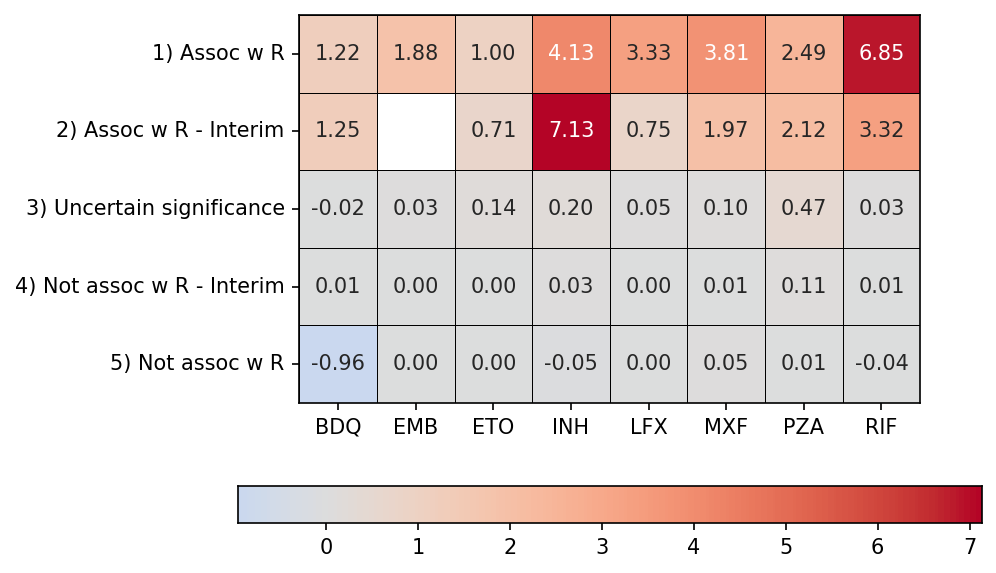

In [121]:
summary_catalog_groups_MICs = []

for drug in all_drugs_insilico_pred.drug.unique():

    df_single_drug = all_drugs_insilico_pred.query("drug==@drug & variant != 'MT_H37Rv'")
    df_summary = pd.DataFrame(df_single_drug.groupby('confidence')['log2_fold_change'].mean()).reset_index()
    df_summary['Drug'] = drug_abbr_dict[drug]
    summary_catalog_groups_MICs.append(df_summary)

summary_catalog_groups_MICs = pd.concat(summary_catalog_groups_MICs)
summary_catalog_groups_MICs = summary_catalog_groups_MICs.pivot(index='confidence', columns='Drug', values='log2_fold_change')
summary_catalog_groups_MICs.rename(columns={'ETH': 'ETO', 'LEV': 'LFX'}, inplace=True)

max_val = np.max(np.abs(summary_catalog_groups_MICs.fillna(0).values))

min_val = summary_catalog_groups_MICs.fillna(0).values.min()
max_val = summary_catalog_groups_MICs.fillna(0).values.max()

sns.heatmap(summary_catalog_groups_MICs,
            vmin=min_val,
            vmax=max_val,
            center=0,
            annot=True,
            fmt='.2f',
            linewidths=0.3,
            linecolor='black',
            cbar=True,
            cmap='coolwarm',
            square=True,
            cbar_kws={"orientation": "horizontal"}
           )

plt.xlabel('')
plt.ylabel('')
sns.despine(top=False, right=False, left=False, bottom=False)
plt.savefig("results/insilicio_mut_fold_change_summary.svg", bbox_inches='tight')

# Mutations that cause low-level resistance from the catalog. How are they predicted?

In [122]:
low_level_R_variants = who_variants.loc[(~pd.isnull(who_variants['Comment'])) & (who_variants['Comment'].str.contains('low'))][['drug', 'variant', 'Comment', 'Additional grading criteria applied']]

print(len(low_level_R_variants))

low_level_R_variants = all_drugs_insilico_pred.merge(low_level_R_variants, left_on=['drug', 'variant'], right_on=['drug', 'variant'], how='right')

print(len(low_level_R_variants))

21
21


In [123]:
who_variants.loc[(~pd.isnull(who_variants['Comment'])) & (who_variants['Comment'].str.contains('low'))][['drug', 'gene']].value_counts()

drug          gene
Isoniazid     inhA    8
Moxifloxacin  gyrB    8
              gyrA    5
Name: count, dtype: int64

In [124]:
low_level_R_variants.query("drug=='Moxifloxacin'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug,Comment,Additional grading criteria applied
8,gyrA_p.Ala90Val,-1.553507,0.340681,missense_variant,0.5,gyrBA,1) Assoc w R,0.050672,6.723247,2.749158,gyrA,Moxifloxacin,"Low-level resistance (multiple, genetically li...",NaN
9,gyrA_p.Asp89Asn,0.197340,1.146583,missense_variant,0.5,gyrBA,1) Assoc w R,0.050672,22.627513,4.500006,gyrA,Moxifloxacin,"Low-level resistance (multiple, genetically li...",NaN
10,gyrA_p.Asp94Ala,-1.279889,0.411827,missense_variant,0.5,gyrBA,1) Assoc w R,0.050672,8.127305,3.022777,gyrA,Moxifloxacin,"Low-level resistance (multiple, genetically li...",NaN
11,gyrA_p.Gly88Ala,-3.057074,0.120151,missense_variant,0.5,gyrBA,2) Assoc w R - Interim,0.050672,2.371158,1.245592,gyrA,Moxifloxacin,"Low-level resistance (multiple, genetically li...",FQ cross-resistance
12,gyrA_p.Ser91Pro,-0.997748,0.500781,missense_variant,0.5,gyrBA,1) Assoc w R,0.050672,9.882786,3.304918,gyrA,Moxifloxacin,"Low-level resistance (multiple, genetically li...",NaN
13,gyrB_p.Ala504Val,-3.352461,0.097906,missense_variant,0.5,gyrBA,2) Assoc w R - Interim,0.050672,1.932147,0.950205,gyrB,Moxifloxacin,"Low-level resistance (multiple, genetically li...",FQ cross-resistance
14,gyrB_p.Asn499Asp,-0.979168,0.507272,missense_variant,0.5,gyrBA,2) Assoc w R - Interim,0.050672,10.010886,3.323498,gyrB,Moxifloxacin,"Low-level resistance (multiple, genetically li...",Evidence from ALL dataset only
15,gyrB_p.Asn499Thr,-1.757699,0.295719,missense_variant,0.5,gyrBA,2) Assoc w R - Interim,0.050672,5.835947,2.544967,gyrB,Moxifloxacin,"Low-level resistance (multiple, genetically li...",FQ cross-resistance
16,gyrB_p.Asp461Asn,-2.905375,0.133473,missense_variant,0.5,gyrBA,2) Assoc w R - Interim,0.050672,2.634065,1.397291,gyrB,Moxifloxacin,"Low-level resistance (multiple, genetically li...",FQ cross-resistance
17,gyrB_p.Asp461His,-3.548912,0.085442,missense_variant,0.5,gyrBA,2) Assoc w R - Interim,0.050672,1.686174,0.753754,gyrB,Moxifloxacin,"Low-level resistance (multiple, genetically li...",FQ cross-resistance


In [125]:
low_level_R_variants.fold_change.min(), low_level_R_variants.fold_change.max()

(1.0321716055359822, 22.627513071305962)

# Any silent variants predicted to cause resistance?

In [126]:
silent_variants_insilico_pred.query("pred_MIC > CC").sort_values("fold_change", ascending=False)

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
475,pncA_c.309C>T,9.001747,512.6204,synonymous_variant,100.0,pncA,4) Not assoc w R - Interim,22.105331,23.189899,4.535425,pncA,Pyrazinamide
480,pncA_c.3G>A,8.938077,490.4890,initiator_codon_variant,100.0,pncA,4) Not assoc w R - Interim,22.105331,22.188720,4.471755,pncA,Pyrazinamide


In [127]:
# add any silent mutations predicted to cause resistance
silent_resistant_mutations = silent_variants_insilico_pred.query("pred_MIC > CC").sort_values("fold_change", ascending=False)

# add Group 3 mutations with very high predicted PZA MICs
PZA_Group3_high_MIC_mutations = all_drugs_insilico_pred.query("drug=='Pyrazinamide' & confidence=='3) Uncertain significance' & pred_MIC > 1000").sort_values("pred_MIC", ascending=False)

# Individual Discrepancies / Interesting points to make

# ahpC Mutations (isoniazid)

In [131]:
# will pd.concat this at the end
mutations_of_interest = []

keep_cols = ['drug', 'variant', 'confidence', 'pred_MIC', 'ref_pred', 'fold_change', 'log2_fold_change']

# xpert range is -47 to -92. End is exclusive in np.arange
xpert_lst = np.arange(-92, -47+1).astype(str)

ahpC_resistant_mutations = all_drugs_insilico_pred.query("drug=='Isoniazid' & gene == 'ahpC' & variant.str.contains('|'.join(@xpert_lst))").query("pred_MIC > 0.2").sort_values("pred_MIC", ascending=False)

ahpC_exp_evidence_R = ['-81C>T', '-39C>T', '-54C>T', '-12C>T', '-51G>A', '-9G>A', '-48G>A', '-6G>A', '-52C>T', '-10C>T', '-72C>T', '-30C>T']
ahpC_exp_evidence_R = [f"ahpC_c.{var}" for var in ahpC_exp_evidence_R]

ahpC_resistant_mutations = pd.concat([ahpC_resistant_mutations, all_drugs_insilico_pred.query("drug=='Isoniazid' & gene == 'ahpC' & variant in @ahpC_exp_evidence_R").query("pred_MIC > 0.2").sort_values("pred_MIC", ascending=False)]).drop_duplicates()

ahpC_exp_evidence_notR = ['-84T>C', '-42T>C', '-88G>A', '-46G>A', '-10G>A', '33G>A']
ahpC_exp_evidence_notR = [f"ahpC_c.{var}" for var in ahpC_exp_evidence_notR]

# don't add these to mutations of interest dataframe. Add them to the not assoc w R dataframe below
ahpC_not_resistant_mutations = all_drugs_insilico_pred.query("drug=='Isoniazid' & gene == 'ahpC' & variant in @ahpC_exp_evidence_notR").sort_values("pred_MIC", ascending=False)

mutations_of_interest.append(ahpC_resistant_mutations[keep_cols])

In [132]:
ahpC_resistant_mutations

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
16,ahpC_c.-51G>A,1.698340,3.245273,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.049634,65.384295,6.030872,ahpC,Isoniazid
22,ahpC_c.-54C>T,0.009988,1.006947,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.049634,20.287522,4.342521,ahpC,Isoniazid
17,ahpC_c.-52C>A,-0.518871,0.697918,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.049634,14.061338,3.813662,ahpC,Isoniazid
24,ahpC_c.-57C>T,-0.617489,0.651805,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.049634,13.132264,3.715044,ahpC,Isoniazid
19,ahpC_c.-52C>T,-1.047808,0.483703,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.049634,9.745421,3.284725,ahpC,Isoniazid
21,ahpC_c.-54C>A,-1.806317,0.285920,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.049634,5.760585,2.526215,ahpC,Isoniazid


In [133]:
# whoo, all predicted close to fold change of 1
ahpC_not_resistant_mutations

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
49,ahpC_c.-84T>C,-4.315813,0.050212,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.049634,1.011656,0.016719,ahpC,Isoniazid
1,ahpC_c.-10G>A,-4.330305,0.049711,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.049634,1.001545,0.002227,ahpC,Isoniazid
52,ahpC_c.-88G>A,-4.333204,0.049611,upstream_gene_variant,0.2,ahpC,5) Not assoc w R,0.049634,0.999534,-0.000672,ahpC,Isoniazid


# mshA LoF Mutations (ethionamide)

In [135]:
df_ETO_phenos = pd.read_csv(os.path.join(data_dir, "ETH", "data_for_model.csv"))

mshA_mutations = all_drugs_insilico_pred.query("drug=='Ethionamide' & gene=='mshA'")
mshA_resistant_mutations = mshA_mutations.query("fold_change >= 1.5").sort_values("pred_MIC", ascending=False)

# mutations_of_interest.append(mshA_resistant_mutations[keep_cols])

In [136]:
for search_variant in mshA_resistant_mutations.merge(who_variants.query("drug=='Ethionamide'")[['variant', 'Present_S', 'Present_R']], on='variant').variant.unique():

    search_variant = search_variant.replace('_p_', '_p.').replace('_c_', '_c.').replace('+', '*')

    num_isolates_with_variant = len(isolate_variants.query("GENE=='mshA' & variant not in ['mshA_p.Ala187Val', 'mshA_p.Asn111Ser'] & variant==@search_variant").merge(df_ETO_phenos[['ROLLINGDB_ID', 'ETH_lower_bound', 'ETH_upper_bound', 'category', 'Coll2014']]).drop_duplicates(['ROLLINGDB_ID', 'variant']))

    if num_isolates_with_variant > 0:
        print(search_variant, num_isolates_with_variant)

mshA_p.Val224_Ser226del 1
mshA_p.Gly311* 1
mshA_p.Gly67Ala 1
mshA_p.Leu284Pro 1


In [137]:
search_variant = 'mshA_p.Tyr123*'

isolate_variants.query("GENE=='mshA' & variant not in ['mshA_p.Ala187Val', 'mshA_p.Asn111Ser'] & variant==@search_variant").merge(df_ETO_phenos[['ROLLINGDB_ID', 'ETH_lower_bound', 'ETH_upper_bound', 'category', 'Coll2014']]).drop_duplicates(['ROLLINGDB_ID', 'variant'])

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,ETH_lower_bound,ETH_upper_bound,category,Coll2014


In [138]:
search_variant = 'mshA_p.Leu284Pro'

isolate_variants.query("GENE=='mshA' & EFFECT=='missense_variant' & variant not in ['mshA_p.Ala187Val', 'mshA_p.Asn111Ser'] & variant==@search_variant").merge(df_ETO_phenos[['ROLLINGDB_ID', 'ETH_lower_bound', 'ETH_upper_bound', 'category', 'Coll2014']]).drop_duplicates(['ROLLINGDB_ID', 'variant'])

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,ETH_lower_bound,ETH_upper_bound,category,Coll2014
0,576198,T,C,PASS,7825.0,False,1.0,225.0,35.0,60.0,...,c.851T>C,p.Leu284Pro,mshA_p.Leu284Pro,Ethionamide,3) Uncertain significance,SAMEA7555751,10.0,inf,train_set,4.2


In [24]:
ETH_genos = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/Ethionamide/genos_1.csv.gz", compression='gzip', usecols=['sample_id', 'resolved_symbol', 'variant_category', 'variant_allele_frequency']).drop_duplicates()

ETH_genos.shape

(60902824, 4)

In [25]:
ETH_genos.query("resolved_symbol=='mshA' & variant_category=='p.Gln205*' & variant_allele_frequency > 0.75")

,sample_id,resolved_symbol,variant_category,variant_allele_frequency
31347966,178987,mshA,p.Gln205*,0.97


In [40]:
ETH_genos.query("sample_id==178987 & variant_allele_frequency > 0.75")

,sample_id,resolved_symbol,variant_category,variant_allele_frequency
31347966,178987,mshA,p.Gln205*,0.97


In [51]:
ETH_genos.query("resolved_symbol=='mshA' & variant_category.str.endswith('*') & variant_allele_frequency > 0.75")

,sample_id,resolved_symbol,variant_category,variant_allele_frequency
30915989,27117,mshA,p.Gln128*,0.76
31347966,178987,mshA,p.Gln205*,0.97
33889595,24069,mshA,p.Ser461*,0.99
34192252,178435,mshA,p.Tyr123*,0.99
34685719,169349,mshA,p.Gln363*,0.99
40752488,47911,mshA,p.Ser429*,0.99
41967702,177555,mshA,p.Glu353*,1.00
43630387,705543,mshA,p.Glu220*,1.00
47183083,27087,mshA,p.Gly311*,1.00


In [56]:
ETH_genos.query("sample_id==53546")# & variant_allele_frequency > 0.75")

,sample_id,resolved_symbol,variant_category,variant_allele_frequency


In [54]:
sample_ids_mapping.loc[sample_ids_mapping['Sample Name']=='SAMEA3392629']

,Sample ID,Sample Name
174279,53546,SAMEA3392629


In [34]:
sample_ids_mapping = pd.read_csv("../who-analysis/data/sample_ids_mapping_20220922.csv")
lineages = pd.read_csv("../who-analysis/lineages/combined_lineages_samples.csv")

In [38]:
lineages.loc[lineages['Sample_ID']==178987].VCF_Dir.values

array(['/n/scratch/users/s/sak0914/WHO_catalogue_data/VCF/6d441179-9b21-1f42-aa56-611440b8e6d6-03_67-99_LIB10828_67-99_LIB10828_1'],
      dtype=object)

In [32]:
sample_ids_mapping.loc[sample_ids_mapping['Sample ID']==178987]

,Sample ID,Sample Name
169227,178987,03_67-99_LIB10828_67-99_LIB10828_1


In [13]:
isolate_variants.query("variant=='mshA_p.Gln205*'")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID


In [46]:
isolate_variants.query("GENE=='mshA' & EFFECT=='stop_gained' & variant != 'stop_gained'").drop_duplicates(['ROLLINGDB_ID', 'variant']).merge(df_ETO_phenos[['ROLLINGDB_ID', 'ETH_lower_bound', 'ETH_upper_bound', 'Coll2014', 'category']])

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,ETH_lower_bound,ETH_upper_bound,Coll2014,category
0,575511,C,A,PASS,2152.0,False,1.0,61.0,35.0,60.0,...,c.164C>A,p.Ser55*,mshA_p.Ser55*,Isoniazid,3) Uncertain significance,SAMEA3392629,0.0000,10.000,4,test_set
1,576633,C,A,PASS,4630.0,False,1.0,132.0,35.0,60.0,...,c.1286C>A,p.Ser429*,mshA_p.Ser429*,Ethionamide,3) Uncertain significance,SAMEA5282343,0.0000,1.250,4,train_set
2,576278,G,T,PASS,2491.0,False,1.0,71.0,35.0,60.0,...,c.931G>T,p.Gly311*,mshA_p.Gly311*,Ethionamide,3) Uncertain significance,SAMEA7526397,10.0000,inf,3.1.2,test_set
3,576729,C,A,PASS,3051.0,False,1.0,82.0,38.0,60.0,...,c.1382C>A,p.Ser461*,mshA_p.Ser461*,Ethionamide,3) Uncertain significance,SAMEA7541537,0.3125,0.625,2.2.1.1,test_set


In [139]:
mshA_mutations.query("effect != 'synonymous_variant' & confidence != '3) Uncertain significance'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
1195,mshA_p.Ala187Val,0.257152,1.195117,missense_variant,5.0,mshA,5) Not assoc w R,1.196586,0.998773,-0.001772,mshA,Ethionamide
1228,mshA_p.Asn111Ser,0.260938,1.198257,missense_variant,5.0,mshA,5) Not assoc w R,1.196586,1.001397,0.002014,mshA,Ethionamide


# rpoC mutations (rifampicin)

In [140]:
rpoC_mutations = all_drugs_insilico_pred.query("drug=='Rifampicin' & gene=='rpoC'")

print(f"Largest predicted MIC among the {len(rpoC_mutations)} rpoC mutations: {rpoC_mutations.pred_MIC.max()}")

Largest predicted MIC among the 1384 rpoC mutations: 0.15205914


# mmpL5 and mmpS5 LoF Mutations (bedaquiline)

In [141]:
mmp_variants_low_MIC = all_drugs_insilico_pred.query("drug=='Bedaquiline' & fold_change <= 0.8 & variant.str.contains('mmp')").sort_values("pred_MIC", ascending=True)

# mutations_of_interest.append(mmp_variants_low_MIC[keep_cols])

In [142]:
all_drugs_insilico_pred.query("drug=='Bedaquiline' & confidence=='1) Assoc w R'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
103,Rv0678_p.Gly121Arg,-4.500864,0.044168,missense_variant,0.25,Rv0678,1) Assoc w R,0.030083,1.468200,0.554048,Rv0678,Bedaquiline
124,Rv0678_p.Leu117Arg,-3.170710,0.111051,missense_variant,0.25,Rv0678,1) Assoc w R,0.030083,3.691488,1.884202,Rv0678,Bedaquiline


In [143]:
all_drugs_insilico_pred.query("drug=='Bedaquiline' & confidence=='5) Not assoc w R'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
373,mmpL5_p.Asp767Asn,-6.015654,0.015456,missense_variant,0.25,mmpLS5,5) Not assoc w R,0.030083,0.513793,-0.960742,mmpL5,Bedaquiline


In [53]:
df_BDQ_phenos = pd.read_csv(os.path.join(data_dir, "BDQ", "data_for_model.csv"))
print(len(df_BDQ_phenos))

df_BDQ_annot = isolate_variants.query("drug=='Bedaquiline'").merge(df_BDQ_phenos[['ROLLINGDB_ID', 'BDQ_lower_bound', 'BDQ_midpoint', 'BDQ_upper_bound', 'Coll2014', 'Binary', 'category']], how='right').drop_duplicates(['variant', 'ROLLINGDB_ID'])

df_BDQ_annot.loc[df_BDQ_annot["variant"] == 'mmpL5_p.Asp767Asn', 'mmpL5_p.Asp767Asn'] = 1
df_BDQ_annot['mmpL5_p.Asp767Asn'] = df_BDQ_annot['mmpL5_p.Asp767Asn'].fillna(0).astype(int)

9091


In [71]:
# L2.2.1 isolates only
isolates_with_variant = df_BDQ_annot.loc[df_BDQ_annot['mmpL5_p.Asp767Asn']==1].ROLLINGDB_ID.unique()
isolates_with_R_variants = df_BDQ_annot.query("confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").ROLLINGDB_ID.unique()

df_BDQ_annot_summary = df_BDQ_phenos.copy()
df_BDQ_annot_summary.loc[df_BDQ_annot_summary['ROLLINGDB_ID'].isin(isolates_with_variant), 'mmpL5_p.Asp767Asn'] = 1
df_BDQ_annot_summary.loc[df_BDQ_annot_summary['ROLLINGDB_ID'].isin(isolates_with_R_variants), 'R_assoc'] = 1

df_BDQ_annot_summary[['mmpL5_p.Asp767Asn', 'R_assoc']] = df_BDQ_annot_summary[['mmpL5_p.Asp767Asn', 'R_assoc']].fillna(0).astype(int)

df_BDQ_L221 = df_BDQ_annot_summary.query("Coll2014.str.startswith('2.2.1')")
print(f"{len(df_BDQ_L221)}/{len(df_BDQ_annot_summary)} L2.2.1 isolates")

3138/9091 L2.2.1 isolates


In [72]:
df_BDQ_annot_summary.groupby("mmpL5_p.Asp767Asn")['BDQ_midpoint'].mean()

mmpL5_p.Asp767Asn
0    0.045717
1    0.029719
Name: BDQ_midpoint, dtype: float64

In [73]:
# even among L2.2.1 isolates, mmpL5_p.Asp767Asn-containing isolates have lower measured MICs. Difference is actually greater
df_BDQ_L221.groupby("mmpL5_p.Asp767Asn")['BDQ_midpoint'].mean()

mmpL5_p.Asp767Asn
0    0.060880
1    0.029719
Name: BDQ_midpoint, dtype: float64

In [83]:
# same among L2.2.1 isolates without resistance mutations
df_BDQ_L221.query("R_assoc==0").groupby("mmpL5_p.Asp767Asn")['BDQ_midpoint'].mean()

mmpL5_p.Asp767Asn
0    0.058541
1    0.027692
Name: BDQ_midpoint, dtype: float64

In [92]:
st.mannwhitneyu(df_BDQ_L221.query('R_assoc==0').loc[df_BDQ_L221['mmpL5_p.Asp767Asn']==1]['BDQ_midpoint'],
                df_BDQ_L221.query('R_assoc==0').loc[df_BDQ_L221['mmpL5_p.Asp767Asn']==0]['BDQ_midpoint'],
                alternative='less'
                )

MannwhitneyuResult(statistic=327855.0, pvalue=1.0806818222415474e-43)

In [91]:
st.ttest_ind(df_BDQ_L221.query('R_assoc==0').loc[df_BDQ_L221['mmpL5_p.Asp767Asn']==1]['BDQ_midpoint'],
             df_BDQ_L221.query('R_assoc==0').loc[df_BDQ_L221['mmpL5_p.Asp767Asn']==0]['BDQ_midpoint'],
             equal_var=False,
             alternative='less'
            )

TtestResult(statistic=-4.16173277525085, pvalue=1.9086033792435867e-05, df=429.45297659459527)

In [75]:
df_BDQ_L221[['mmpL5_p.Asp767Asn', 'R_assoc']].value_counts()

mmpL5_p.Asp767Asn  R_assoc
1                  0          2688
0                  0           411
1                  1            32
0                  1             7
Name: count, dtype: int64

In [77]:
32/(2688+31), 7/(411+7)

(0.011769032732622288, 0.01674641148325359)

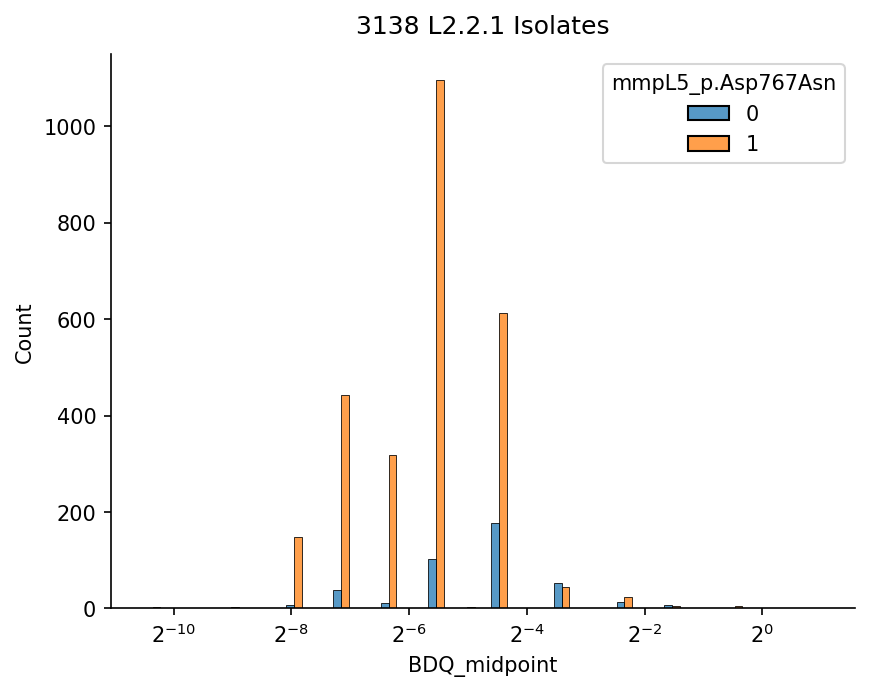

In [78]:
sns.histplot(data=df_BDQ_L221,
             x='BDQ_midpoint',
             hue='mmpL5_p.Asp767Asn',
             log_scale=2,
             stat='count',
             # common_norm=False,
             multiple='dodge'
            )

plt.title(f"{len(df_BDQ_L221)} L2.2.1 Isolates")
sns.despine()
plt.show()

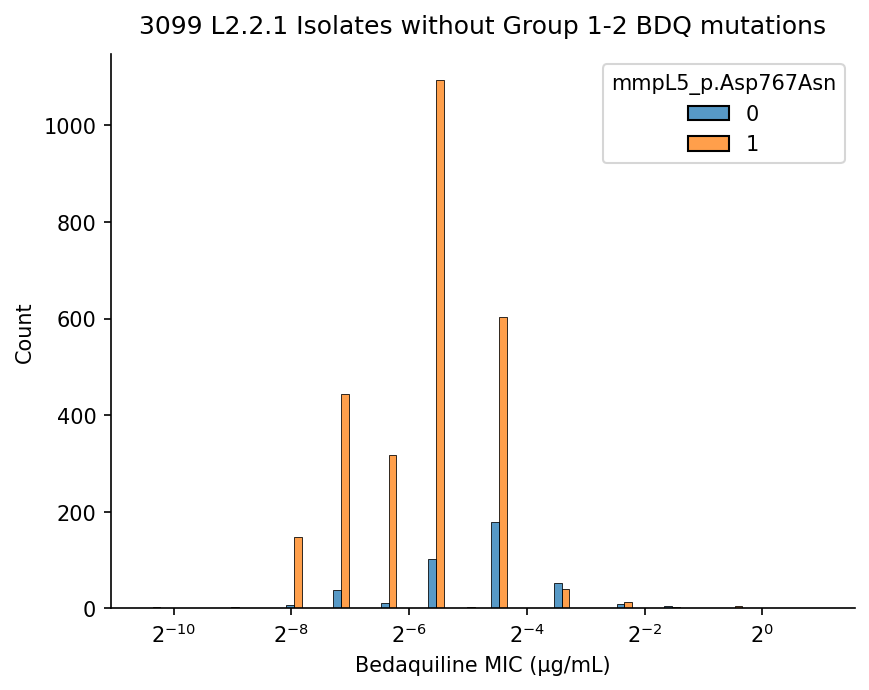

In [84]:
sns.histplot(data=df_BDQ_L221.query("R_assoc==0"),
             x='BDQ_midpoint',
             hue='mmpL5_p.Asp767Asn',
             log_scale=2,
             stat='count',
             # common_norm=False,
             multiple='dodge'
            )

plt.xlabel("Bedaquiline MIC (µg/mL)")
plt.title(f"{len(df_BDQ_L221.query('R_assoc==0'))} L2.2.1 Isolates without Group 1-2 BDQ mutations")
sns.despine()
plt.show()

In [273]:
df_BDQ_phenos = pd.read_csv(os.path.join(data_dir, "BDQ", "data_for_model.csv"))

isolate_variants.query("variant in ['Rv0678_p.Gly121Arg', 'Rv0678_p.Leu117Arg']").merge(df_BDQ_phenos[['ROLLINGDB_ID', 'BDQ_lower_bound', 'BDQ_upper_bound', 'Coll2014', 'category']]).drop_duplicates(['variant', 'ROLLINGDB_ID'])

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,BDQ_lower_bound,BDQ_upper_bound,Coll2014,category
0,779350,G,A,PASS,2011.0,False,1.00,62.0,32.0,60.0,...,c.361G>A,p.Gly121Arg,Rv0678_p.Gly121Arg,Bedaquiline,1) Assoc w R,SAMEA1102223,0.25,0.50,3,train_set
2,779339,T,G,PASS,1845.0,False,1.00,53.0,35.0,60.0,...,c.350T>G,p.Leu117Arg,Rv0678_p.Leu117Arg,Bedaquiline,1) Assoc w R,SAMEA7526308,0.12,0.25,3,train_set
4,779339,T,G,PASS,2558.0,False,0.93,106.0,34.0,60.0,...,c.350T>G,p.Leu117Arg,Rv0678_p.Leu117Arg,Bedaquiline,1) Assoc w R,SAMEA7562380,0.12,0.25,3,train_set
6,779350,G,A,Amb,355.0,False,0.73,117.0,36.0,60.0,...,c.361G>A,p.Gly121Arg,Rv0678_p.Gly121Arg,Bedaquiline,1) Assoc w R,SAMEA8718809,0.12,0.25,4.4.1.1,train_set


In [277]:
isolate_variants.query("GENE=='Rv0678' & EFFECT in ['stop_gained', 'frameshift_variant', 'start_lost']").merge(df_BDQ_phenos[['ROLLINGDB_ID', 'BDQ_lower_bound', 'BDQ_upper_bound', 'Coll2014', 'category']]).drop_duplicates(['variant', 'ROLLINGDB_ID']).query("category=='train_set'").ROLLINGDB_ID.nunique()

92

In [279]:
all_drugs_insilico_pred.query("variant=='ethA_p_Arg207Gly'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
178,ethA_p_Arg207Gly,0.35467,1.278693,missense_variant,5.0,ethA,1) Assoc w R,1.196586,1.068618,0.095747,ethA,Ethionamide


In [281]:
df_ETH_phenos = pd.read_csv(os.path.join(data_dir, "ETH", "data_for_model.csv"))

isolate_variants.query("variant in ['ethA_p.Arg207Gly']").merge(df_BDQ_phenos[['ROLLINGDB_ID', 'BDQ_lower_bound', 'BDQ_upper_bound', 'Coll2014', 'category']]).drop_duplicates(['variant', 'ROLLINGDB_ID'])

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,BDQ_lower_bound,BDQ_upper_bound,Coll2014,category
0,4326855,G,C,PASS,3652.0,False,1.0,110.0,34.0,60.0,...,c.619C>G,p.Arg207Gly,ethA_p.Arg207Gly,Ethionamide,1) Assoc w R,SAMEA7561829,0.0,0.008,2.2.1,test_set


# Not Assoc w R Mutations from the Literature Compiled for the 2023 Catalog

In [144]:
# 47 total, 41 for the drugs here
not_assoc_w_R_literature = pd.read_excel("~/who-analysis/data/NotAwR by literature.xlsx", sheet_name=None)['Sheet1'].query("drug in @all_drugs_insilico_pred.drug")
print(len(not_assoc_w_R_literature))

41


In [145]:
not_assoc_w_R_pred = all_drugs_insilico_pred.copy()
not_assoc_w_R_pred['variant'] = not_assoc_w_R_pred.variant.str.replace('_p_', '_p.').str.replace('_c_', '_c.').str.replace('+', '*')

not_assoc_w_R_pred = not_assoc_w_R_pred.merge(not_assoc_w_R_literature, on=['drug', 'variant'])
print(len(not_assoc_w_R_pred))

25


In [146]:
# add the ahpC not assoc w R mutations here
not_assoc_w_R_pred = pd.concat([not_assoc_w_R_pred, ahpC_not_resistant_mutations])
print(len(not_assoc_w_R_pred))
print(f"Largest fold change for Not assoc w R by literature mutations: {not_assoc_w_R_pred.fold_change.max()}")

28
Largest fold change for Not assoc w R by literature mutations: 1.1259358904727585


In [147]:
not_assoc_w_R_pred.fold_change.mean(), not_assoc_w_R_pred.fold_change.max()

(0.9861156178203438, 1.1259358904727585)

In [148]:
ahpC_not_resistant_mutations

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
49,ahpC_c.-84T>C,-4.315813,0.050212,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.049634,1.011656,0.016719,ahpC,Isoniazid
1,ahpC_c.-10G>A,-4.330305,0.049711,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.049634,1.001545,0.002227,ahpC,Isoniazid
52,ahpC_c.-88G>A,-4.333204,0.049611,upstream_gene_variant,0.2,ahpC,5) Not assoc w R,0.049634,0.999534,-0.000672,ahpC,Isoniazid


# Ethambutol: Many low-level resistance mutations

In [150]:
EMB_promoter_variants = all_drugs_insilico_pred.query("drug=='Ethambutol' & effect=='upstream_gene_variant'").sort_values("pred_MIC", ascending=False)

# no R-associated variants in the catalog
EMB_promoter_variants.confidence.unique()

array(['3) Uncertain significance', '5) Not assoc w R',
       '4) Not assoc w R - Interim'], dtype=object)

In [151]:
who_variants.query("drug=='Ethambutol'").loc[who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].effect.unique()

array(['missense_variant'], dtype=object)

In [152]:
who_variants.query("drug=='Ethambutol' & effect=='upstream_gene_variant'")['FINAL CONFIDENCE GRADING'].unique()

array(['3) Uncertain significance', '5) Not assoc w R',
       '4) Not assoc w R - Interim'], dtype=object)

In [153]:
who_variants.query("drug=='Ethambutol'").loc[who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].gene.unique()

array(['embB'], dtype=object)

In [155]:
mutations_of_interest.append(EMB_promoter_variants.query("fold_change > 2")[keep_cols])
print(EMB_promoter_variants.query("fold_change > 2").gene.value_counts())

gene
embA    15
Name: count, dtype: int64


In [156]:
EMB_promoter_variants.query("gene=='embC'").fold_change.max()

1.8079556028420094

In [157]:
mutations_of_interest.append(EMB_promoter_variants.query("fold_change < 0.9")[keep_cols])

EMB_promoter_variants.query("fold_change < 0.9")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
3367,embC_c.-564C>A,0.010373,1.007216,upstream_gene_variant,5.0,aftA-embCAB,3) Uncertain significance,1.246963,0.807735,-0.308046,embC,Ethambutol
2922,embC_c.-100C>T,-0.309789,0.806760,upstream_gene_variant,5.0,aftA-embCAB,5) Not assoc w R,1.246963,0.646980,-0.628207,embC,Ethambutol
2954,embC_c.-110C>T,-0.430095,0.742213,upstream_gene_variant,5.0,aftA-embCAB,3) Uncertain significance,1.246963,0.595217,-0.748513,embC,Ethambutol
2975,embC_c.-1188C>T,-0.601867,0.658901,upstream_gene_variant,5.0,aftA-embCAB,4) Not assoc w R - Interim,1.246963,0.528405,-0.920285,embC,Ethambutol


In [159]:
EMB_susceptible_mutations = all_drugs_insilico_pred.query("drug=='Ethambutol' & fold_change < 0.8 & effect not in @silent_lst").sort_values("fold_change")

EMB_susceptible_mutations = EMB_susceptible_mutations.merge(who_variants, on=['drug', 'variant'])[keep_cols + ['Present_S', 'Present_R', 'Present_SOLO_S', 'Present_SOLO_R']]

In [160]:
all_drugs_insilico_pred.query("confidence=='1) Assoc w R' & pred_MIC < CC").drug.value_counts()

drug
Pyrazinamide    56
Ethambutol       8
Bedaquiline      2
Ethionamide      2
Moxifloxacin     2
Rifampicin       2
Isoniazid        1
Levofloxacin     1
Name: count, dtype: int64

In [161]:
len(all_drugs_insilico_pred.query("confidence=='1) Assoc w R' & pred_MIC < CC"))

74

# Group 1 Mutations that the Models Predicted Low MIC

In [9]:
def plot_predicted_MICs_strip(drug, save=False):

    missed_group1_variants = all_drugs_insilico_pred.query("confidence=='1) Assoc w R' & pred_MIC < CC & drug==@drug")

    if len(missed_group1_variants) == 0:
        return None
    
    ref_pred = missed_group1_variants.query("drug==@drug")['ref_pred'].values[0]
    drug_abbr = drug_abbr_dict[drug]
    cc = cc_dict[drug_abbr]

    if drug == 'Pyrazinamide':
        log_base = 10
        sig_fig = 1
    else:
        log_base = 2
        sig_fig = 2

    log_base = 2
    
    fig, ax = plt.subplots(figsize=(2, 3))
    
    sns.stripplot(data=missed_group1_variants.query("drug==@drug"),
                  x='drug',
                  y='pred_MIC',
                  log_scale=log_base,
                  jitter=True,
                  alpha=0.75,
                  linewidth=0.75,
                  edgecolor='black',
                  ax=ax
                 )

    plt.axhline(cc, label=f'CC = {cc}', color='tomato', linestyle='--', linewidth=1, zorder=0)
    plt.axhline(ref_pred, label=f'H37Rv = {np.round(ref_pred, sig_fig)}', color='black', linestyle='--', linewidth=1, zorder=0)
    plt.legend(fontsize=6)
    
    plt.xticks([])
    plt.yticks(fontsize=8)

    # Set the y-tick labels' font size
    # ax.tick_params(axis='y', labelsize=8)

    # Get the current y-tick labels
    y_ticks = plt.gca().get_yticklabels()
    
    # Set the font size for y-tick labels
    plt.setp(y_ticks, fontsize=8)

    plt.xlabel('')
    plt.title(drug, fontsize=8)
    plt.ylabel('Predicted MIC (µg/mL)', fontsize=8)
    
    sns.despine()
    plt.tight_layout()

    if save:
        plt.savefig(f"results/{drug}/Group1_missed.svg")
    else:
        plt.close()

    search_variants = missed_group1_variants['variant'].values

    df_phenos = pd.read_csv(os.path.join(data_dir, drug_abbr, "data_for_model.csv"))

    df_phenos_with_variants = isolate_variants.query("variant in @search_variants").drop_duplicates(['ROLLINGDB_ID', 'variant']).merge(df_phenos.query("category=='train_set'")[['ROLLINGDB_ID', f'{drug_abbr}_lower_bound', f'{drug_abbr}_upper_bound']])

    return pd.DataFrame(df_phenos_with_variants.groupby(['variant'])[['ROLLINGDB_ID']].nunique()).reset_index().merge(missed_group1_variants, on='variant', how='right')

In [10]:
missing_group1_annotated = []

for drug in all_drugs_insilico_pred.drug.unique():
    missing_group1_annotated.append(plot_predicted_MICs_strip(drug, save=False))

missing_group1_annotated = pd.concat(missing_group1_annotated)
print(f"{len(missing_group1_annotated)} missed Group 1 variants")
print(f"{len(missing_group1_annotated.dropna(subset='ROLLINGDB_ID'))} variants are present in the training dataset")
missing_group1_annotated.dropna(subset='ROLLINGDB_ID')['drug'].value_counts()

74 missed Group 1 variants
27 variants are present in the training dataset


drug
Pyrazinamide    11
Ethambutol       8
Bedaquiline      2
Moxifloxacin     2
Rifampicin       2
Ethionamide      1
Levofloxacin     1
Name: count, dtype: int64

In [183]:
missing_group1_annotated.drug.value_counts()

drug
Pyrazinamide    56
Ethambutol       8
Bedaquiline      2
Ethionamide      2
Moxifloxacin     2
Rifampicin       2
Isoniazid        1
Levofloxacin     1
Name: count, dtype: int64

In [184]:
56/74

0.7567567567567568

In [180]:
47/74

0.6351351351351351

In [19]:
missing_group1_annotated.query("drug=='Ethambutol'").sort_values("pred_MIC", ascending=False)

,variant,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
5,embB_p.Gly406Cys,13.0,2.291717,4.896384,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.246963,3.926648,1.973298,embB,Ethambutol
3,embB_p.Gly406Ala,137.0,2.284705,4.872646,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.246963,3.907612,1.966287,embB,Ethambutol
4,embB_p.Gly406Asp,88.0,2.229994,4.691319,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.246963,3.762197,1.911575,embB,Ethambutol
1,embB_p.Gln497Arg,325.0,2.217781,4.651775,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.246963,3.730484,1.899363,embB,Ethambutol
6,embB_p.Met306Ile,904.0,2.030367,4.085088,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.246963,3.276031,1.711949,embB,Ethambutol
7,embB_p.Tyr319Ser,100.0,1.900630,3.733763,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.246963,2.994286,1.582212,embB,Ethambutol
0,embB_p.Asp354Ala,74.0,1.862680,3.636827,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.246963,2.916549,1.544262,embB,Ethambutol
2,embB_p.Gln497Lys,46.0,1.706080,3.262731,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.246963,2.616543,1.387662,embB,Ethambutol


In [176]:
missing_group1_annotated_save = missing_group1_annotated[['drug', 'ref_pred', 'CC', 'variant', 'ROLLINGDB_ID', 'pred_MIC']].rename(columns={'ROLLINGDB_ID': 'Train_count'})

missing_group1_annotated_save['Train_count'] = missing_group1_annotated_save['Train_count'].fillna(0).astype(int)

# exclude PZA mutations that aren't found in the training set so that the table is more tractable to read
missing_group1_annotated_save = missing_group1_annotated_save.query("~(drug=='Pyrazinamide' & Train_count==0)")

missing_group1_annotated_save.sort_values(["drug", "pred_MIC"], ascending=[True, False]).to_csv("results/tables/Group1_missed_variants.csv", index=False)

In [173]:
missing_group1_annotated_save.query("~(drug=='Pyrazinamide' & Train_count==0)").shape

(29, 6)

In [169]:
search_variants = all_drugs_insilico_pred.query("confidence=='1) Assoc w R' & fold_change < 1.5 & drug=='Pyrazinamide'")['variant'].values
print(len(search_variants))

36


In [170]:
df_PZA_phenos = pd.read_csv(os.path.join(data_dir, "PZA", "data_for_model.csv"))

isolate_variants.query("variant in @search_variants").merge(df_PZA_phenos[['ROLLINGDB_ID', 'PZA_lower_bound', 'PZA_upper_bound', 'category']])

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,PZA_lower_bound,PZA_upper_bound,category
0,2288713,T,G,PASS,2058.0,False,1.00,64.0,32.0,60.0,...,pncA,c.529A>C,p.Thr177Pro,pncA_p.Thr177Pro,Pyrazinamide,1) Assoc w R,SAMEA3392667,20.0,50.0,test_set
1,2288962,A,G,PASS,4036.0,False,1.00,111.0,36.0,60.0,...,pncA,c.280T>C,p.Phe94Leu,pncA_p.Phe94Leu,Pyrazinamide,1) Assoc w R,SAMN05915287,150.0,175.0,train_set
2,2288938,C,G,PASS,6753.0,False,1.00,187.0,36.0,60.0,...,pncA,c.304G>C,p.Ala102Pro,pncA_p.Ala102Pro,Pyrazinamide,1) Assoc w R,SAMN05916315,100.0,120.0,test_set
3,2288697,A,C,Amb,935.0,False,0.72,177.0,39.0,60.0,...,pncA,c.545T>G,p.Leu182Trp,pncA_p.Leu182Trp,Pyrazinamide,1) Assoc w R,SAMN05916454,500.0,inf,train_set
4,2288962,A,G,Amb,4298.0,False,0.35,309.0,37.0,60.0,...,pncA,c.280T>C,p.Phe94Leu,pncA_p.Phe94Leu,Pyrazinamide,1) Assoc w R,SAMN05918695,500.0,inf,train_set
5,2288956,T,G,Del,0.0,False,1.00,1.0,19.0,60.0,...,pncA,c.286A>C,p.Lys96Gln,pncA_p.Lys96Gln,Pyrazinamide,1) Assoc w R,SAMN06010224,500.0,inf,train_set


In [100]:
all_drugs_insilico_pred.query("confidence=='1) Assoc w R' & pred_MIC < CC & drug=='Ethambutol'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
2359,embB_p_Asp354Ala,1.862680,3.636827,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.246963,2.916549,1.544262,embB,Ethambutol
2394,embB_p_Gln497Arg,2.217781,4.651775,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.246963,3.730484,1.899363,embB,Ethambutol
2398,embB_p_Gln497Lys,1.706080,3.262731,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.246963,2.616543,1.387662,embB,Ethambutol
2464,embB_p_Gly406Ala,2.284705,4.872646,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.246963,3.907612,1.966287,embB,Ethambutol
2465,embB_p_Gly406Asp,2.229994,4.691319,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.246963,3.762197,1.911575,embB,Ethambutol
2466,embB_p_Gly406Cys,2.291717,4.896384,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.246963,3.926648,1.973298,embB,Ethambutol
2593,embB_p_Met306Ile,2.030367,4.085088,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.246963,3.276031,1.711949,embB,Ethambutol
2832,embB_p_Tyr319Ser,1.900630,3.733763,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.246963,2.994286,1.582212,embB,Ethambutol


In [102]:
who_variants.query("variant=='embB_p.Asp354Ala'")[['Present_SOLO_S', 'Present_SOLO_R', 'Comment', 'Additional grading criteria applied']]

,Present_SOLO_S,Present_SOLO_R,Comment,Additional grading criteria applied
11527,96.0,172.0,NaN,NaN


# Save Mutations of Interest with Catalog SOLO Counts to a Table

In [261]:
df_PZA_phenos = pd.read_csv(os.path.join(data_dir, "PZA", "data_for_model.csv"))

In [262]:
isolate_variants.query("variant in ['pncA_c.309C>T', 'pncA_c.3G>A']").merge(df_PZA_phenos[['ROLLINGDB_ID', 'PZA_lower_bound', 'PZA_upper_bound', 'Coll2014', 'category']])

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,PZA_lower_bound,PZA_upper_bound,Coll2014,category
0,2289239,C,T,PASS,3040.0,False,0.97,93.0,38.0,60.0,...,c.3G>A,p.Met1?,pncA_c.3G>A,Pyrazinamide,4) Not assoc w R - Interim,SAMN05916261,500.0,inf,2.2.1,train_set


In [263]:
who_variants.query("variant.str.contains('103') & effect=='missense_variant' & gene=='pncA'")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,compatible_variant
36199,Pyrazinamide,pncA,p.Tyr103Asp,pncA_p.Tyr103Asp,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,3.0,2.0,...,2) Assoc w R - Interim,NaN,No change,NaN,NaN,yes,NaN,NaN,1,pncA_p_Tyr103Asp
36200,Pyrazinamide,pncA,p.Tyr103Cys,pncA_p.Tyr103Cys,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,13.0,9.0,...,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1,pncA_p_Tyr103Cys
36202,Pyrazinamide,pncA,p.Tyr103His,pncA_p.Tyr103His,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,7.0,7.0,...,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1,pncA_p_Tyr103His
36203,Pyrazinamide,pncA,p.Tyr103Ser,pncA_p.Tyr103Ser,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,1.0,1.0,...,3) Uncertain significance,NaN,DOWN from AwRI to Uncertain,NaN,NaN,yes,NaN,NaN,2,pncA_p_Tyr103Ser


In [267]:
df_mutations_of_interest = pd.concat(mutations_of_interest)
df_mutations_of_interest['variant'] = df_mutations_of_interest.variant.str.replace('_p_', '_p.').str.replace('_c_', '_c.').str.replace('+', '*')

df_mutations_of_interest = df_mutations_of_interest.merge(who_variants, on=['drug', 'variant'])[keep_cols] # + ['Present_S', 'Present_R', 'Present_SOLO_S', 'Present_SOLO_R']]#.sort_values(['drug', "fold_change"], ascending=[True, False])

In [270]:
df_mutations_of_interest.to_csv("results/tables/insilico_muts_of_interest.csv", index=False)

# Counts of Group 3 Mutations with Fold Changes > 2 or < 0.8

Don't interpret them too much. Just give counts.

In [179]:
Group_3_interesting_variants = all_drugs_insilico_pred.query("confidence=='3) Uncertain significance' & (fold_change > 2 | fold_change < 0.8)")

print(len(Group_3_interesting_variants))

336


In [183]:
Group_3_interesting_variants[['drug', 'gene']].value_counts()

drug          gene  
Isoniazid     katG      62
Pyrazinamide  pncA      57
Ethionamide   ethA      45
Ethambutol    embB      28
Bedaquiline   mmpL5     21
Ethambutol    embA      19
Moxifloxacin  gyrB      17
              gyrA      10
Levofloxacin  gyrA      10
Isoniazid     ahpC       9
Rifampicin    rpoB       9
Ethionamide   inhA       9
Bedaquiline   Rv0678     6
Isoniazid     inhA       6
Ethionamide   mshA       6
Levofloxacin  gyrB       5
Ethionamide   ethR       4
Pyrazinamide  rpsA       4
Ethambutol    ubiA       3
Bedaquiline   mmpS5      3
Pyrazinamide  clpC1      1
Ethambutol    embC       1
Rifampicin    rpoC       1
Name: count, dtype: int64

In [198]:
Group_3_interesting_variants.query("gene=='Rv0678'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log_fold_change,gene,drug
40,Rv0678_p_Arg134Gly,-4.036100,0.060955,missense_variant,0.25,Rv0678,3) Uncertain significance,0.030083,2.026251,0.706187,Rv0678,Bedaquiline
70,Rv0678_p_Asp47dup,-2.805725,0.143019,inframe_insertion,0.25,Rv0678,3) Uncertain significance,0.030083,4.754151,1.559018,Rv0678,Bedaquiline
78,Rv0678_p_Cys46_Asp47insGly,-2.729206,0.150809,inframe_insertion,0.25,Rv0678,3) Uncertain significance,0.030083,5.013112,1.612057,Rv0678,Bedaquiline
135,Rv0678_p_Leu40Val,-6.423699,0.011649,missense_variant,0.25,Rv0678,3) Uncertain significance,0.030083,0.387217,-0.948771,Rv0678,Bedaquiline
175,Rv0678_p_Ser68Gly,-2.414087,0.187624,missense_variant,0.25,Rv0678,3) Uncertain significance,0.030083,6.236884,1.830481,Rv0678,Bedaquiline
176,Rv0678_p_Ser68Ile,-3.998801,0.062552,missense_variant,0.25,Rv0678,3) Uncertain significance,0.030083,2.079319,0.732041,Rv0678,Bedaquiline


In [201]:
who_variants.query("variant=='Rv0678_p.Ser68Gly'")[['drug', 'Present_SOLO_R', 'Present_SOLO_S', 'Present_R', 'Present_S']]

,drug,Present_SOLO_R,Present_SOLO_S,Present_R,Present_S
3360,Bedaquiline,0.0,1.0,0.0,1.0
7807,Clofazimine,0.0,1.0,0.0,1.0


In [202]:
all_drugs_insilico_pred.query("variant=='gyrA_p_Asp94Gly'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log_fold_change,gene,drug
557,gyrA_p_Asp94Gly,1.755495,3.376422,missense_variant,1.0,gyrBA,1) Assoc w R,0.250035,13.503820,2.602973,gyrA,Levofloxacin
505,gyrA_p_Asp94Gly,-0.587967,0.665280,missense_variant,0.5,gyrBA,1) Assoc w R,0.050672,13.129125,2.574833,gyrA,Moxifloxacin


In [297]:
all_drugs_insilico_pred.query("drug=='Bedaquiline' & confidence=='5) Not assoc w R'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
373,mmpL5_p_Asp767Asn,-6.015654,0.015456,missense_variant,0.25,mmpLS5,5) Not assoc w R,0.030083,0.513793,-0.960742,mmpL5,Bedaquiline


In [302]:
who_variants.query("variant in ['mmpL5_p.Asp767Asn', 'mmpS5_c.-74G>T'] & drug=='Bedaquiline'")[['variant', 'Present_S', 'Present_R']]

,variant,Present_S,Present_R
2524,mmpL5_p.Asp767Asn,3915.0,185.0
2753,mmpS5_c.-74G>T,93.0,37.0


In [304]:
isolate_variants.query("variant=='mmpL5_p.Asp767Asn'").drop_duplicates(['ROLLINGDB_ID', 'variant'])

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
169,776182,C,T,PASS,3184.0,False,1.00,96.0,33.0,60.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R,30571
221,776182,C,T,PASS,823.0,False,0.96,26.0,38.0,59.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R,23886
291,776182,C,T,PASS,1361.0,False,1.00,38.0,36.0,59.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R,22755
422,776182,C,T,PASS,2358.0,False,1.00,67.0,35.0,60.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R,25496
504,776182,C,T,PASS,4910.0,False,1.00,136.0,37.0,60.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R,29598
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716667,776182,C,T,PASS,8497.0,False,1.00,243.0,35.0,59.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R,SAMEA5282543
716869,776182,C,T,PASS,1537.0,False,1.00,43.0,36.0,57.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R,SAMEA5282549
717032,776182,C,T,PASS,3874.0,False,0.90,178.0,36.0,59.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R,SAMEA5282422
717344,776182,C,T,PASS,7527.0,False,1.00,202.0,37.0,60.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R,HN878


# Relationship between Length Change and Predicted MIC

In [5]:
# def make_heatmap_deletion_predictions(drug, locus, gene):

#     # coding changes only, exclude nonsense mutations
#     df_coding_mutations = all_drugs_insilico_pred.query("gene==@gene & variant.str.contains('_p_') & ~variant.str.contains('\+')").reset_index(drop=True)
    
#     df_coding_mutations['end_codon'] = df_coding_mutations['variant'].apply(get_variant_number, args=('-', False))
#     df_coding_mutations['start_codon'] = df_coding_mutations['variant'].apply(get_variant_number, args=('-', True))
#     df_coding_mutations['start_codon'] = df_coding_mutations['start_codon'].str[0].fillna(df_coding_mutations['start_codon']).astype(int)
    
#     # to get protein length differences
#     df_protein_seqs = pd.read_csv(os.path.join(results_dir, drug, "inSilico_analysis", locus, "df_protein_seqs.csv")).rename(columns={'ROLLINGDB_ID': 'variant'})
#     df_protein_seqs = df_protein_seqs.set_index('variant')

#     ref_protein_length = len(df_protein_seqs.loc['MT_H37Rv', f'{gene}_AA'].replace('-', ''))

#     assert df_coding_mutations.end_codon.max() <= ref_protein_length
    
#     # get lengths of the mutations
#     lengths_df = pd.DataFrame(df_protein_seqs.loc[df_coding_mutations['variant']][f'{gene}_AA'].str.replace('-', '').str.len()).reset_index().rename(columns={f'{gene}_AA': 'protein_length'})
#     df_coding_mutations = df_coding_mutations.merge(lengths_df, on='variant')

#     df_coding_mutations['length_reduction'] = ref_protein_length - df_coding_mutations['protein_length']

#     assert len(df_coding_mutations.query("length_reduction != 0 & effect == 'missense_variant'")) == 0
#     assert len(df_coding_mutations.query("length_reduction == 0 & effect != 'missense_variant'")) == 0
    
#     return df_coding_mutations.query("effect != 'missense_variant'")

In [6]:
# drug = 'PZA'
# locus = 'pncA'
# gene = 'pncA'

# df_coding_mutations = make_heatmap_deletion_predictions(drug, locus, gene)
# df_coding_mutations.fold_change.min()

In [3]:
# fig, ax = plt.subplots()

# scatter = sns.scatterplot(data=df_coding_mutations,
#                         x='start_codon',
#                         y='length_reduction',
#                         hue='log_fold_change',
#                           palette='Reds',
#                           ax=ax,
#                           legend=False
#                        )

# plt.yscale('log')

# # Get the minimum and maximum values of log_fold_change
# # smallest log fold change for resistance-increasing is 0
# min_val = 0 # df_coding_mutations['log_fold_change'].min()
# max_val = df_coding_mutations['log_fold_change'].max()

# # Normalize the color map to the data range
# norm = mcolors.Normalize(vmin=min_val, vmax=max_val)
# sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)

# cbar = plt.colorbar(sm, ax=ax, orientation='vertical')
# cbar.set_label('Log Fold Change')

# # Optional: Remove the black outline around the color bar
# cbar.outline.set_visible(False)

# # # add text annotations with the mutation names
# # cc = cc_dict[drug]
# # for i, row in df_coding_mutations.query("pred_MIC > @cc").iterrows():
# #     ax.text(row['start_codon'] + 1, row['length_reduction']*1.05, s=row['mutation'].replace('_p_', '').replace(gene, ''), fontsize=5)

# sns.despine()
# plt.show()

# 2: Compare in silico WHO catalog predictions between Models +/- AA Features for pncA only

In [5]:
def get_who_catalog_variants_compare(model_path_1, locus, model_path_2=None, model_name_1='- AA', model_name_2='+ AA', V1=False):

    # put in same format as the in silico mutations to subset
    if V1:
        keep_muts = [val.replace('_c.', '_c_').replace('_p.', '_p_').replace('_n.', '_n_').replace('*', '+') for val in who_variants_V1['variant'].values]
    else:
        keep_muts = [val.replace('_c.', '_c_').replace('_p.', '_p_').replace('_n.', '_n_').replace('*', '+') for val in who_variants_V2['variant'].values]

    insilico_pred_1 = pd.read_csv(os.path.join(results_dir, model_path_1, "inSilico_analysis", locus, "test_predictions.csv"))

    if model_path_2 is not None:
        
        insilico_pred_2 = pd.read_csv(os.path.join(results_dir, model_path_2, "inSilico_analysis", locus, "test_predictions.csv"))

        combined_insilico_predictions = insilico_pred_1[['ROLLINGDB_ID', 'pred_MIC']].rename(columns={'pred_MIC': model_name_1}).merge(insilico_pred_2[['ROLLINGDB_ID', 'pred_MIC']].rename(columns={'pred_MIC': model_name_2}), on='ROLLINGDB_ID').rename(columns={'ROLLINGDB_ID': 'mutation'})

        # keep only those in V1 or V2 or nonsense mutations
        return combined_insilico_predictions.query("mutation in @keep_muts | mutation == 'MT_H37Rv'")

    else:
        return insilico_pred_1.rename(columns={'ROLLINGDB_ID': 'mutation', 'pred_MIC': model_name_1}).query("mutation in @keep_muts | mutation == 'MT_H37Rv'")
        
    
    
def compare_missense_nonsense_predictions_two_models(model_path_1, locus, model_path_2=None, log_base=10, model_name_1='- AA', model_name_2='+ AA', V1=False, saveName=None):

    drug = model_path_1.split('_')[0]
    cc = cc_dict[drug]
    full_drug_name = abbr_drug_dict[drug]
    
    combined_insilico_predictions = get_who_catalog_variants_compare(model_path_1, locus, model_path_2, model_name_1, model_name_2, V1)

    # get only nonsense and missense mutations (so exclude upstream promoter variants and indels)
    missense_nonsense_muts = combined_insilico_predictions.query("~mutation.str.contains('_c_') & ~mutation.str.contains('|'.join(['del', 'ins', 'ext']))")

    # add amino acid position
    for i, row in missense_nonsense_muts.iterrows():
        if '+' in row['mutation']:
            missense_nonsense_muts.loc[i, ['codon', 'type']] = [int(row['mutation'].split('_')[-1].replace('+', '')[3:]), 'nonsense']
        elif row['mutation'] != 'MT_H37Rv':
            missense_nonsense_muts.loc[i, ['codon', 'type']] = [int(row['mutation'].split('_')[-1][3:-3]), 'missense']
        else:
            missense_nonsense_muts.loc[i, ['codon', 'type']] = [0, '']

    missense_nonsense_muts['codon'] = missense_nonsense_muts['codon'].astype(int)

    # keep only cases where there is at least one missense and one nonsense on the codon
    missense_nonsense_codons = pd.DataFrame(missense_nonsense_muts.groupby('codon', dropna=True)['type'].nunique()).query("type > 1").index.values
    missense_nonsense_muts = missense_nonsense_muts.query("codon in @missense_nonsense_codons & mutation != 'MT_H37Rv'")

    # add WHO confidences 
    who_confidences = who_variants.query("drug==@full_drug_name & gene==@gene")[['variant', 'FINAL CONFIDENCE GRADING']]
    who_confidences['mutation'] = who_confidences['variant'].str.replace('_p.', '_p_').str.replace('*', '+')
    
    # add confidence gradings for the shape
    missense_nonsense_muts = missense_nonsense_muts.merge(who_confidences[['mutation', 'FINAL CONFIDENCE GRADING']], on='mutation',how='left')
    
    assert sum(pd.isnull(missense_nonsense_muts['FINAL CONFIDENCE GRADING'])) == 0
    missense_nonsense_muts['R_assoc'] = (missense_nonsense_muts['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')).astype(int)

    if model_path_2 is None:
        
        fig, ax = plt.subplots(1, 1, figsize=(9, 3))

        sns.stripplot(data=missense_nonsense_muts,
                      x='codon',
                      y=model_name_1,
                      hue='type',
                      hue_order=['missense', 'nonsense'],
                      dodge=True,
                      jitter=True,
                      s=6.5,
                      log_scale=10,
                      edgecolor='black',
                      linewidth=0.75,
                      palette=dict(zip(["nonsense", "missense"], [sns.color_palette("colorblind").as_hex()[1], sns.color_palette("colorblind").as_hex()[2]])), # match colors for nonsense and missense with the ECDF plot: nonsense = orange, missense = green
                      alpha=0.75,
                      ax=ax
                     )

        ax.set_xlabel(f"{locus} Codon", fontsize=9)
        ax.set_ylabel("Predicted MIC (µg/mL)", fontsize=9)
        ax.set_title(f"Predicted MICs of Nonsense and Missense Mutations, {model_name_1}", fontsize=9)
        
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

        ax.set_yscale('log', base=log_base)
        ax.legend(ncol=1, fontsize=8)

    else:
        fig, axs = plt.subplots(2, 1, figsize=(9, 6))
        models_lst = [model_name_1, model_name_2]

        sns.stripplot(data=missense_nonsense_muts,
                      x='codon',
                      y=model_name_1,
                      hue='type',
                      hue_order=['missense', 'nonsense'],
                      dodge=True,
                      jitter=True,
                      s=6.5,
                      log_scale=10,
                      edgecolor='black',
                      linewidth=0.75,
                      palette=dict(zip(["nonsense", "missense"], [sns.color_palette("colorblind").as_hex()[1], sns.color_palette("colorblind").as_hex()[2]])), # match colors for nonsense and missense with the ECDF plot: nonsense = orange, missense = green
                      alpha=0.75,
                      ax=axs[0]
                     )
    
        sns.stripplot(data=missense_nonsense_muts,
                      x='codon',
                      y=model_name_2,
                      hue='type',
                      hue_order=['missense', 'nonsense'],
                      dodge=True,
                      jitter=True,
                      s=6.5,
                      log_scale=10,
                      edgecolor='black',
                      linewidth=0.75,
                      palette=dict(zip(["nonsense", "missense"], [sns.color_palette("colorblind").as_hex()[1], sns.color_palette("colorblind").as_hex()[2]])), # match colors for nonsense and missense with the ECDF plot: nonsense = orange, missense = green
                      alpha=0.75,
                      ax=axs[1]
                 )

        for i, ax in enumerate(axs):
            ax.set_xlabel(f"{locus} Codon", fontsize=9)
            ax.set_ylabel("Predicted MIC (µg/mL)", fontsize=9)
            ax.set_title(f"Predicted MICs of Nonsense and Missense Mutations, {models_lst[i]}", fontsize=9)
            
            ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
            ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
    
            ax.set_yscale('log', base=log_base)
            ax.legend(ncol=1, fontsize=8)

    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    sns.despine()

    if saveName is not None:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.mkdir(os.path.dirname(saveName))
            
        plt.savefig(saveName, bbox_inches='tight')
    else:
        plt.show()

    return missense_nonsense_muts

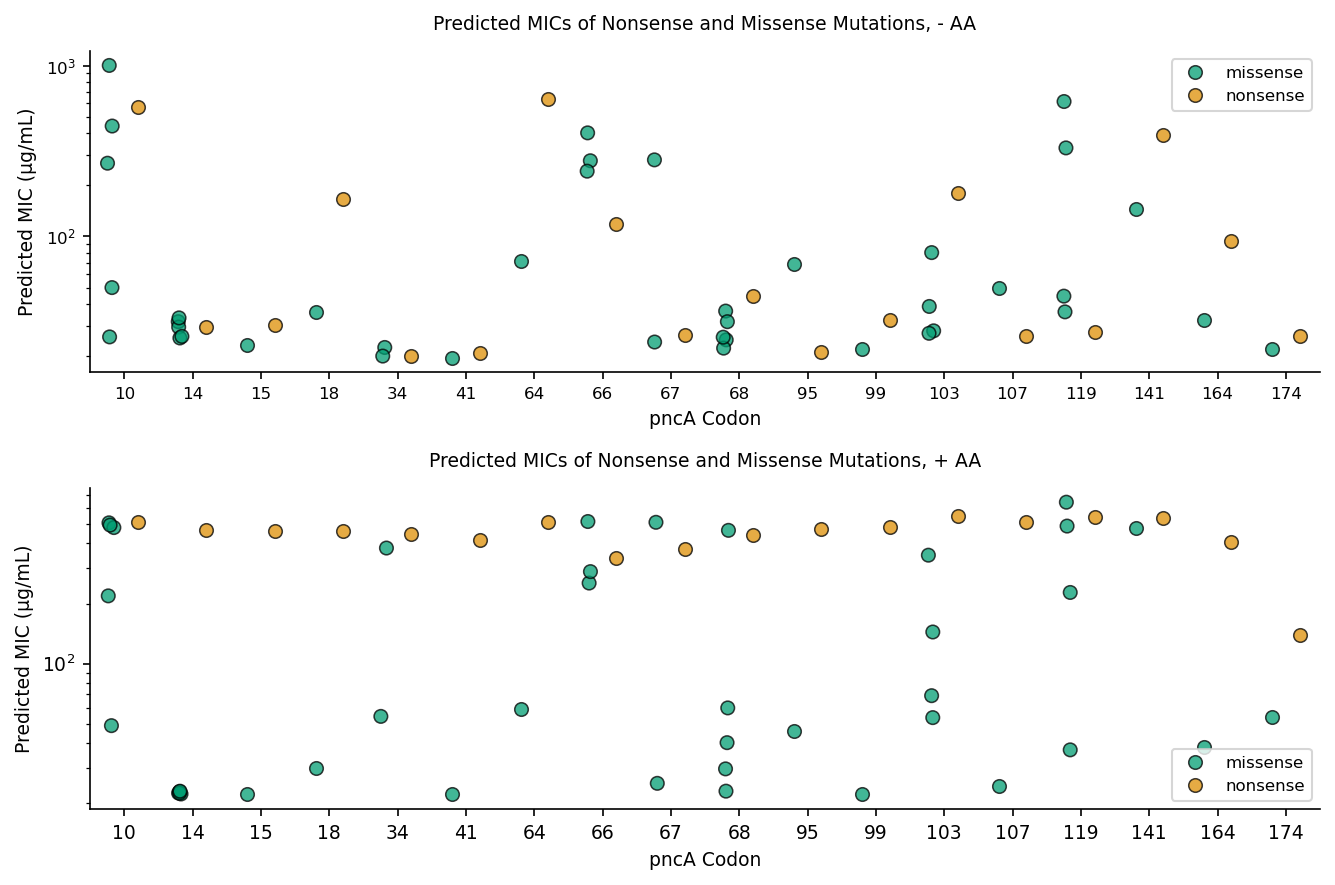

In [6]:
model_path_1 = "PZA_lineage"
model_path_2 = 'PZA_lineage_amino_acid'
locus = 'pncA'
gene = 'pncA'

missense_nonsense_muts_pncA = compare_missense_nonsense_predictions_two_models(model_path_1, locus, model_path_2, log_base=10, model_name_1='- AA', model_name_2='+ AA', V1=False, saveName=f"results/{abbr_drug_dict[model_path_1.split('_')[0]]}/nonsense_missense_lineage_comparison.svg")

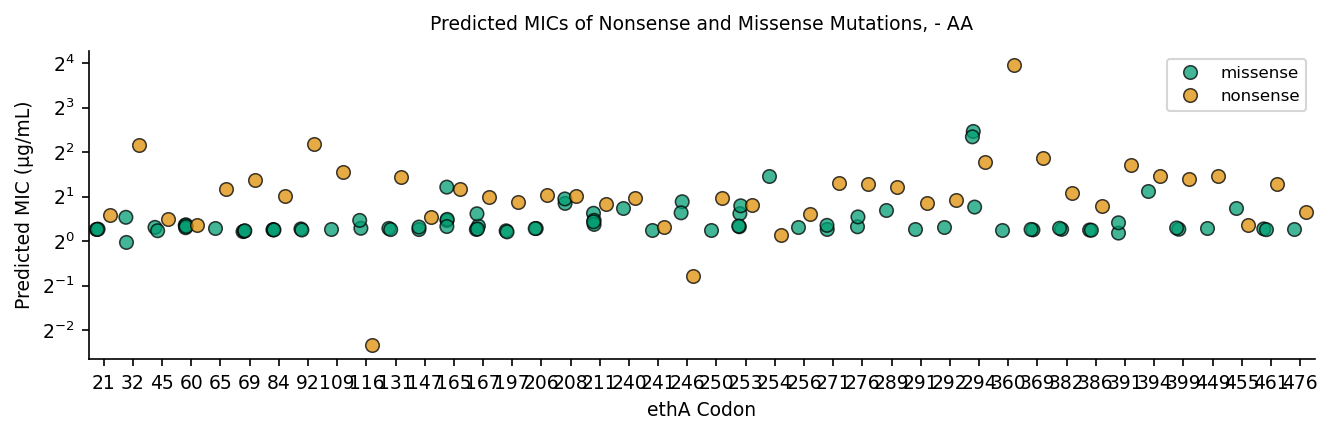

In [7]:
model_path_1 = "ETH_lineage_amino_acid"
locus = 'ethA'
gene = 'ethA'

missense_nonsense_muts_ethA = compare_missense_nonsense_predictions_two_models(model_path_1, locus, None, log_base=2, V1=False, saveName=f"results/{abbr_drug_dict[model_path_1.split('_')[0]]}/nonsense_missense_lineage_AA.svg")

In [8]:
pred_col = 'log2_pred_MIC'

missense_nonsense_muts_ethA_unmelt = missense_nonsense_muts_ethA.groupby(['codon', 'type'])[[pred_col]].mean().reset_index()
missense_nonsense_muts_ethA_unmelt = missense_nonsense_muts_ethA_unmelt.pivot(index='codon', columns='type', values=pred_col)

In [9]:
st.spearmanr(missense_nonsense_muts_ethA_unmelt['missense'],
             missense_nonsense_muts_ethA_unmelt['nonsense']
            )

SignificanceResult(statistic=-0.22939794181994977, pvalue=0.1439134288298177)

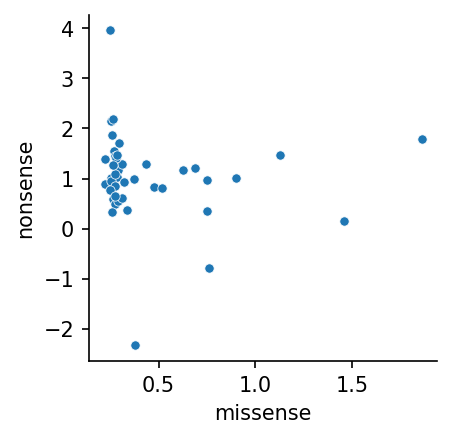

In [10]:
fig, ax = plt.subplots(figsize=(3, 3))

# same result as below for all possible mutations using the SSM results
sns.scatterplot(data=missense_nonsense_muts_ethA_unmelt,
                x='missense',
                y='nonsense',
                s=20,
                ax=ax
               )

sns.despine()
plt.show()

In [176]:
def which_nonsense_muts_present_in_training_data(df_phenos, df_nonsense, gene, drug):
    '''
    Get a boolean variable for whether each variant is present in the training dataset
    '''

    cc = cc_dict[drug]
    
    df_nonsense.rename(columns={'ROLLINGDB_ID': 'variant'}, inplace=True)

    if '-' in gene:
        gene = gene.split('-')[0]

    train_isolates_with_nonsense_muts_with_MICs = isolate_variants.query("GENE==@gene & EFFECT=='stop_gained' & variant != 'stop_gained'").merge(df_phenos[['ROLLINGDB_ID', f'{drug}_lower_bound', f'{drug}_midpoint', f'{drug}_upper_bound', 'category']], on='ROLLINGDB_ID').query("category=='train_set'")
    
    print(f"{train_isolates_with_nonsense_muts_with_MICs.ROLLINGDB_ID.nunique()} training isolates have early stop codons in {gene}")
    
    df_nonsense['train_nonsense'] = df_nonsense['variant'].isin(train_isolates_with_nonsense_muts_with_MICs.variant.values).astype(int)

    # add the average measured MIC for training set isolates with each nonsense mutation
    df_nonsense = df_nonsense.merge(pd.DataFrame(train_isolates_with_nonsense_muts_with_MICs.groupby('variant')[f'{drug}_midpoint'].mean()).reset_index(), how='left')

    # add a boolean variable to change the shape of the point using the average MIC midpoint
    df_nonsense['Train_phenotype'] = (df_nonsense[f"{drug}_midpoint"] >= cc).astype(int).map({0: 'Susceptible', 1: 'Resistant'})
        
    return df_nonsense
    
    

# def which_missense_muts_present_in_training_data(df_phenos, df_nonsense, gene):
#     '''
#     Get a boolean variable for whether each variant is present in the training dataset
#     '''

#     df_nonsense.rename(columns={'ROLLINGDB_ID': 'variant'}, inplace=True)
#     df_train = df_phenos.query("category=='train_set'")

#     if '-' in gene:
#         gene = gene.split('-')[0]

#     sense = h37Rv_full.query("Name==@gene")['Strand'].values[0]

#     nonsyn_muts_df = isolate_variants.query("ROLLINGDB_ID in @df_train.ROLLINGDB_ID & GENE==@gene & variant.str.contains('_p.')").reset_index(drop=True)

#     # add codon
#     nonsyn_muts_df['codon'] = nonsyn_muts_df['variant'].apply(get_variant_number, args=sense).astype(int)
    
#     df_nonsense['train_nonsilent'] = df_nonsense['codon'].isin(nonsyn_muts_df['codon']).astype(int)

#     return df_nonsense


    
def plot_nonsense_predictions(model_path, locus, figsize=(12, 7), saveName=None):

    drug = model_path.split('_')[0]
    cc = cc_dict[drug]
    gene = locus.split('-')[0]
    
    ssm_predictions = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis/saturation_mutagenesis", locus, "test_predictions.csv"))
    ssm_predictions = ssm_predictions.query("ROLLINGDB_ID.str.contains('\*') | ROLLINGDB_ID == 'MT_H37Rv'")
    
    # get the codon -- sense doesn't matter because return_start_and_end = False, so just use positive
    ssm_predictions['codon'] = ssm_predictions['ROLLINGDB_ID'].apply(get_variant_number, args=('+'))
    
    # remove H37Rv
    plot_df = ssm_predictions.query("ROLLINGDB_ID != 'MT_H37Rv'")

    # add annotation for whether or not each variant is in the training dataset
    df_phenos = pd.read_csv(os.path.join(data_dir, drug, 'data_for_model.csv'))
    plot_df = which_nonsense_muts_present_in_training_data(df_phenos, plot_df, locus, drug)
    # plot_df = which_missense_muts_present_in_training_data(df_phenos, plot_df, locus)

    hue_col = 'train_nonsense'
    plot_df[hue_col] = plot_df[hue_col].map({0: 'Train Absent', 1: 'Train Present'})
    color_palette = dict(zip(['Train Absent', 'Train Present'], sns.color_palette('colorblind').as_hex()))
    size_dict = {'Train Absent': 15, 'Train Present': 25}

    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
        
    sns.scatterplot(data=plot_df,
                      x='codon',
                      y='pred_MIC',
                      hue=hue_col,
                      palette=color_palette,
                      hue_order=['Train Absent', 'Train Present'],
                      # palette=dict(zip([model_name_1, model_name_2], sns.color_palette('colorblind').as_hex())),
                      alpha=0.9,
                      style='Train_phenotype',
                      markers={'Susceptible': "o", 'Resistant': "X"},
                      size=hue_col,
                      sizes=size_dict,
                      edgecolor='black',
                      linewidth=0.25,
                      ax=ax,
                      zorder=2,
                      legend=True
                     )

    h37Rv_predictions = ssm_predictions.query("ROLLINGDB_ID == 'MT_H37Rv'")['pred_MIC'].values[0]
    
    if drug == 'PZA':
        ax.set_yscale('log', base=10)
    else:
        ax.set_yscale('log', base=2)
        
    ax.axhline(y=h37Rv_predictions, color='black', linewidth=0.75, linestyle='--', zorder=0, label=f'H37Rv = {np.round(h37Rv_predictions, 2)} µg/mL')
    ax.axhline(y=cc, color='darkred', linewidth=0.75, linestyle='--', zorder=0, label=f'CC = {cc} µg/mL')
    ax.legend(ncol=1, loc='best', fontsize=8, title='')# loc='upper right', bbox_to_anchor=(0.5, -0.1))
    
    ax.set_xlabel(f"{gene} Residue (L = {plot_df.codon.max()})", fontsize=10)
    ax.set_ylabel('Predicted MIC (µg/mL)', fontsize=10)
    
    # ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize=9)
    # ax.set_yticklabels(labels=ax.get_yticklabels(), fontsize=9)
    
    ax.set_xlim(left=0, right=int(plot_df.codon.max()*1.01))
    ax.set_title(f"Predicted MICs for Nonsense mutations in {locus.split('-')[0]}")
    
    plt.tight_layout()
    sns.despine()

    if saveName is not None:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.mkdir(os.path.dirname(saveName))
            
        plt.savefig(saveName, bbox_inches='tight')
    else:
        plt.show()

    return plot_df

161 training isolates have early stop codons in ethA


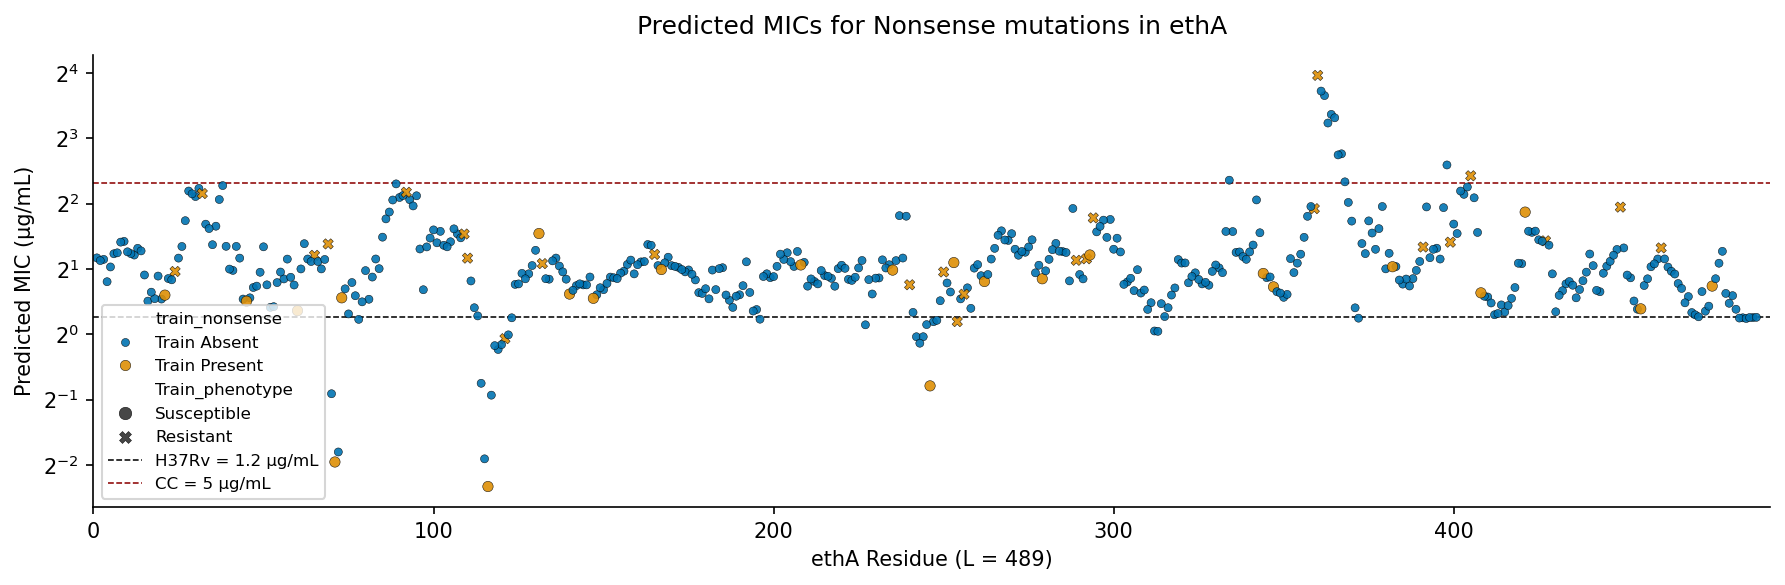

In [177]:
model_path = "ETH_lineage_amino_acid"
locus = 'ethA'

df_ETH_ethA_nonsense = plot_nonsense_predictions(model_path, locus=locus, saveName=f"results/{abbr_drug_dict[model_path.split('_')[0]]}/{locus}_nonsense_lineage_AA.svg")

In [178]:
len(df_ETH_ethA_nonsense.query("pred_MIC > 5")), len(df_ETH_ethA_nonsense), (len(df_ETH_ethA_nonsense)-len(df_ETH_ethA_nonsense.query("pred_MIC > 5")))/len(df_ETH_ethA_nonsense)

(12, 489, 0.9754601226993865)

1 training isolates have early stop codons in mshA


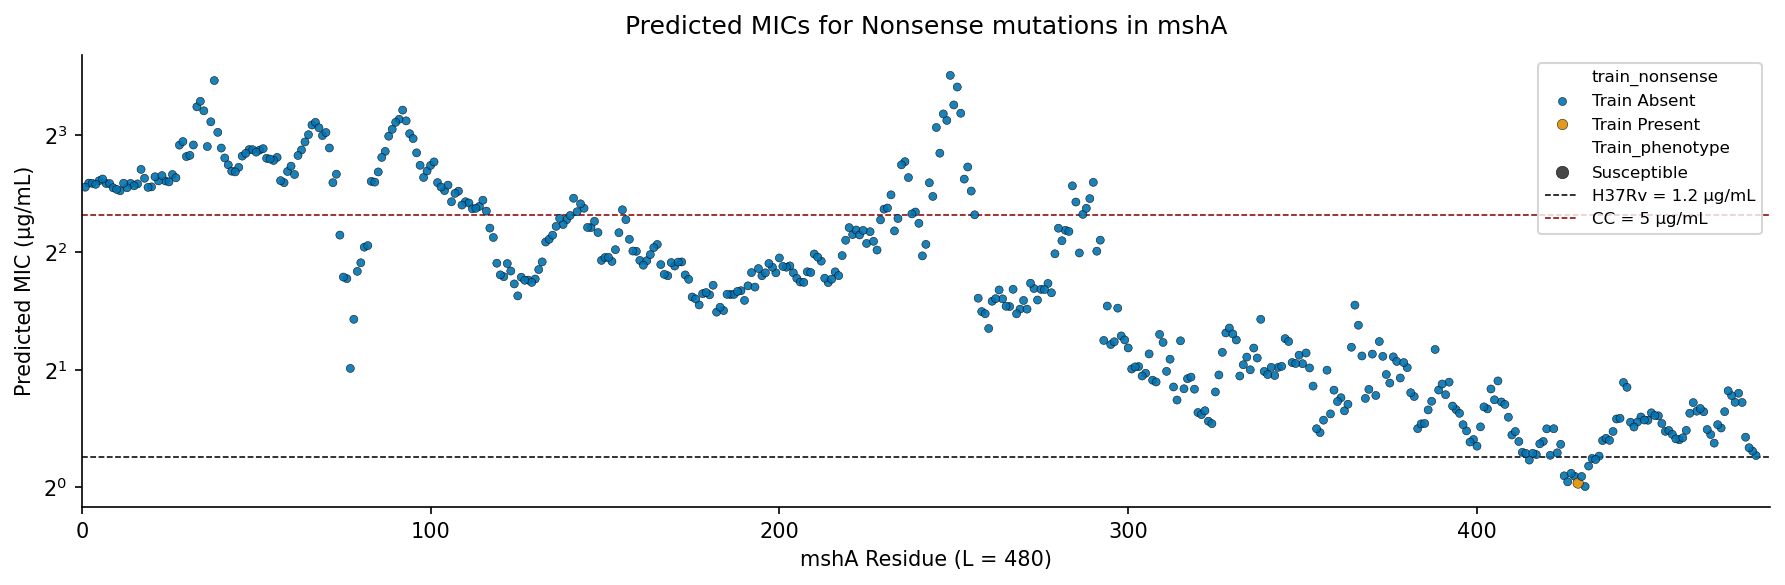

In [179]:
model_path = "ETH_lineage_amino_acid"
locus = 'mshA'

df_ETH_mshA_nonsense = plot_nonsense_predictions(model_path, locus=locus, saveName=f"results/{abbr_drug_dict[model_path.split('_')[0]]}/{locus}_nonsense_lineage_AA.svg")

In [180]:
st.spearmanr(df_ETH_mshA_nonsense['codon'], df_ETH_mshA_nonsense['pred_MIC'])

SignificanceResult(statistic=-0.8769451039284024, pvalue=3.216009118379783e-154)

17 training isolates have early stop codons in katG


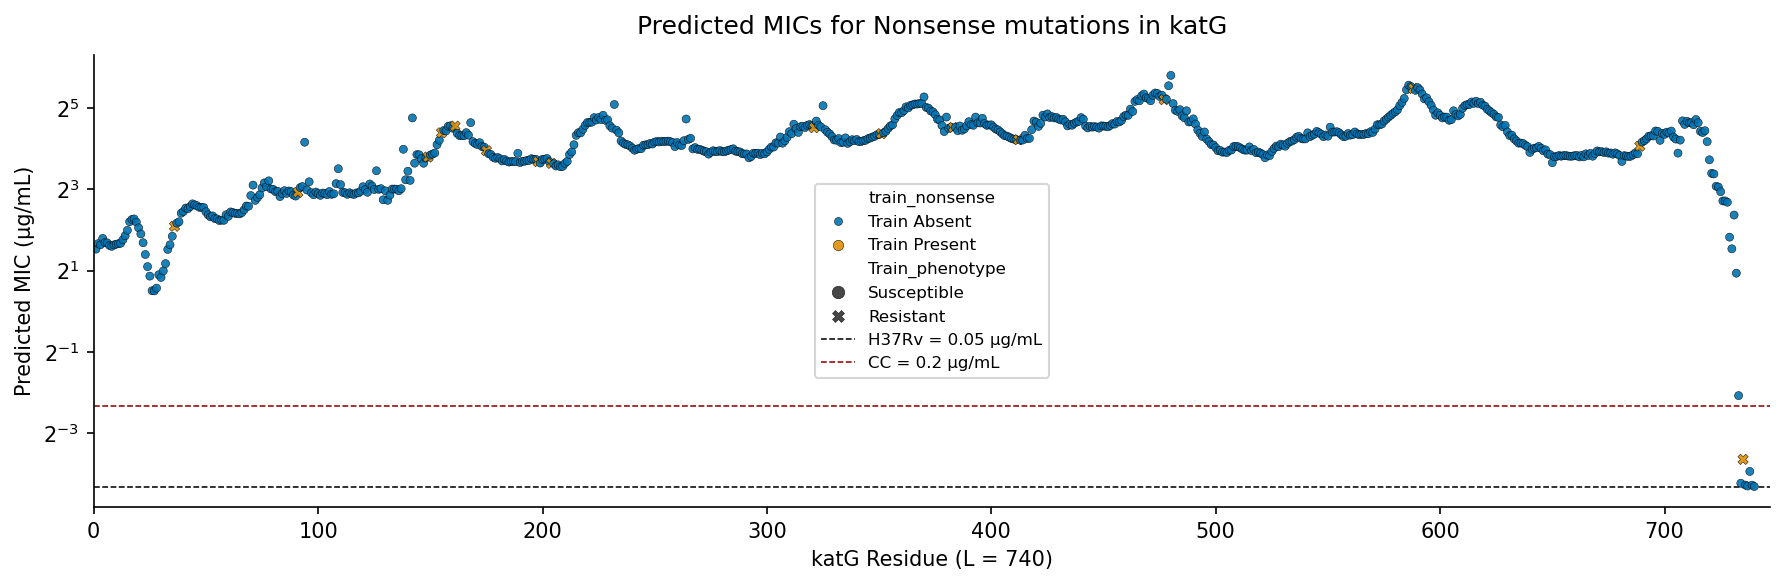

In [181]:
model_path = "INH_lineage_amino_acid"
locus = 'katG-furA'
gene = 'katG'

df_INH_katG = plot_nonsense_predictions(model_path, locus=locus, saveName=f"results/{abbr_drug_dict[model_path.split('_')[0]]}/{gene}_nonsense_lineage_AA.svg")

In [182]:
df_INH_katG.query("pred_MIC <= 1").sort_values("codon")

,variant,log2_pred_MIC,pred_MIC,codon,train_nonsense,INH_midpoint,Train_phenotype
732,katG_p.Asn733*,-2.077464,0.236931,733,Train Absent,NaN,Susceptible
733,katG_p.Leu734*,-4.235435,0.053089,734,Train Absent,NaN,Susceptible
734,katG_p.Asp735*,-3.647736,0.079785,735,Train Present,3.2,Resistant
735,katG_p.Arg736*,-4.280860,0.051444,736,Train Absent,NaN,Susceptible
736,katG_p.Phe737*,-4.304764,0.050598,737,Train Absent,NaN,Susceptible
737,katG_p.Asp738*,-3.945068,0.064926,738,Train Absent,NaN,Susceptible
738,katG_p.Val739*,-4.282197,0.051396,739,Train Absent,NaN,Susceptible
739,katG_p.Arg740*,-4.316831,0.050177,740,Train Absent,NaN,Susceptible


In [183]:
df_INH_katG.query("pred_MIC <= 0.2").sort_values("codon")

,variant,log2_pred_MIC,pred_MIC,codon,train_nonsense,INH_midpoint,Train_phenotype
733,katG_p.Leu734*,-4.235435,0.053089,734,Train Absent,NaN,Susceptible
734,katG_p.Asp735*,-3.647736,0.079785,735,Train Present,3.2,Resistant
735,katG_p.Arg736*,-4.280860,0.051444,736,Train Absent,NaN,Susceptible
736,katG_p.Phe737*,-4.304764,0.050598,737,Train Absent,NaN,Susceptible
737,katG_p.Asp738*,-3.945068,0.064926,738,Train Absent,NaN,Susceptible
738,katG_p.Val739*,-4.282197,0.051396,739,Train Absent,NaN,Susceptible
739,katG_p.Arg740*,-4.316831,0.050177,740,Train Absent,NaN,Susceptible


In [184]:
df_INH_phenos = pd.read_csv(os.path.join(data_dir, "INH", "data_for_model.csv"))

isolate_variants.query("variant=='katG_p.Asp735*'").merge(df_INH_phenos[['ROLLINGDB_ID', 'INH_lower_bound', 'INH_upper_bound', 'category']])

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,INH_lower_bound,INH_upper_bound,category
0,2153907,GTC,CTA,Amb,3100.0,False,0.77,89.0,37.0,60.0,...,katG,c.2203_2205delGACinsTAG,p.Asp735*,katG_p.Asp735*,NaN,NaN,SAMEA3558168,3.2,inf,train_set


In [185]:
isolate_variants.query("ROLLINGDB_ID=='SAMEA3558168' & drug=='Isoniazid'")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
93625,2726210,T,C,PASS,5684.0,False,1.0,154.0,37.0,60.0,0.0,0.0,synonymous_variant,ahpC,c.18T>C,p.Ile6Ile,ahpC_c.18T>C,Isoniazid,4) Not assoc w R - Interim,SAMEA3558168


In [186]:
who_variants.query("variant=='katG_p.Asp735*'")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1


15 training isolates have early stop codons in pncA


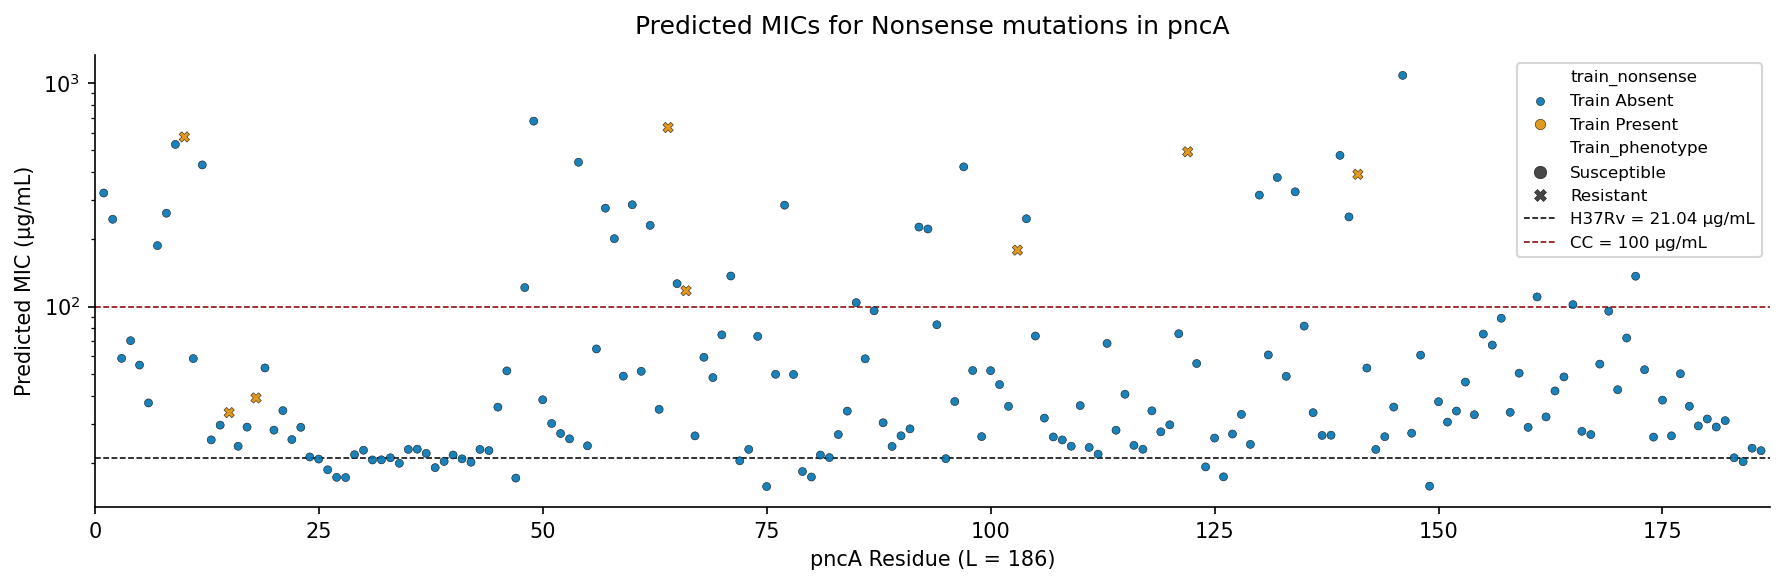

In [187]:
model_path = "PZA_lineage"
locus = 'pncA'

df_PZA_pncA = plot_nonsense_predictions(model_path, locus=locus, saveName=f"results/{abbr_drug_dict[model_path.split('_')[0]]}/{locus}_nonsense_lineage.svg")

15 training isolates have early stop codons in pncA


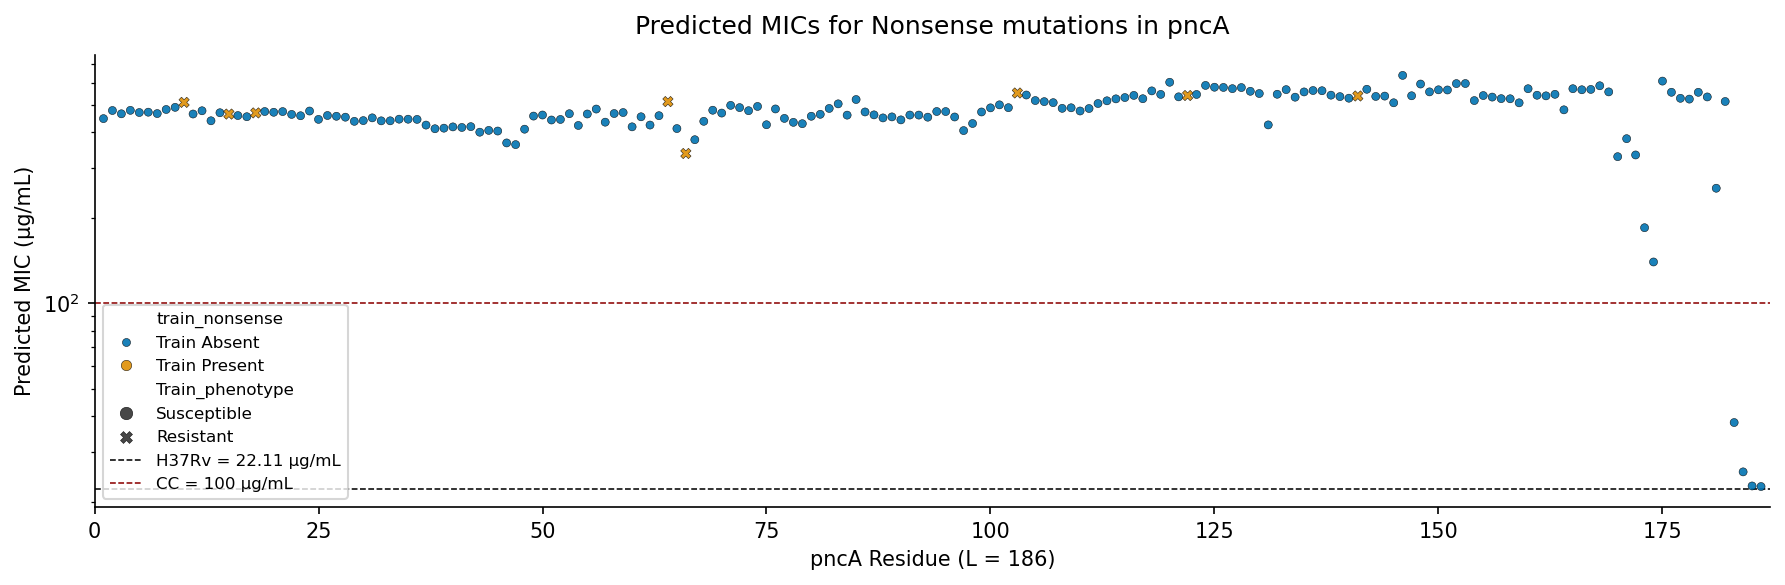

In [188]:
model_path = "PZA_lineage_amino_acid"
locus = 'pncA'

df_PZA_pncA_AA = plot_nonsense_predictions(model_path, locus=locus, saveName=f"results/{abbr_drug_dict[model_path.split('_')[0]]}/{locus}_nonsense_lineage_AA.svg")

In [20]:
df_PZA_phenos = pd.read_csv(os.path.join(data_dir, "PZA", "data_for_model.csv"))
gene = 'pncA'

In [39]:
ssm_predictions

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC
0,pncA_p.Ala102*,8.934552,489.292100
20,pncA_p.Ala134*,9.057273,532.734500
40,pncA_p.Ala143*,9.065990,535.963300
60,pncA_p.Ala146*,9.312489,635.826200
80,pncA_p.Ala152*,9.216459,594.881840
...,...,...,...
3640,pncA_p.Val7*,8.865615,466.461730
3641,pncA_p.Val73*,8.899176,477.440000
3680,pncA_p.Val9*,8.938316,490.570400
3681,pncA_p.Val93*,8.823195,452.946080


102

In [58]:
model_path = "PZA_lineage_amino_acid"
locus = 'pncA'
gene = 'pncA'

ssm_predictions = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis/saturation_mutagenesis", locus, "test_predictions.csv"))
ssm_predictions = ssm_predictions.query("ROLLINGDB_ID.str.contains('\*') | ROLLINGDB_ID == 'MT_H37Rv'")

# get the codon
ssm_predictions['codon'] = ssm_predictions['ROLLINGDB_ID'].apply(get_variant_number, args=('+'))

# remove H37Rv
df_nonsense = ssm_predictions.query("ROLLINGDB_ID != 'MT_H37Rv'")

# for i, row in ssm_predictions.iterrows():
#     if row['ROLLINGDB_ID'] != 'MT_H37Rv':
#         ssm_predictions.loc[i, 'codon'] = get_variant_number(row['ROLLINGDB_ID'], '+')



# # add annotation for whether or not each variant is in the training dataset
drug = 'PZA'
df_phenos = pd.read_csv(os.path.join(data_dir, drug, 'data_for_model.csv'))
# df_nonsense = which_nonsense_muts_present_in_training_data(df_phenos, plot_df, locus)

In [63]:
df_nonsense.rename(columns={'ROLLINGDB_ID': 'variant'}, inplace=True)
df_train = df_phenos.query("category=='train_set'")

if '-' in gene:
    gene = gene.split('-')[0]

isolates_with_nonsense_muts = isolate_variants.query("ROLLINGDB_ID in @df_train.ROLLINGDB_ID & GENE==@gene & EFFECT=='stop_gained' & variant != 'stop_gained'")
isolates_with_nonsense_muts_with_MICs = isolates_with_nonsense_muts.merge(df_phenos[['ROLLINGDB_ID', f'{drug}_lower_bound', f'{drug}_midpoint', f'{drug}_upper_bound']], on='ROLLINGDB_ID')

print(f"{isolates_with_nonsense_muts.ROLLINGDB_ID.nunique()} training isolates have early stop codons in {gene}")

df_nonsense['train_nonsense'] = df_nonsense['variant'].isin(isolates_with_nonsense_muts.variant.values).astype(int)
df_nonsense.merge(pd.DataFrame(isolates_with_nonsense_muts_with_MICs.groupby('variant')[f'{drug}_midpoint'].mean()).reset_index(), how='left')

15 training isolates have early stop codons in pncA


In [72]:
df_nonsense = df_nonsense.merge(pd.DataFrame(isolates_with_nonsense_muts_with_MICs.groupby('variant')[f'{drug}_midpoint'].mean()).reset_index(), how='left')

In [75]:
cc = 100
df_nonsense['R_MIC'] = (df_nonsense[f"{drug}_midpoint"] >= cc).astype(int)

In [77]:
df_nonsense.R_MIC.value_counts()

R_MIC
0    178
1      8
Name: count, dtype: int64

In [ ]:
def which_nonsense_muts_present_in_training_data(df_phenos, df_nonsense, gene):
    '''
    Get a boolean variable for whether each variant is present in the training dataset
    '''
    
    df_nonsense['variant'] = df_nonsense['ROLLINGDB_ID'].str.replace('_p_', '_p.').str.replace('+', '*')
    df_train = df_phenos.query("category=='train_set'")

    if '-' in gene:
        gene = gene.split('-')[0]

    isolates_with_nonsense_muts = isolate_variants.query("ROLLINGDB_ID in @df_train.ROLLINGDB_ID & GENE==@gene & EFFECT=='stop_gained' & variant != 'stop_gained'")
    
    print(f"{isolates_with_nonsense_muts.ROLLINGDB_ID.nunique()} training isolates have early stop codons in {gene}")

    df_nonsense['train_nonsense'] = df_nonsense['variant'].isin(isolates_with_nonsense_muts.variant.values).astype(int)
    df_nonsense['avg_train_MIC'] = 
    
    return df_nonsense

In [101]:
isolate_variants.query("GENE=='pncA' & EFFECT=='stop_gained' & variant != 'stop_gained'").merge(df_PZA_phenos[['ROLLINGDB_ID', f'PZA_lower_bound', f'PZA_upper_bound', 'Coll2014', 'category']], on='ROLLINGDB_ID').sort_values("variant")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,PZA_lower_bound,PZA_upper_bound,Coll2014,category
13,2289214,G,A,PASS,2047.0,False,1.00,55.0,37.0,60.0,...,c.28C>T,p.Gln10*,pncA_p.Gln10*,Pyrazinamide,1) Assoc w R,SAMN05918713,500.0,inf,4.6.1.2,train_set
11,2289214,G,A,PASS,1510.0,False,1.00,40.0,38.0,60.0,...,c.28C>T,p.Gln10*,pncA_p.Gln10*,Pyrazinamide,1) Assoc w R,SAMN05918629,500.0,inf,4.1.2.1,train_set
16,2288878,G,A,PASS,6086.0,False,0.99,163.0,38.0,60.0,...,c.364C>T,p.Gln122*,pncA_p.Gln122*,Pyrazinamide,1) Assoc w R,SAMN06094099,500.0,inf,4.3.4.2,train_set
7,2288878,G,A,PASS,5203.0,False,0.99,136.0,39.0,60.0,...,c.364C>T,p.Gln122*,pncA_p.Gln122*,Pyrazinamide,1) Assoc w R,SAMN05916405,500.0,inf,4.1.2.1,test_set
9,2288878,G,A,PASS,4130.0,False,1.00,105.0,39.0,60.0,...,c.364C>T,p.Gln122*,pncA_p.Gln122*,Pyrazinamide,1) Assoc w R,SAMN05916453,500.0,inf,4.1.2.1,train_set
2,2288821,G,A,Amb,3484.0,False,0.46,111.0,37.0,60.0,...,c.421C>T,p.Gln141*,pncA_p.Gln141*,Pyrazinamide,1) Assoc w R,SAMN05916232,500.0,inf,4.3.4.2,train_set
10,2289199,C,A,PASS,3003.0,False,1.00,78.0,39.0,60.0,...,c.43G>T,p.Glu15*,pncA_p.Glu15*,Pyrazinamide,2) Assoc w R - Interim,SAMN05918561,500.0,inf,4.1.1.3,train_set
12,2289189,G,T,PASS,4840.0,False,1.00,131.0,37.0,60.0,...,c.53C>A,p.Ser18*,pncA_p.Ser18*,Pyrazinamide,2) Assoc w R - Interim,SAMN05918630,500.0,inf,4.1.1,train_set
1,2289045,G,T,PASS,5066.0,False,0.99,147.0,36.0,60.0,...,c.197C>A,p.Ser66*,pncA_p.Ser66*,Pyrazinamide,2) Assoc w R - Interim,SAMN05915262,200.0,300.0,4.3.3,train_set
0,2288933,G,C,Amb,1504.0,False,0.64,93.0,37.0,59.0,...,c.309C>G,p.Tyr103*,pncA_p.Tyr103*,Pyrazinamide,1) Assoc w R,SAMEA3416725,500.0,inf,4.3.3,train_set


In [17]:
df_PZA_pncA_AA.query("pred_MIC < 100").sort_values("codon")

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,codon,variant,train_nonsense
3560,pncA_p_Val183+,5.247876,37.998646,183,pncA_p.Val183*,Train Absent
1100,pncA_p_Cys184+,4.670224,25.461124,184,pncA_p.Cys184*,Train Absent
2661,pncA_p_Ser185+,4.505193,22.709007,185,pncA_p.Ser185*,Train Absent
2681,pncA_p_Ser186+,4.498594,22.605381,186,pncA_p.Ser186*,Train Absent


In [18]:
df_PZA_pncA_AA.query("pred_MIC > 100 & pred_MIC < 400").sort_values("pred_MIC")

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,codon,variant,train_nonsense
1320,pncA_p_Glu174+,7.127795,139.85570,174,pncA_p.Glu174*,Train Absent
1300,pncA_p_Glu173+,7.529136,184.71231,173,pncA_p.Glu173*,Train Absent
1340,pncA_p_Glu181+,7.991194,254.44214,181,pncA_p.Glu181*,Train Absent
140,pncA_p_Ala170+,8.360959,328.77550,170,pncA_p.Ala170*,Train Absent
2120,pncA_p_Leu172+,8.380864,333.34310,172,pncA_p.Leu172*,Train Absent
2780,pncA_p_Ser66+,8.398099,337.34920,66,pncA_p.Ser66*,Train Present
3080,pncA_p_Thr47+,8.502134,362.57468,47,pncA_p.Thr47*,Train Absent
380,pncA_p_Ala46+,8.521642,367.51053,46,pncA_p.Ala46*,Train Absent
2800,pncA_p_Ser67+,8.559485,377.27832,67,pncA_p.Ser67*,Train Absent
160,pncA_p_Ala171+,8.571507,380.43533,171,pncA_p.Ala171*,Train Absent


In [58]:
df_PZA_pncA_AA.query("codon >= 175").sort_values("codon")

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,codon,variant,train_nonsense
2301,pncA_p_Met175+,9.245624,607.029850,175,pncA_p.Met175*,Train Absent
580,pncA_p_Arg176+,9.114835,554.419740,176,pncA_p.Arg176*,Train Absent
3040,pncA_p_Thr177+,9.044173,527.919200,177,pncA_p.Thr177*,Train Absent
180,pncA_p_Ala178+,9.034869,524.525500,178,pncA_p.Ala178*,Train Absent
2640,pncA_p_Ser179+,9.114339,554.229200,179,pncA_p.Ser179*,Train Absent
3540,pncA_p_Val180+,9.060210,533.820250,180,pncA_p.Val180*,Train Absent
1340,pncA_p_Glu181+,7.991194,254.442140,181,pncA_p.Glu181*,Train Absent
2140,pncA_p_Leu182+,9.006848,514.436200,182,pncA_p.Leu182*,Train Absent
3560,pncA_p_Val183+,5.247876,37.998646,183,pncA_p.Val183*,Train Absent
1100,pncA_p_Cys184+,4.670224,25.461124,184,pncA_p.Cys184*,Train Absent


In [61]:
pncA_missense.loc[170:174].mean(axis=1).mean()

0.664004262302512

In [62]:
pncA_missense.loc[170:174]

mut_AA,Ala,Arg,Asn,Asp,Cys,Gln,Glu,Gly,His,Ile,Leu,Lys,Met,Phe,Pro,Ser,Thr,Trp,Tyr,Val
170,0.000000,3.218019,0.812878,0.389122,-0.014418,0.161593,0.428177,0.001240,-0.005107,0.037372,-0.019678,1.956149,0.054433,-0.043336,0.001622,0.448316,0.240531,0.020190,-0.042722,-0.025928
171,0.000000,4.530335,4.564098,4.575149,0.371336,4.654960,4.656093,0.047338,4.135803,0.051005,-0.018484,4.563026,0.077259,0.061078,0.367763,1.532525,0.970901,0.061790,0.929791,0.060190
172,0.131222,2.684034,1.036201,1.524441,0.056636,1.170391,1.303170,0.420164,0.901879,0.096231,0.000000,2.311193,0.066030,0.021486,0.197366,0.098617,0.771584,0.044893,0.369248,0.019836
173,0.046109,0.441212,0.025207,0.006987,0.011195,0.104886,0.000000,-0.003475,0.070949,0.245520,0.520830,0.066466,0.002453,0.045033,-0.036595,-0.008338,0.063876,-0.001666,0.021332,0.326757
174,0.620030,1.479825,0.237018,0.100972,0.073354,0.018456,0.000000,0.965334,0.736633,0.030367,0.053696,0.117266,-0.025795,0.460098,0.302358,-0.058598,0.269720,-0.047304,0.198398,1.884827


In [ ]:
Residues 170-174 have lower MIC predictions for nonsense mutations than the surrounding residues. This may be due to confounding between nonsense and missense mutations. The average log2 fold change for missense mutations in pncA is 0.99. The average values for residues 170-174 are 0.38, 1.8, 0.66, 0.097, and 0.37, in that order. 

In [60]:
# 181 is a hot spot
pncA_missense.loc[175:182].mean(axis=1).mean()

1.7189489494184171

In [ ]:
The average log2 fold change for residues 175-182 

In [59]:
# 181 is a hot spot
pncA_missense.loc[183:].mean(axis=1)

183    0.622206
184    0.468201
185    0.113912
186    0.090164
dtype: float64

In [98]:
who_variants.query("gene=='pncA' & variant.str.contains('66') & effect=='missense_variant'")[['variant', 'Present_SOLO_R', 'Present_SOLO_S', 'Present_R', 'Present_S']]

,variant,Present_SOLO_R,Present_SOLO_S,Present_R,Present_S
36133,pncA_p.Ser66Ala,0.0,1.0,0.0,1.0
36135,pncA_p.Ser66Leu,0.0,9.0,0.0,9.0
36136,pncA_p.Ser66Pro,6.0,0.0,6.0,0.0


In [30]:
all_drugs_insilico_pred.query("variant=='pncA_p_Ser66Ala'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
796,pncA_p_Ser66Ala,7.984608,253.28322,missense_variant,100.0,pncA,3) Uncertain significance,22.105331,11.458015,3.518285,pncA,Pyrazinamide


In [20]:
all_drugs_insilico_pred.query("variant=='pncA_p_Ser66Leu'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
797,pncA_p_Ser66Leu,8.175458,289.10666,missense_variant,100.0,pncA,4) Not assoc w R - Interim,22.105331,13.078594,3.709136,pncA,Pyrazinamide


In [42]:
all_drugs_insilico_pred.query("variant=='pncA_p_Thr160_Ala171del'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
821,pncA_p_Thr160_Ala171del,9.588107,769.67584,inframe_deletion,100.0,pncA,3) Uncertain significance,22.105331,34.818562,5.121785,pncA,Pyrazinamide


In [92]:
who_variants.query("gene=='pncA' & variant.str.contains('182') & effect=='missense_variant'")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,compatible_variant
36037,Pyrazinamide,pncA,p.Leu182Phe,pncA_p.Leu182Phe,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,5.0,1.0,...,3) Uncertain significance,NaN,No change,NaN,NaN,no,NaN,NaN,1,pncA_p_Leu182Phe
36038,Pyrazinamide,pncA,p.Leu182Ser,pncA_p.Leu182Ser,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,18.0,14.0,...,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1,pncA_p_Leu182Ser
36039,Pyrazinamide,pncA,p.Leu182Trp,pncA_p.Leu182Trp,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,6.0,6.0,...,1) Assoc w R,NaN,UP from AwRI to AwR,NaN,NaN,yes,NaN,NaN,4,pncA_p_Leu182Trp


In [78]:
pncA_missense.mean(axis=1).mean()

0.987868147704111

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,PZA_lower_bound,PZA_upper_bound,Coll2014,category
0,2289239,C,T,PASS,3040.0,False,0.97,93.0,38.0,60.0,...,c.3G>A,p.Met1?,pncA_c.3G>A,Pyrazinamide,4) Not assoc w R - Interim,SAMN05916261,500.0,inf,2.2.1,train_set


In [41]:
isolate_variants.query("ROLLINGDB_ID=='SAMN05916261' & drug=='Pyrazinamide'")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
113980,1406760,T,TG,PASS,3658.0,False,1.02,98.0,37.0,60.0,100.0,0.0,frameshift_variant,Rv1258c,c.580_581insC,p.Glu194fs,Rv1258c_p.Glu194fs,Pyrazinamide,3) Uncertain significance,SAMN05916261
113993,1834177,A,C,PASS,4066.0,False,1.00,110.0,37.0,60.0,0.0,0.0,synonymous_variant,rpsA,c.636A>C,p.Arg212Arg,rpsA_c.636A>C,Pyrazinamide,4) Not assoc w R - Interim,SAMN05916261
113998,2167926,A,G,PASS,3634.0,False,0.99,105.0,36.0,60.0,0.0,0.0,missense_variant,PPE35,c.2687T>C,p.Leu896Ser,PPE35_p.Leu896Ser,Pyrazinamide,5) Not assoc w R,SAMN05916261
114003,2289239,C,T,PASS,3040.0,False,0.97,93.0,38.0,60.0,0.0,0.0,initiator_codon_variant,pncA,c.3G>A,p.Met1?,pncA_c.3G>A,Pyrazinamide,4) Not assoc w R - Interim,SAMN05916261


In [84]:
pncA_missense.mean().mean()

0.9878681477041112

In [44]:
# search_lst = df_PZA_pncA_AA.query("pred_MIC > 100 & pred_MIC < 400").sort_values("pred_MIC").codon.unique().astype(str)
search_lst = np.arange(175, 186+1).astype(str)

isolate_variants.query("GENE=='pncA' & variant.str.contains('|'.join(@search_lst)) & EFFECT=='stop_gained'").merge(df_PZA_phenos[['ROLLINGDB_ID', f'PZA_lower_bound', f'PZA_upper_bound', 'Coll2014', 'category']], on='ROLLINGDB_ID')

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,PZA_lower_bound,PZA_upper_bound,Coll2014,category


In [46]:
search_lst

array(['175', '176', '177', '178', '179', '180', '181', '182', '183',
       '184', '185', '186'], dtype='<U21')

In [49]:
who_variants.query("gene=='pncA' & effect=='stop_gained' & variant.str.contains('|'.join(@search_lst))")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,compatible_variant
35923,Pyrazinamide,pncA,p.Glu181*,pncA_p.Glu181*,1,stop_gained,"(see ""Genomic_coordinates"" sheet)",1.0,1.0,1.0,...,2) Assoc w R - Interim,NaN,No change,NaN,NaN,no,NaN,NaN,1,pncA_p_Glu181+


In [94]:
isolate_variants.query("GENE=='pncA' & variant.str.contains('174')").merge(df_PZA_phenos[['ROLLINGDB_ID', f'PZA_lower_bound', f'PZA_upper_bound', 'Coll2014', 'category']], on='ROLLINGDB_ID')

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,PZA_lower_bound,PZA_upper_bound,Coll2014,category


In [63]:
df_protein_seqs = pd.read_csv(os.path.join(f"{results_dir}/PZA/df_protein_seqs.csv"))
df_protein_seqs.columns

Index(['category', 'ROLLINGDB_ID', 'Rv2042c_AA', 'pncA_AA', 'panD_AA',
       'panC_AA', 'Rv3603c_AA', 'rpsA_AA', 'clpC1_AA', 'sigE_AA', 'Rv3236c_AA',
       'Rv3237c_AA', 'Rv1258c_AA'],
      dtype='object')

In [57]:
df_protein_seqs.query("ROLLINGDB_ID=='SAMN06010466'")['pncA_AA'].values[0]

'MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVATKDFHIDPGDHFSGTPDYSSSWPPHCVSGTPGADFHPSLDTSAIEAVFYKGAYTGAYSGFEGVDENGTPLLNWLRQRGVDEVDVVGIATDHCVRQTAEDAVRNGLATRVLVDLTAGVSADTTVAAGGDAHRQRRVGLQLL-----'

In [61]:
len("GGDAHRQRRVGLQLL")

15

In [58]:
df_protein_seqs.query("ROLLINGDB_ID=='MT_H37Rv'")['pncA_AA'].values[0]

'MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVATKDFHIDPGDHFSGTPDYSSSWPPHCVSGTPGADFHPSLDTSAIEAVFYKGAYTGAYSGFEGVDENGTPLLNWLRQRGVDEVDVVGIATDHCVRQTAEDAVRNGLATRVLVDLTAGVSADTTVAALEEMRTASVELVCSS-----'

In [60]:
len("MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVATKDFHIDPGDHFSGTPDYSSSWPPHCVSGTPGADFHPSLDTSAIEAVFYKGAYTGAYSGFEGVDENGTPLLNWLRQRGVDEVDVVGIATDHCVRQTAEDAVRNGLATRVLVDLTAGVSADTTVAA")

171

In [59]:
len("LEEMRTASVELVCSS")

15

In [43]:
# search_lst = df_PZA_pncA_AA.query("pred_MIC > 100 & pred_MIC < 400").sort_values("pred_MIC").codon.unique().astype(str)
search_lst = np.arange(170, 174+1).astype(str)

isolate_variants.query("GENE=='pncA' & variant.str.contains('|'.join(@search_lst)) & ROLLINGDB_ID in @df_PZA_phenos.ROLLINGDB_ID")

,ROLLINGDB_ID,DB_OF_ORIGIN,MEDIA,MEDIA_NORM,PZA_lower_bound,PZA_midpoint,PZA_upper_bound,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,Span_CC,Binary,Stratify,category
0,SAMEA3392626,farhat_internal,MGIT,MGIT,20.0,35.0,50.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.034619,4.2.2,4.2.2.1,tur,NaN,4,4,0,0.0,4-0,train_set


In [32]:
df_PZA_phenos = pd.read_csv(os.path.join(data_dir, "PZA", "data_for_model.csv"))

In [90]:
isolate_variants.query("GENE=='pncA' & EFFECT=='missense_variant' & variant.str.contains('17')").merge(df_PZA_phenos[['ROLLINGDB_ID', 'PZA_lower_bound', 'PZA_upper_bound']], on='ROLLINGDB_ID')

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,PZA_lower_bound,PZA_upper_bound
0,2288713,T,G,PASS,2058.0,False,1.00,64.0,32.0,60.0,...,missense_variant,pncA,c.529A>C,p.Thr177Pro,pncA_p.Thr177Pro,Pyrazinamide,1) Assoc w R,SAMEA3392667,20.0,50.0
1,2288718,A,G,PASS,4579.0,False,1.00,125.0,37.0,60.0,...,missense_variant,pncA,c.524T>C,p.Met175Thr,pncA_p.Met175Thr,Pyrazinamide,2) Assoc w R - Interim,SAMN05916242,500.0,inf
2,2288730,G,T,PASS,3889.0,False,0.94,149.0,35.0,60.0,...,missense_variant,pncA,c.512C>A,p.Ala171Glu,pncA_p.Ala171Glu,Pyrazinamide,2) Assoc w R - Interim,SAMN05916279,500.0,inf
3,2288719,T,C,PASS,3795.0,False,1.00,104.0,36.0,60.0,...,missense_variant,pncA,c.523A>G,p.Met175Val,pncA_p.Met175Val,Pyrazinamide,1) Assoc w R,SAMN05916289,500.0,inf
4,2288730,G,A,Amb,943.0,False,0.31,93.0,39.0,60.0,...,missense_variant,pncA,c.512C>T,p.Ala171Val,pncA_p.Ala171Val,Pyrazinamide,3) Uncertain significance,SAMN05916399,500.0,inf
5,2288730,G,C,PASS,5666.0,False,1.00,143.0,40.0,60.0,...,missense_variant,pncA,c.512C>G,p.Ala171Gly,pncA_p.Ala171Gly,Pyrazinamide,3) Uncertain significance,SAMN05916414,25.0,50.0
6,2288717,C,T,PASS,2350.0,False,1.00,64.0,37.0,60.0,...,missense_variant,pncA,c.525G>A,p.Met175Ile,pncA_p.Met175Ile,Pyrazinamide,2) Assoc w R - Interim,SAMN05918714,100.0,120.0
7,2288717,C,T,PASS,2541.0,False,0.99,71.0,37.0,60.0,...,missense_variant,pncA,c.525G>A,p.Met175Ile,pncA_p.Met175Ile,Pyrazinamide,2) Assoc w R - Interim,SAMN05918717,50.0,100.0
8,2288718,A,C,PASS,6356.0,False,1.00,166.0,38.0,60.0,...,missense_variant,pncA,c.524T>G,p.Met175Arg,pncA_p.Met175Arg,Pyrazinamide,1) Assoc w R,SAMN06094114,500.0,inf


In [91]:
st.spearmanr(df_PZA_pncA_AA['codon'], df_PZA_pncA_AA['pred_MIC'])

SignificanceResult(statistic=0.4723514958809076, pvalue=9.992238871244367e-12)

In [92]:
num_pred_R = len(df_PZA_pncA.query('pred_MIC > 100'))
num_total = len(df_PZA_pncA)

print(f"{num_pred_R}/{num_total} ({np.round(num_pred_R/num_total, 2)*100})% pncA mutations predicted to cause R")

36/186 (19.0)% pncA mutations predicted to cause R


In [93]:
num_pred_R = len(df_PZA_pncA_AA.query('pred_MIC > 100'))
num_total = len(df_PZA_pncA_AA)

print(f"{num_pred_R}/{num_total} ({np.round(num_pred_R/num_total, 2)*100})% pncA mutations predicted to cause R")

182/186 (98.0)% pncA mutations predicted to cause R


In [23]:
df_PZA_pncA_AA.query("pred_MIC <= 100").sort_values("codon")

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,codon,variant,train_nonsense
3560,pncA_p_Val183+,5.247876,37.998646,183,pncA_p.Val183*,Train Absent
1100,pncA_p_Cys184+,4.670224,25.461124,184,pncA_p.Cys184*,Train Absent
2661,pncA_p_Ser185+,4.505193,22.709007,185,pncA_p.Ser185*,Train Absent
2681,pncA_p_Ser186+,4.498594,22.605381,186,pncA_p.Ser186*,Train Absent


In [15]:
df_PZA_pncA_AA.query("codon==182")

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,codon,variant,train_nonsense
2140,pncA_p_Leu182+,7.003441,128.3057,182,pncA_p.Leu182*,Train Absent


In [14]:
df_PZA_pncA_AA.query("pred_MIC <= 100").sort_values("codon")

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,codon,variant,train_nonsense
1340,pncA_p_Glu181+,6.616730,98.137310,181,pncA_p.Glu181*,Train Absent
3560,pncA_p_Val183+,6.133023,70.181690,183,pncA_p.Val183*,Train Absent
1100,pncA_p_Cys184+,5.374344,41.480010,184,pncA_p.Cys184*,Train Absent
2661,pncA_p_Ser185+,5.276850,38.769500,185,pncA_p.Ser185*,Train Absent
2681,pncA_p_Ser186+,5.033194,32.744804,186,pncA_p.Ser186*,Train Absent


In [23]:
df_PZA_phenos = pd.read_csv(os.path.join(data_dir, "PZA", "data_for_model.csv"))

In [22]:
isolate_variants.query("variant=='pncA_p.Ser66*'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug_V2,confidence_V2,drug_V1,confidence_V1
171704,SAMN05915262,2289045,G,T,PASS,5066.0,False,0.99,147.0,36.0,60.0,stop_gained,pncA,c.197C>A,p.Ser66*,pncA_p.Ser66*,Pyrazinamide,2) Assoc w R - Interim,NaN,NaN


In [24]:
df_PZA_phenos.query("ROLLINGDB_ID=='SAMN05915262'")

,ROLLINGDB_ID,DB_OF_ORIGIN,MEDIA,MEDIA_NORM,PZA_lower_bound,PZA_midpoint,PZA_upper_bound,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,Span_CC,Binary,Stratify,category
135,SAMN05915262,farhat_internal,MGIT,MGIT,200.0,250.0,300.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.003634,4.3.3,4.2.1.2.1.1.i4.1,lam,NaN,4.3/LAM,4,0,1.0,4-1,train_set


# 2.3: Did the models predict resistance for Group 1 Mutations?

In [8]:
def did_model_get_missense_WHO_Rassoc_mutations(model_path, gene):

    drug = model_path.split("_")[0]
    cc = cc_dict[drug]
    
    ssm_predictions = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis/saturation_mutagenesis", gene, "test_predictions.csv")).query("~ROLLINGDB_ID.str.contains('\+') & ROLLINGDB_ID != 'MT_H37Rv'").reset_index(drop=True)

    # add codon
    for i, row in ssm_predictions.iterrows():
        ssm_predictions.loc[i, 'codon'] = int(row['ROLLINGDB_ID'].split('_')[-1][3:-3])

    # rename to original format to merge with WHO catalog
    ssm_predictions['ROLLINGDB_ID'] = ssm_predictions['ROLLINGDB_ID'].str.replace('_p_', '_p.')
    ssm_predictions['drug'] = abbr_drug_dict[drug]
    
    # keep only those in the catalog
    ssm_predictions = ssm_predictions.merge(who_variants_V2[['drug', 'variant', 'FINAL CONFIDENCE GRADING']], left_on=['drug', 'ROLLINGDB_ID'], right_on=['drug', 'variant'], how='inner')
    
    ssm_predictions = ssm_predictions.loc[ssm_predictions['FINAL CONFIDENCE GRADING'].isin(['1) Assoc w R'])]

    found = len(ssm_predictions.query("pred_MIC > @cc"))
    missed = len(ssm_predictions.query("pred_MIC <= @cc"))
    
    print(f"Predicted resistance for {found}/{found + missed} ({np.round(found / (found + missed)*100, 2)}%) of Group 1 missense mutations")

    return ssm_predictions

In [182]:
drug = 'PZA'

# _ = did_model_get_missense_WHO_Rassoc_mutations(drug, 'pncA')
_ = did_model_get_missense_WHO_Rassoc_mutations(f"{drug}_lineage_amino_acid", 'pncA')

Predicted resistance for 57/110 (51.82%) of Group 1 missense mutations


In [13]:
drug = 'INH'

katG_AA_missense = did_model_get_missense_WHO_Rassoc_mutations(f"{drug}_lineage_amino_acid", 'katG-furA')

Predicted resistance for 3/4 (75.0%) of Group 1 missense mutations


In [14]:
katG_AA_missense

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,codon,drug,variant,FINAL CONFIDENCE GRADING
375,katG_p.Ser315Arg,1.841795,3.584557,315.0,Isoniazid,katG_p.Ser315Arg,1) Assoc w R
376,katG_p.Ser315Asn,1.660991,3.162336,315.0,Isoniazid,katG_p.Ser315Asn,1) Assoc w R
378,katG_p.Ser315Thr,1.767588,3.404842,315.0,Isoniazid,katG_p.Ser315Thr,1) Assoc w R
397,katG_p.Trp328Leu,-4.270638,0.051810,328.0,Isoniazid,katG_p.Trp328Leu,1) Assoc w R


In [94]:
def combine_site_saturation_mutagenesis_results(model_path, locus, gene):

    if 'mmp' in locus:
        ssm_predictions = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis/saturation_mutagenesis", 'mmpLS5', "test_predictions.csv")).rename(columns={'ROLLINGDB_ID': 'mutation'})
        ssm_predictions = ssm_predictions.query("mutation.str.startswith(@locus) | mutation == 'MT_H37Rv'")
    else:
        ssm_predictions = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis/saturation_mutagenesis", locus, "test_predictions.csv")).rename(columns={'ROLLINGDB_ID': 'mutation'})
    
    # add amino acid codon
    for i, row in ssm_predictions.iterrows():
        if '+' in row['mutation']:
            ssm_predictions.loc[i, 'codon'] = int(row['mutation'].split('_')[-1].replace('+', '')[3:])
        elif row['mutation'] != 'MT_H37Rv':
            ssm_predictions.loc[i, 'codon'] = int(row['mutation'].split('_')[-1][3:-3])
        else:
            ssm_predictions.loc[i, 'codon'] = 0

    # add binary value for the predicted MICs
    ssm_predictions['pred_phenotype'] = (ssm_predictions['pred_MIC'] > 100).fillna(0).astype(int)
    
    # for plotting
    ssm_predictions['mut_AA'] = ssm_predictions['mutation'].str[-3:]
    
    # get MIC fold change to plot diverging heatmap
    h37Rv_pred = ssm_predictions.query("mutation=='MT_H37Rv'")['pred_MIC'].values[0]
    ssm_predictions['log2_fold_change_H37Rv'] = np.log2(ssm_predictions['pred_MIC'] / h37Rv_pred)

    # no nonsense plotted in this graph
    missense_pred_matrix = ssm_predictions.query("~mutation.str.contains('\+') & mutation != 'MT_H37Rv'")

    # keep only first codon changes that are alternative start codons. The amino acid is not changed in these, just 
    # missense_pred_matrix = missense_pred_matrix.loc[~((missense_pred_matrix['codon']==1) & (~missense_pred_matrix['mutation'].str.contains('|'.join(['1Val', '1Leu', '1Ile', '1Met']))))]

    # exclude first codon because they're either start lost or the alternative start codons are converted to Met
    missense_pred_matrix = missense_pred_matrix.loc[missense_pred_matrix['codon'] != 1]

    # PLOT LOG FOLD CHANGE RELATIVE TO H37RV
    missense_pred_matrix = missense_pred_matrix.pivot(index='codon', columns='mut_AA', values='log2_fold_change_H37Rv')
    
    missense_pred_matrix.index = missense_pred_matrix.index.values.astype(int)
    
    # check that the NaNs are the reference amino acids. Not true for the first codon because all the non-Met/Val/Ile/Leu cases will be NaN
    # assert len(np.unique(missense_pred_matrix.iloc[1:].isna().sum(axis=1))) == 1
    assert len(np.unique(missense_pred_matrix.isna().sum(axis=1))) == 1
    assert np.unique(missense_pred_matrix.isna().sum(axis=1))[0] == 1
    
    gene_start, gene_end, gene_sense = h37Rv_genes.query("Symbol==@gene")[['Start', 'End', 'Strand']].values[0]
    
    if gene_sense == '-':
        protein_seq = h37Rv_seq.seq[gene_start-1:gene_end].reverse_complement().translate()
    else:
        protein_seq = h37Rv_seq.seq[gene_start-1:gene_end].translate()
    
    # protein sequence checks. When creating df_protein_seqs for the encoding, alternative start codons were translated to M
    assert protein_seq[0] in ['M', 'V', 'I', 'L']
    assert protein_seq[-1] == '*'
    assert list(str(protein_seq)).index('*') == len(protein_seq) - 1
    
    protein_seq = str(protein_seq)[:-1]
    
    for i, row in missense_pred_matrix.iterrows():

        # first row is loc 1 (because codon 1), not 0 like default
        if i > 1:
            nan_aa = row[row.isna()].index.tolist()
            assert len(nan_aa) == 1
            assert nan_aa[0] == Bio.SeqUtils.IUPACData.protein_letters_1to3[protein_seq[i-1]]
        
    # fill NaNs (no AA change) with a log fold change of 0 (fold change of 1) because sns.clustermap can't handle them
    missense_pred_matrix = missense_pred_matrix.fillna(0)
    
    return ssm_predictions, missense_pred_matrix

In [6]:
def plot_saturation_mutagenesis_heatmap(missense_pred_matrix, locus, gene, x_max=None, col_colors=None, saveName=None):
        
    hydrophobic = 'lightgreen'
    # positive = 'darkred'
    # negative = 'cornflowerblue'
    charged = 'cornflowerblue'
    polar_uncharged = 'mediumpurple'
    other = 'white'
    aromatic = 'orange'
    
    amino_acid_property_colors = pd.DataFrame(index=np.sort(pd.Series(missense_pred_matrix.columns).apply(lambda x: Bio.SeqUtils.IUPACData.protein_letters_3to1[x]).values))
    
    amino_acid_property_colors['color'] = [hydrophobic, other, charged, charged, aromatic, other, charged, hydrophobic, charged, hydrophobic, hydrophobic, polar_uncharged, other, polar_uncharged, charged, polar_uncharged, polar_uncharged, hydrophobic, aromatic, aromatic]
    
    amino_acid_property_colors = amino_acid_property_colors.reset_index()
    amino_acid_property_colors.index = [Bio.SeqUtils.IUPACData.protein_letters_1to3[val] for val in amino_acid_property_colors['index']]

    cluster = sns.clustermap(missense_pred_matrix.T,
                       z_score=None,
                       standard_scale=None,
                       row_cluster=True,
                         row_colors=amino_acid_property_colors[['color']],
                             col_colors=col_colors,
                       col_cluster=False,
                       center=0,
                         linewidths=0.1,
                         linecolor='lightgray',
                       cmap=sns.color_palette("coolwarm", as_cmap=True),
                       figsize=(16, 6),
                       dendrogram_ratio=(0.05, 0.05), # dendrogram size,
                   )

    # Move y-axis to the left
    cluster.ax_heatmap.yaxis.set_ticks_position('left')

    # Move x-axis to the top to be with the color legend
    cluster.ax_heatmap.xaxis.set_ticks_position('top')

    # Adjust the y positions of the tick labels
    for label in cluster.ax_heatmap.get_xticklabels():
        label.set_fontsize(9)

        # move the ticks slightly higher too to not interfere with the coloring
        if col_colors is not None:
            label.set_y(label.get_position()[1] + 0.03)

    # Adjust the position of the row dendrogram axes
    row_dendro_ax = cluster.ax_row_dendrogram.get_position()
    cluster.ax_row_dendrogram.set_position([row_dendro_ax.x0, row_dendro_ax.y0, row_dendro_ax.width, row_dendro_ax.height])
    
    # Get the positions of the main heatmap axes
    pos = cluster.ax_heatmap.get_position()
    
    # Define the position for the colorbar axis: vertical and to the right of the plot
    cbar_ax = plt.axes([pos.x1 + 0.015, pos.y0, 0.01, pos.height])
    
    # Create the colorbar
    cbar = plt.colorbar(cluster.ax_heatmap.collections[0], cax=cbar_ax, orientation='vertical')
    
    # Remove the black outline around the color bar
    cbar.outline.set_visible(False)
    
    # Remove the colorbar axes created by sns.clustermap
    plt.delaxes(cluster.cax)
    
    # remove the "colors" name and ticks for both axis colorings
    cluster.ax_row_colors.set_xticks(ticks=[], labels=[])

    if col_colors is not None:
        cluster.ax_col_colors.set_yticks(ticks=[], labels=[])
    
    # Change rotation of x and y ticks
    cluster.ax_heatmap.set_xticklabels(cluster.ax_heatmap.get_xticklabels(), rotation=90)
    cluster.ax_heatmap.set_yticklabels(cluster.ax_heatmap.get_yticklabels(), rotation=0)
    
    cluster.ax_heatmap.set_xlabel(f'{gene} Residue')
    cluster.ax_heatmap.set_ylabel('')

    if x_max is not None:
        cluster.ax_heatmap.set_xlim(left=2, right=x_max)
    
    sns.despine()

    if saveName is None:
        plt.show()
    else:
        plt.savefig(saveName, bbox_inches='tight')

In [7]:
# def predicted_MIC_by_Yadon_enrichment(ssm_predictionsenesis_results, plot_var='pred_MIC', log_scale=10):

#     fig, ax = plt.subplots()
    
#     # exclude start codon because it's confounding and nonsense mutations
#     df = ssm_predictionsenesis_results.query("codon != 1")# & ~mutation.str.contains('\+')")

#     # change encoding for plotting
#     df['phenotype'] = df['phenotype'].map({-1: 'Low', 0: 'Same', 1: 'High'})

#     sns.boxplot(data=df,
#               #hue='phenotype',
#               y=plot_var,
#                 x='phenotype',
#                 order=['Low', 'Same', 'High'],
#              log_scale=log_scale,
#                 #palette=dict(zip(['Low', 'Same', 'High'], sns.color_palette("coolwarm", n_colors=3).as_hex())),
#                 legend=False,
#                 fliersize=0,
#                 fill=False,
#                 width=0.5,
#                 zorder=2,
#                 color='black',
#                 linewidth=0.75,
#              )

#     sns.stripplot(data=df,
#                   hue='phenotype',
#                   y=plot_var,
#                   x='phenotype',
#                   order=['Low', 'Same', 'High'],
#                  log_scale=log_scale,
#                   palette=dict(zip(['Low', 'Same', 'High'], sns.color_palette("coolwarm", n_colors=3).as_hex())),
#                   alpha=0.75,
#                   linewidth=0.5,
#                   edgecolor='black',
#                   zorder=1,
#                   legend=False
#                  )

#     if plot_var == 'pred_MIC':
#         plt.axhline(y=ssm_predictionsenesis_results.query("mutation=='MT_H37Rv'")['pred_MIC'].values[0], color='black', alpha=0.75, linewidth=0.75, linestyle='--', zorder=0, label='H37Rv')
#         plt.axhline(y=100, color='darkred', alpha=0.75, linewidth=0.75, linestyle='--', zorder=0, label='CC = 100 µg/mL')
#         plt.ylabel('Predicted MIC (µg/mL)')

#     elif plot_var == 'fold_change_H37Rv':
#         plt.axhline(y=1, color='black', alpha=0.75, linewidth=0.75, linestyle='--', zorder=0, label='H37Rv')
#         plt.axhline(y=100/ssm_predictionsenesis_results.query("mutation=='MT_H37Rv'")['pred_MIC'].values[0], color='darkred', alpha=0.75, linewidth=0.75, linestyle='--', zorder=0, label='CC = 100 µg/mL')
#         plt.ylabel('Fold Change')

#     plt.legend(fontsize=8)    
#     plt.xlabel('Mutation Enrichment')
#     sns.despine()
#     plt.show()

Arg231, Gly263, Gly319 and Glu324) (Fig. 3C). Each of these amino acids plays an important role in either the substrate binding or the domain interaction (Fig. 3B). The side-chain amines of Arg273. Gly299 is not in the vicinity of the active site, but should be important for the protein stability as the next residue, Gly300, forms the only interdomain hydrogen bond with Gly61 (Fig. 3A). Although not directly seen in the model, Gly356

 Towards the end of C-terminus, a large α-helix spanning Cys409 to Ile445 crosses back to the N-terminal, which is likely to stabilize the overall folding of the protein. Therefore the mutations within this α-helix, such as in mc24937, would detrimentally affect the conformation of MshA leading to its inactivation.

# GeO Clustering

In [97]:
def average_missense_pred_by_residue_save_for_GeO(model_path, saveDir, gene):
    '''
    Doesn't matter which column you use between pred_MIC, log2_pred_MIC, and fold_change_H37Rv because they're all just transformations of each other.
    '''

    ssm_predictions = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis/saturation_mutagenesis", gene, "test_predictions.csv")).rename(columns={'ROLLINGDB_ID': 'mutation'})
    
    # add amino acid codon
    for i, row in ssm_predictions.iterrows():
        if '+' in row['mutation']:
            ssm_predictions.loc[i, 'codon'] = int(row['mutation'].split('_')[-1].replace('+', '')[3:])
        elif row['mutation'] != 'MT_H37Rv':
            ssm_predictions.loc[i, 'codon'] = int(row['mutation'].split('_')[-1][3:-3])
        else:
            ssm_predictions.loc[i, 'codon'] = 0

    h37Rv_pred = ssm_predictions.query("mutation=='MT_H37Rv'")['pred_MIC'].values[0]
    ssm_predictions['log2_fold_change_H37Rv'] = np.log2(ssm_predictions['pred_MIC'] / h37Rv_pred)

    # exclude codon 1 because the only mutations are to the alternative amino acids V, I, and L, but all are replace with M anyway
    # the other amino acid changes are just start lost mutations
    # codon1_mean = ssm_predictions.query("codon == 1 & mutation.str.contains('|'.join(['1Val', '1Leu', '1Ile', '1Met']))")['log2_fold_change_H37Rv'].mean()

    # exclude nonsense mutations, this is only for missense, and exclude H37Rv and first codon, which will be added in manually
    df = pd.DataFrame(ssm_predictions.query("codon > 1 & ~mutation.str.contains('\+')").groupby("codon")['log2_fold_change_H37Rv'].mean()).reset_index()
    # df.loc[-1, :] = [1, codon1_mean]
    df.columns = ['residue', 'average']
    df = df.sort_values('residue')

    if not os.path.isdir(f"spatial_clustering/{saveDir}"):
        os.makedirs(f"spatial_clustering/{saveDir}")

    df.to_csv(f"spatial_clustering/{saveDir}/values_to_cluster.csv", index=False)

In [176]:
average_missense_pred_by_residue_save_for_GeO("PZA_lineage_amino_acid", "pncA_SSM_lineage_amino_acid", "pncA")

In [158]:
average_missense_pred_by_residue_save_for_GeO("INH_lineage_amino_acid", "katG_SSM_lineage_amino_acid", "katG-furA")

In [159]:
average_missense_pred_by_residue_save_for_GeO("ETH_lineage_amino_acid", "ethA_SSM_lineage_amino_acid", "ethA")

In [98]:
def plot_saturation_heatmap_with_GeO_colors(model_path, locus, gene, pval_thresh=0.05):

    drug = model_path.split('_')[0]

    GeO_scores = pd.read_csv(f"supplement/{gene}_GeO_scores.csv")[['residue', 'BH_pval', 'G_score']]
    col_colors = GeO_scores.copy().rename(columns={'residue': 'codon'})

    print(f"{len(col_colors.query('BH_pval <= @pval_thresh'))} residues have significant clustering scores at FDR = {pval_thresh}")
        
    col_colors.loc[(col_colors['BH_pval'] <= pval_thresh) & (col_colors['G_score'] > 1), 'color'] = sns.color_palette("coolwarm", n_colors=5).as_hex()[-1] # red
    col_colors.loc[(col_colors['BH_pval'] <= pval_thresh) & (col_colors['G_score'] < 1), 'color'] = sns.color_palette("coolwarm", n_colors=5).as_hex()[0] # blue
    col_colors.loc[(col_colors['BH_pval'] > pval_thresh), 'color'] = '#ffffff' #sns.color_palette("coolwarm", n_colors=5).as_hex()[2]

    protein_length = int((h37Rv_full.query("Name==@gene")['Stop'].values[0] - h37Rv_full.query("Name==@gene")['Start'].values[0] + 1) / 3) - 1
    
    # get the residues that are missing from the structure
    missing_residues = list(set(np.arange(protein_length) + 1) - set(GeO_scores.residue))
    
    # set their color to be insignificant
    col_colors = pd.concat([col_colors, pd.DataFrame({'codon': missing_residues, 'color': '#ffffff'})], axis=0)

    # the structure doesn't have residue 186, so add it
    col_colors = col_colors[['codon', 'color']]
    col_colors = col_colors.set_index('codon')

    # get the AA prediction matrix
    _, AA_matrix = combine_site_saturation_mutagenesis_results(model_path, locus, gene)
    
    plot_saturation_mutagenesis_heatmap(AA_matrix, locus, gene, col_colors=col_colors, saveName=f"results/{abbr_drug_dict[drug]}/{gene}_SSM_heatmap_GeO.svg")

    return AA_matrix

39 residues have significant clustering scores at FDR = 0.05


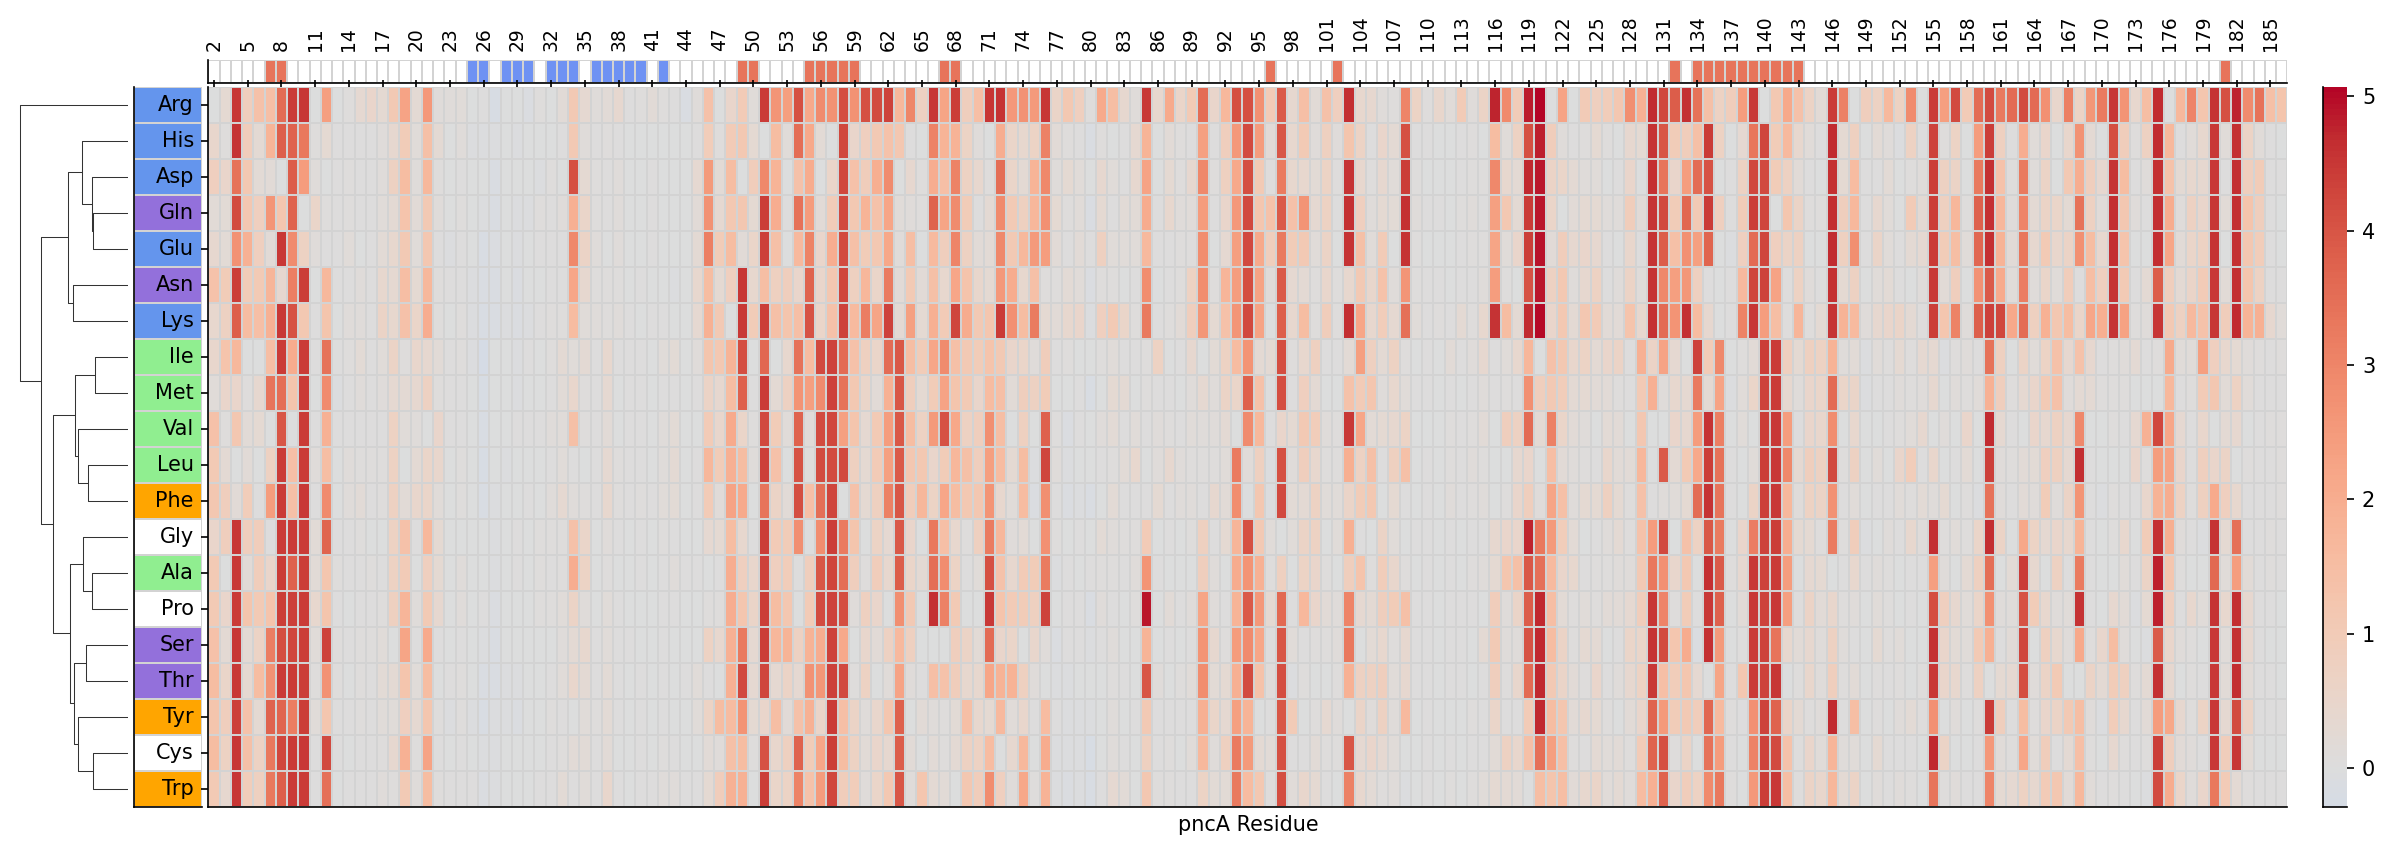

In [55]:
model_path = 'PZA_lineage_amino_acid'
locus = 'pncA'
gene = 'pncA'

pncA_missense = plot_saturation_heatmap_with_GeO_colors(model_path, locus, gene)

In [165]:
# F58, W68, P70 -- Phe and Trp are both hydrophobic. Pro might be an electron donor because of the lone pair on N
pd.DataFrame(pncA_missense.loc[[58, 68], :])#.sort_values(68, ascending=False)

mut_AA,Ala,Arg,Asn,Asp,Cys,Gln,Glu,Gly,His,Ile,Leu,Lys,Met,Phe,Pro,Ser,Thr,Trp,Tyr,Val
58,3.480485,4.112424,4.309380,4.249243,1.535834,4.223792,4.168039,3.242868,4.234568,3.571664,4.199296,4.325708,3.433146,0.000000,4.146908,2.133166,4.205184,0.924491,1.453266,2.36257
68,0.649548,4.410510,2.184653,3.052109,0.237950,2.860203,3.007052,0.424306,1.861501,1.388414,1.710006,4.310979,1.249769,1.534248,1.065884,0.860928,0.922879,0.000000,0.229168,2.14318


In [166]:
pos = 58
pd.DataFrame(pncA_missense.loc[pos, :]).sort_values(pos, ascending=False).head()

,58
mut_AA,
Lys,4.325708
Asn,4.309380
Asp,4.249243
His,4.234568
Gln,4.223792


In [167]:
pos = 68
pd.DataFrame(pncA_missense.loc[pos, :]).sort_values(pos, ascending=False).head()

,68
mut_AA,
Arg,4.410510
Lys,4.310979
Asp,3.052109
Glu,3.007052
Gln,2.860203


74 residues have significant clustering scores at FDR = 0.05


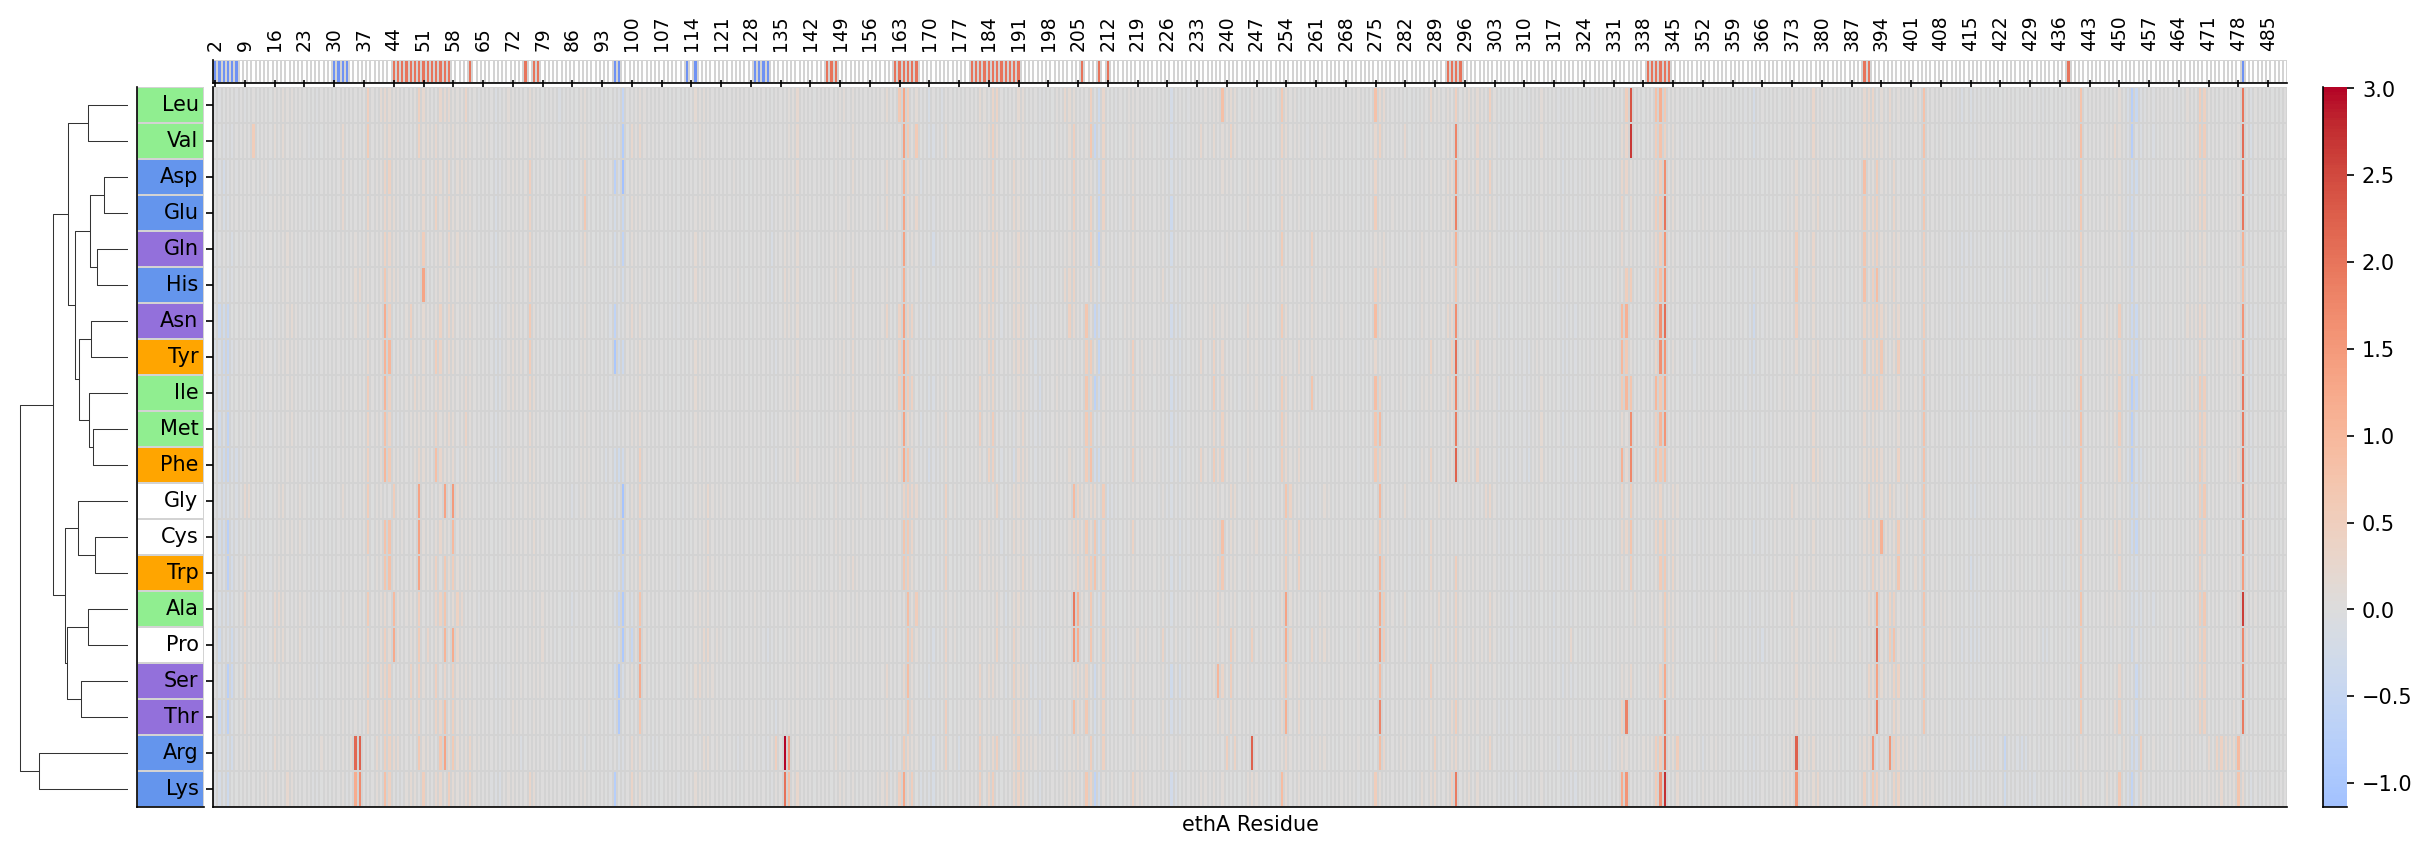

In [64]:
model_path = 'ETH_lineage_amino_acid'
locus = 'ethA'
gene = 'ethA'

ethA_missense = plot_saturation_heatmap_with_GeO_colors(model_path, locus, gene)

In [67]:
ethA_summary = pd.DataFrame(ethA_missense.mean(axis=1)).reset_index()
ethA_summary.columns = ['residue', 'average']

In [68]:
ethA_summary.sort_values('average')

,residue,average
96,98,-0.448431
451,453,-0.428490
3,5,-0.339715
452,454,-0.258530
94,96,-0.254465
...,...,...
340,342,0.713739
162,164,0.916753
292,294,1.073107
341,343,1.285099


In [85]:
ethA_summary.query("residue >= 475")

,residue,average
473,475,0.021716
474,476,0.031226
475,477,0.047150
476,478,0.131820
477,479,1.636109
478,480,0.012574
479,481,-0.055445
480,482,0.022398
481,483,-0.002668
482,484,-0.007392


In [84]:
ethA_summary.query("residue <= 10")

,residue,average
0,2,-0.026025
1,3,-0.167329
2,4,-0.146802
3,5,-0.339715
4,6,-0.095657
5,7,-0.031001
6,8,-0.000683
7,9,0.097356
8,10,0.019085


In [75]:
ethA_GeO_scores.query("G_score < 0 & BH_pval <= 0.05")

,residue,G_score,average,pval,BH_pval,Bonferroni_pval
0,2,-59.728162,-0.027395,0.0009,0.012759,0.4338
1,3,-57.497915,-0.176136,0.0007,0.011247,0.3374
2,4,-67.314835,-0.154528,0.0001,0.004382,0.0482
3,5,-55.216415,-0.357594,0.0009,0.012759,0.4338
4,6,-59.357884,-0.100692,0.0007,0.011247,0.3374
5,7,-48.304175,-0.032633,0.0041,0.034312,1.0000
28,30,-48.622054,-0.005805,0.0041,0.034312,1.0000
29,31,-58.017136,0.012685,0.0005,0.011247,0.2410
30,32,-56.738133,0.089416,0.0007,0.011247,0.3374
31,33,-48.260824,-0.001881,0.0046,0.036348,1.0000


In [71]:
ethA_GeO_scores = pd.read_csv("supplement/ethA_GeO_scores.csv")

In [80]:
who_variants.query("gene=='ethA' & variant.str.contains('479') & effect not in @silent_lst")[['variant', 'Present_SOLO_R', 'Present_SOLO_S', 'Present_R', 'Present_S']]

,variant,Present_SOLO_R,Present_SOLO_S,Present_R,Present_S
16502,ethA_p.Arg479fs,1.0,0.0,1.0,0.0
16503,ethA_p.Arg479Pro,2.0,0.0,2.0,0.0


In [83]:
isolate_variants.query("variant=='ethA_p.Arg479Pro'").merge(df_ETO_phenos[['ROLLINGDB_ID', 'ETH_lower_bound', 'ETH_upper_bound']])

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,ETH_lower_bound,ETH_upper_bound
0,4326038,C,G,PASS,3043.0,False,1.00,91.0,33.0,60.0,...,missense_variant,ethA,c.1436G>C,p.Arg479Pro,ethA_p.Arg479Pro,Ethionamide,3) Uncertain significance,SAMEA7563242,10.0,inf
1,4326038,C,G,PASS,936.0,False,0.82,98.0,34.0,60.0,...,missense_variant,ethA,c.1436G>C,p.Arg479Pro,ethA_p.Arg479Pro,Ethionamide,3) Uncertain significance,SAMEA7563261,10.0,inf


299 residues have significant clustering scores at FDR = 0.05


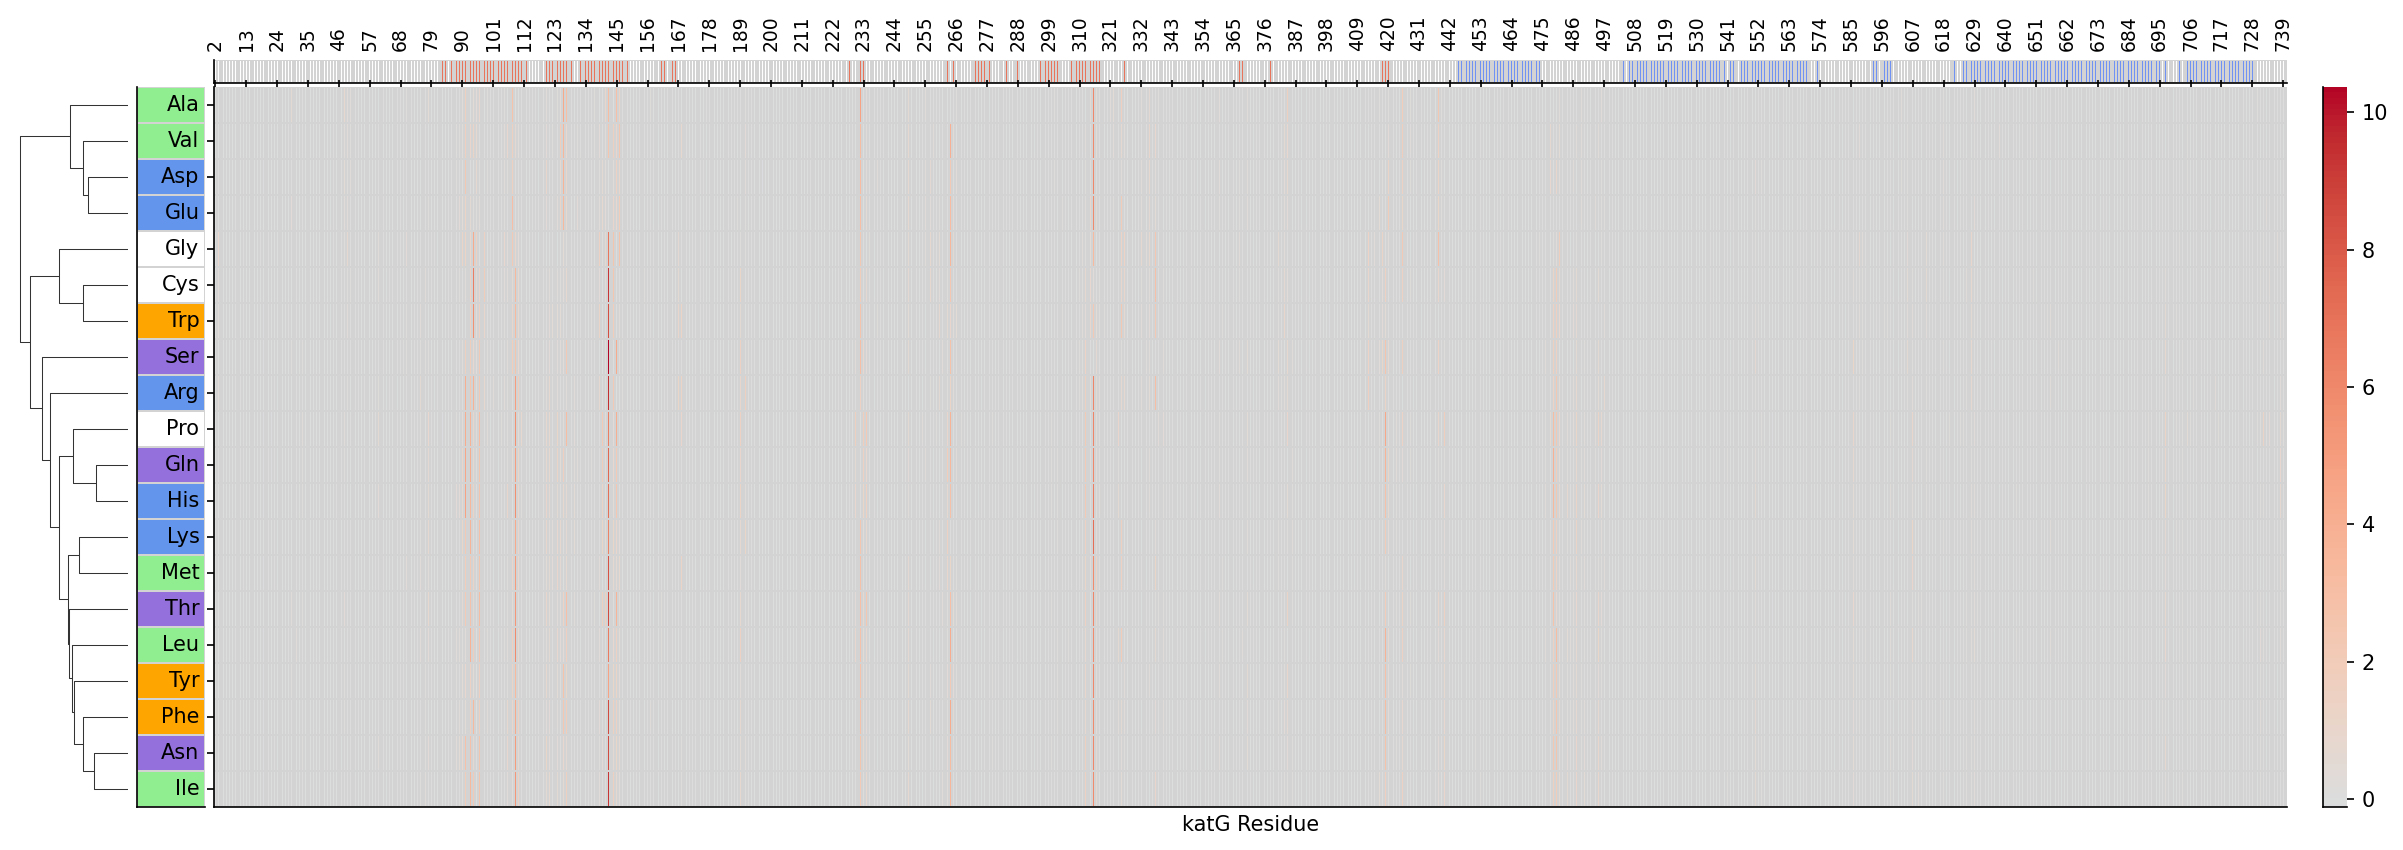

In [99]:
model_path = 'INH_lineage_amino_acid'
locus = 'katG-furA'
gene = 'katG'

katG_missense = plot_saturation_heatmap_with_GeO_colors(model_path, locus, gene)

In [104]:
# 107, 275
katG_summary = pd.DataFrame(katG_missense.mean(axis=1)).reset_index()
katG_summary.columns = ['residue', 'average']

In [107]:
katG_summary.query("residue in [107, 275]")

,residue,average
105,107,0.063107
273,275,-0.001115


# Does the CNN confuse missense and nonsense mutations?

# correlate the average log2-pred MICs (so the raw prediction) of nonsense and average missense predictions

## If there is a correlation, it is sharing information

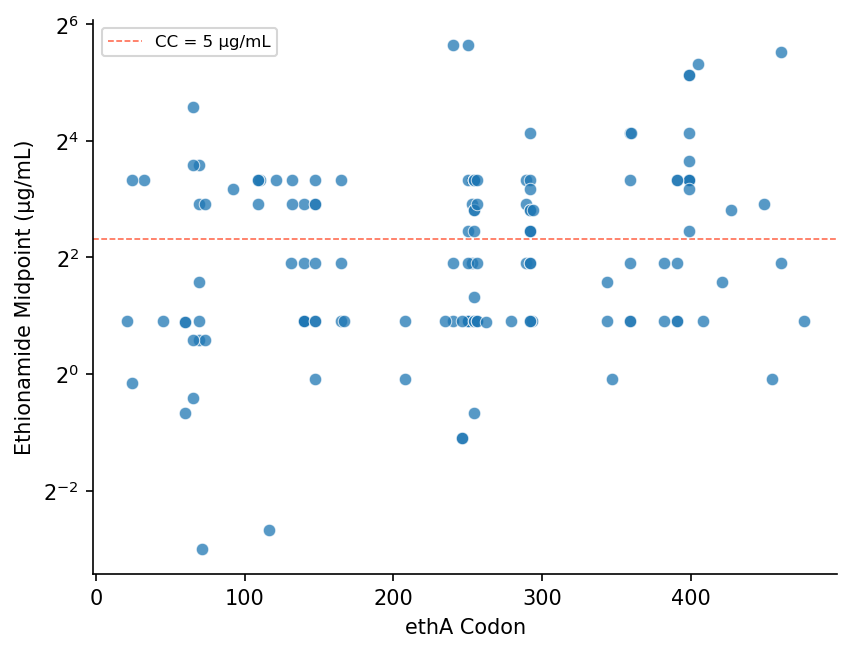

In [193]:
isolates_ethA_nonsense = isolate_variants.query("GENE=='ethA' & EFFECT == 'stop_gained' & variant != 'stop_gained'").ROLLINGDB_ID.unique()
df_ETO_phenos = pd.read_csv(os.path.join(data_dir, "ETH", "data_for_model.csv"))

df_ETO_nonsense_train = df_ETO_phenos.merge(isolate_variants.query("GENE=='ethA' & EFFECT == 'stop_gained' & variant != 'stop_gained'")[['ROLLINGDB_ID', 'variant']], on='ROLLINGDB_ID').query("category=='train_set'")

# merge with in silico predicted MICs
df_ETO_nonsense_train = df_ETO_nonsense_train.merge(df_ETH_ethA[['variant', 'pred_MIC', 'codon']], on='variant')

# df_ETO_nonsense_train.ROLLINGDB_ID.nunique()

# df_ETO_nonsense_train_melted = df_ETO_nonsense_train[['variant', 'ROLLINGDB_ID', 'codon', 'pred_MIC', 'ETH_midpoint']].melt(id_vars=['variant', 'ROLLINGDB_ID', 'codon'])
# df_ETO_nonsense_train_melted.ROLLINGDB_ID.nunique()

# df_ETO_nonsense_train_melted.query("variable=='ETH_midpoint'").groupby('codon').ROLLINGDB_ID.nunique().min(), df_ETO_nonsense_train_melted.query("variable=='ETH_midpoint'").groupby('codon').ROLLINGDB_ID.nunique().max()

sns.scatterplot(data=df_ETO_nonsense_train_melted.query("variable=='ETH_midpoint'"),
                x='codon',
                y='value',
                alpha=0.75,
                # hue='variable'
               )

drug = 'ETH'

plt.axhline(y=cc_dict[drug], color='tomato', linestyle='dashed', linewidth=0.75, zorder=0, label=f'CC = {cc_dict[drug]} µg/mL')
plt.yscale('log', base=2)
plt.xlabel("ethA Codon")
plt.ylabel("Ethionamide Midpoint (µg/mL)")
plt.legend(fontsize=8)

sns.despine()
plt.savefig("supplement/ethionamide_midpoints_training_nonsense.svg")

In [104]:
drug_loci

,Locus,Start,End,Sense
0,atpE,1460996,1461290,+
1,pepQ,2859299,2860451,-
2,Rv0678,778905,779487,+
3,mmpLS5,775585,778989,-
4,fgd1,490705,491793,+
5,Rv2983,3338999,3339762,+
6,ndh,2101650,2103183,-
7,fbiC,1302855,1305501,+
8,ddn,3986732,3987299,+
9,fbiAB,3640141,3642881,+


In [95]:
def compute_nonsense_missense_pred_corr(model_path, gene, corr_col='pred_MIC', log_base=2, annotate=False, codon_range=None):
    
    df_SSM = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis", "saturation_mutagenesis", gene, "test_predictions.csv")).rename(columns={'ROLLINGDB_ID': 'variant'})

    # add amino acid codon
    for i, row in df_SSM.iterrows():
        if '+' in row['variant']:
            df_SSM.loc[i, 'codon'] = int(row['variant'].split('_')[-1].replace('+', '')[3:])
        elif row['variant'] != 'MT_H37Rv':
            df_SSM.loc[i, 'codon'] = int(row['variant'].split('_')[-1][3:-3])
        else:
            df_SSM.loc[i, 'codon'] = 0

    # exclude the first codon too
    df_SSM = df_SSM.query("codon > 1")
    df_SSM['codon'] = df_SSM['codon'].astype(int)

    if codon_range is not None:
        codon_range = np.array(codon_range).astype(int)
        df_SSM = df_SSM.query("codon in @codon_range")
    
    df_SSM['variant'] = df_SSM['variant'].str.replace('_p_', '_p.').str.replace('+', '*')
    
    df_SSM.loc[df_SSM['variant'].str.endswith('*'), 'type'] = 'nonsense'
    df_SSM.loc[~df_SSM['variant'].str.endswith('*'), 'type'] = 'missense'

    df_SSM_summary = df_SSM.groupby(['codon', 'type'])[['log2_pred_MIC', 'pred_MIC']].mean().reset_index()
    df_SSM_summary_for_corr = df_SSM_summary.pivot(index='codon', columns='type', values=corr_col)

    print(st.spearmanr(df_SSM_summary_for_corr['missense'], df_SSM_summary_for_corr['nonsense']))

    fig, ax = plt.subplots()
    
    sns.scatterplot(data=df_SSM_summary_for_corr,
                x='missense',
                y='nonsense',
                alpha=0.75,
                    ax=ax
               )

    plt.xscale('log', base=log_base)
    plt.yscale('log', base=log_base)
    
    plt.xlabel('Average predicted MIC of Missense Mutations (µg/mL)', fontsize=10)
    plt.ylabel('Predicted MIC of Nonsense Mutations (µg/mL)', fontsize=10)

    if annotate:
        for codon in df_SSM_summary_for_corr.index.values:
            ax.text(x=df_SSM_summary_for_corr.loc[codon, 'missense'], y=df_SSM_summary_for_corr.loc[codon, 'nonsense'], s=codon, fontsize=8)
    
    sns.despine()
    plt.savefig(f"supplement/{gene}_missense_nonsense_comparison_all_codons.svg")

    return df_SSM_summary_for_corr

SignificanceResult(statistic=0.0978488059557548, pvalue=0.030680208463523352)


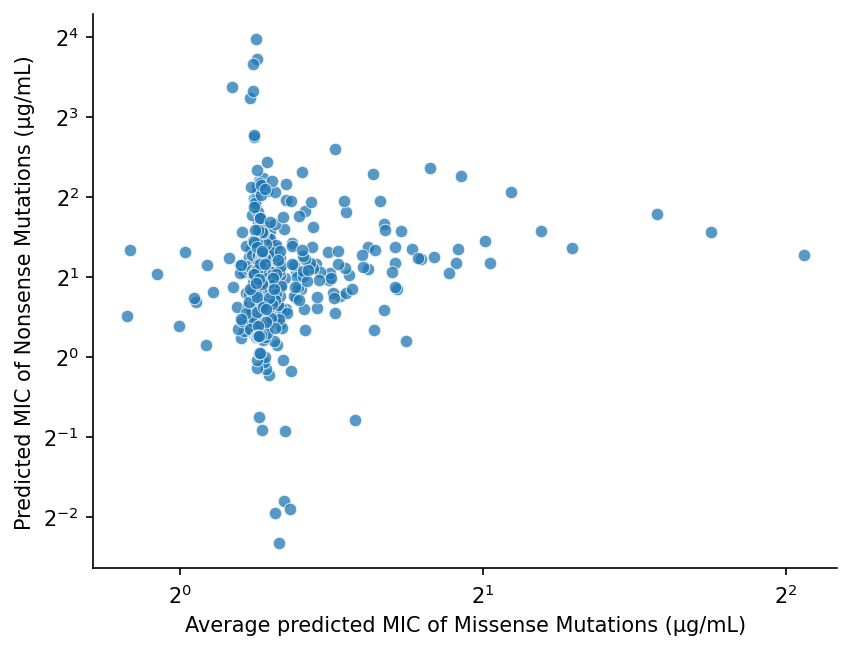

In [69]:
model_path = 'ETH_lineage_amino_acid'
gene = 'ethA'
compute_nonsense_missense_pred_corr(model_path, gene)

SignificanceResult(statistic=0.5833333333333334, pvalue=0.013970829934522285)


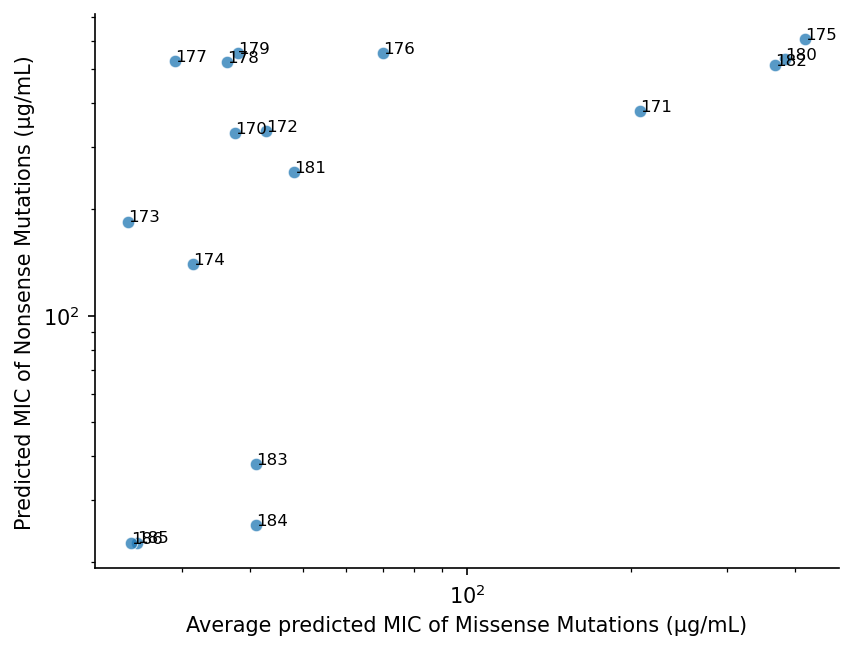

In [96]:
model_path = 'PZA_lineage_amino_acid'
gene = 'pncA'

df_SSM_summary_for_corr_pncA = compute_nonsense_missense_pred_corr(model_path, gene, log_base=10, annotate=True, codon_range=np.arange(170, 186+1))

299 residues have significant clustering scores at FDR = 0.05


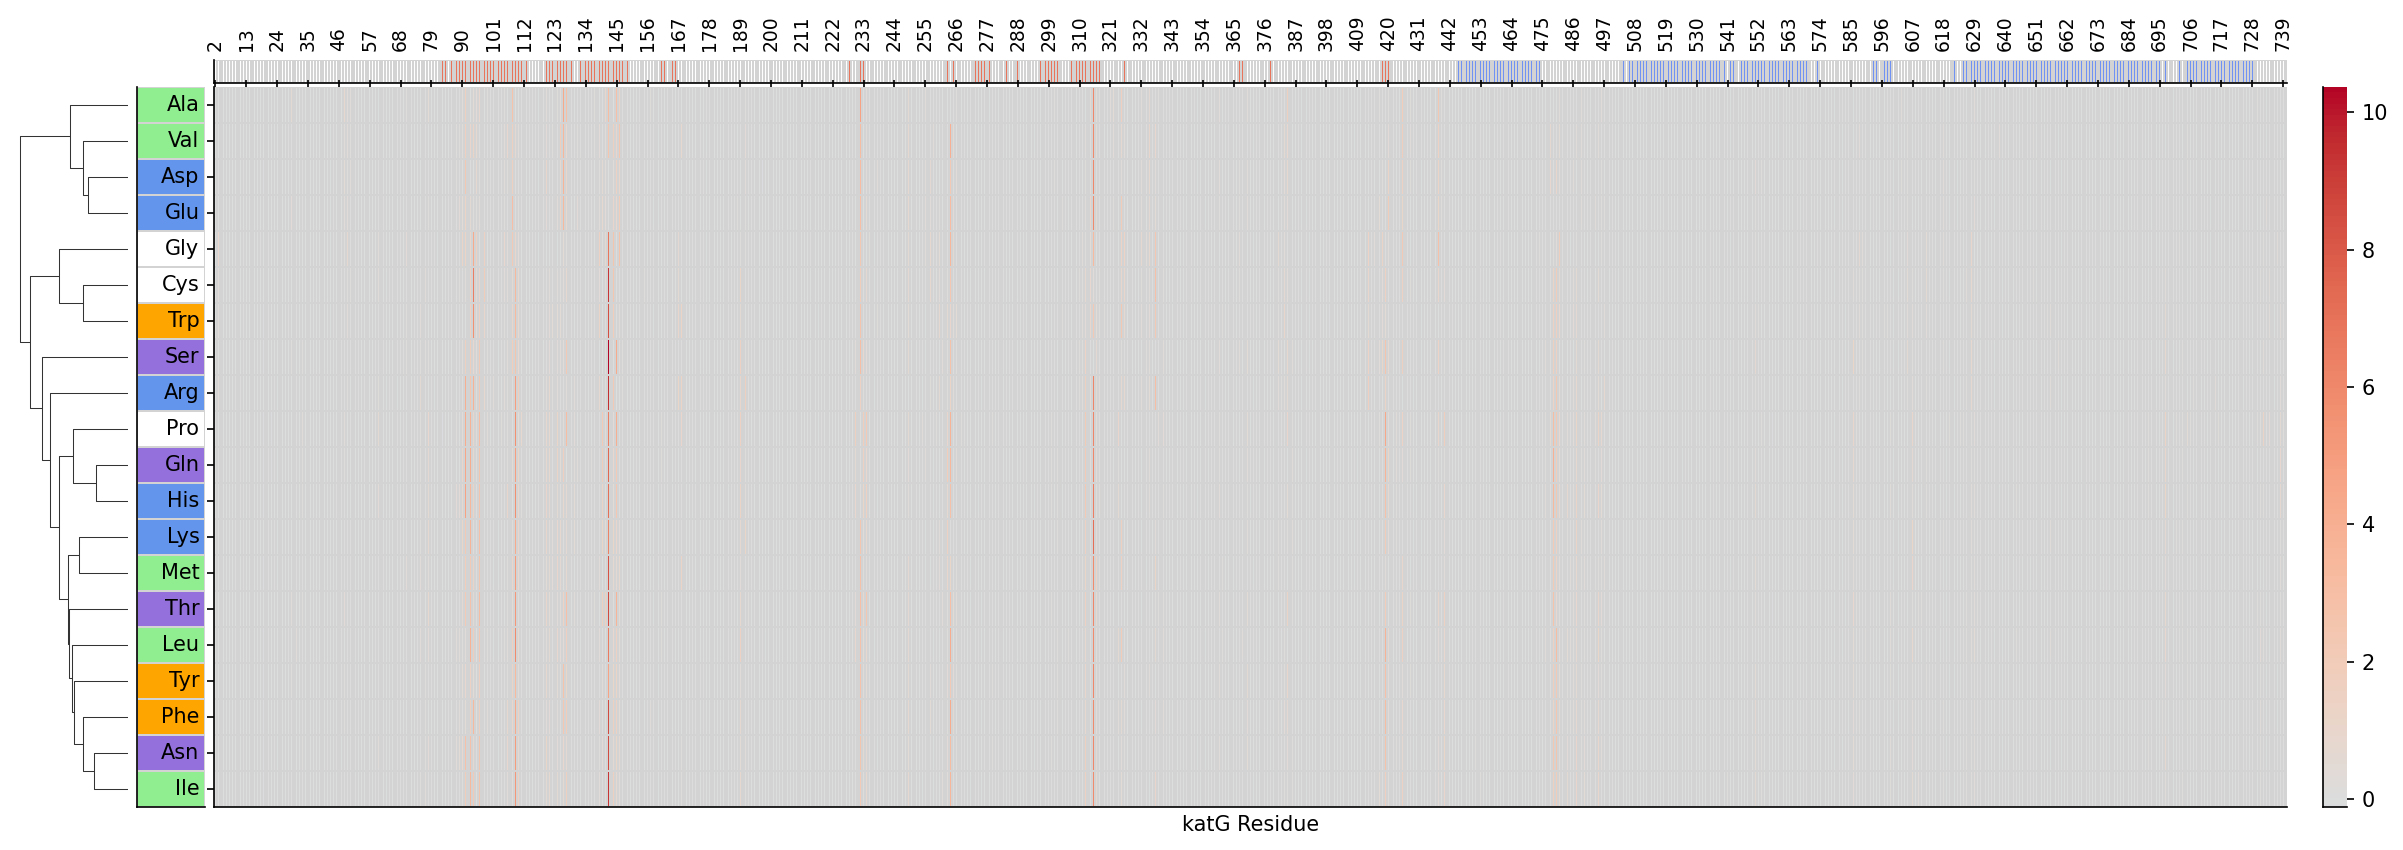

In [103]:
model_path = 'INH_lineage_amino_acid'
locus = 'katG-furA'
gene = 'katG'

katG_missense = plot_saturation_heatmap_with_GeO_colors(model_path, locus, gene)

# Hypothesize that the model associates small length changes (not early stop codons) with resistance because it learns the association between nonsense and resistance

## Compute the matched pairs difference in predicted MIC or fold change between for length-changing variants between models with and without AA features

## Restrict to protein length changing variants that are not due to early stop codons. 

In [445]:
# get predictions from models without amino acid features
all_drugs_insilico_pred_noAA = []

for drug in ['RIF', 'INH', 'EMB', 'ETH', 'MXF', 'PZA', 'LEV', 'BDQ']: #os.listdir(data_dir):

    if drug in ['MXF', 'BDQ', 'CFZ', 'DLM', 'ETH']:
        model_path = f"{drug}_lineage"
    else:
        model_path = drug
        
    df = plot_ECDF(model_path, cc_dict[drug], log_base=2, include_uncertain=True, V1=False, saveFig=False, show=False)
    df['gene'] = df['mutation'].str.split('_').str[0]
    df['drug'] = drug

    all_drugs_insilico_pred_noAA.append(df)

all_drugs_insilico_pred_noAA = pd.concat(all_drugs_insilico_pred_noAA)

In [446]:
# keep only protein-coding mutations, drop nonsense mutations
all_drugs_insilico_pred_combined_indels = pd.concat(all_drugs_insilico_pred_combined).query("mutation.str.contains('_p_') & ~mutation.str.contains('\+')").reset_index(drop=True)

all_drugs_insilico_pred_combined = all_drugs_insilico_pred_combined[['drug', 'Locus', 'gene', 'mutation', 'confidence', 'pred_MIC', 'ref_pred', 'fold_change']].rename(columns={'pred_MIC': 'pred_MIC_AA', 'fold_change': 'fold_change_AA'}).merge(all_drugs_insilico_pred_noAA[['drug', 'gene', 'mutation', 'pred_MIC', 'fold_change']], on=['drug', 'gene', 'mutation'])

all_drugs_insilico_pred_combined['pred_MIC_ratio'] = all_drugs_insilico_pred_combined['pred_MIC_AA'] / all_drugs_insilico_pred_combined['pred_MIC']
all_drugs_insilico_pred_combined['log_pred_MIC_ratio'] = np.log(all_drugs_insilico_pred_combined['pred_MIC_ratio'])

In [447]:
# get the affected codon (earliest) for each mutations
for i, row in all_drugs_insilico_pred_combined.iterrows():

    drug = row['drug']
    gene = row['gene']
    locus = row['Locus']
    mutation = row['mutation']
    
    variant = mutation.replace(row['gene'], '')

    # sense doesn't matter here unless return_start_and_end = True
    number = get_variant_number(variant, '+', return_start_and_end=False)

    all_drugs_insilico_pred_combined.loc[i, 'codon'] = number

all_drugs_insilico_pred_combined['codon'] = all_drugs_insilico_pred_combined['codon'].astype(int)

In [454]:
# get protein lengths
length_mapping_dict = {}
ref_length_mapping_dict = {}

for _, row in all_drugs_insilico_pred_combined[['drug', 'Locus']].drop_duplicates().iterrows():

    drug = row['drug']
    locus = row['Locus']
    
    df_protein_seqs = pd.read_csv(os.path.join(results_dir, drug, "inSilico_analysis", locus, "df_protein_seqs.csv"))
    
    for gene in all_drugs_insilico_pred_combined.query("Locus==@locus")['gene'].unique():
        
        df_protein_seqs[f'{gene}_length'] = df_protein_seqs[f'{gene}_AA'].str.replace('-', '').str.len()
        length_mapping_dict.update(dict(zip(df_protein_seqs.query("ROLLINGDB_ID.str.startswith(@gene)")['ROLLINGDB_ID'], df_protein_seqs.query("ROLLINGDB_ID.str.startswith(@gene)")[f'{gene}_length'])))

        ref_length_mapping_dict[gene] = df_protein_seqs.query("ROLLINGDB_ID=='MT_H37Rv'")[f'{gene}_length'].values[0]


all_drugs_insilico_pred_combined['protein_length'] = all_drugs_insilico_pred_combined['mutation'].map(length_mapping_dict)
all_drugs_insilico_pred_combined['ref_protein_length'] = all_drugs_insilico_pred_combined['gene'].map(ref_length_mapping_dict)

assert len(all_drugs_insilico_pred_combined.loc[pd.isnull(all_drugs_insilico_pred_combined['protein_length'])]) == 0

all_drugs_insilico_pred_combined['norm_length'] = all_drugs_insilico_pred_combined['protein_length'] / all_drugs_insilico_pred_combined['ref_protein_length']
all_drugs_insilico_pred_combined['codon_prop'] = all_drugs_insilico_pred_combined['codon'] / all_drugs_insilico_pred_combined['ref_protein_length']

# remove mutations that don't change the length of the protein
all_drugs_insilico_pred_combined = all_drugs_insilico_pred_combined.query("norm_length != 1")
len(all_drugs_insilico_pred_combined)

146

In [455]:
all_drugs_insilico_pred_combined.drug.value_counts()

drug
RIF    37
ETH    31
PZA    31
INH    17
EMB    15
BDQ     9
MXF     3
LEV     3
Name: count, dtype: int64

In [456]:
# this means that there is no relationship between protein length and predicted MIC ratio
st.spearmanr(all_drugs_insilico_pred_combined['norm_length'],
             all_drugs_insilico_pred_combined['pred_MIC_ratio']
            )

SignificanceResult(statistic=-0.05074781118967718, pvalue=0.5429821636743852)

In [457]:
st.spearmanr(all_drugs_insilico_pred_combined['norm_length'],
             all_drugs_insilico_pred_combined['fold_change']
            )

SignificanceResult(statistic=-0.17289409979833406, pvalue=0.036899606847296366)

In [458]:
st.spearmanr(all_drugs_insilico_pred_combined['norm_length'],
             all_drugs_insilico_pred_combined['fold_change_AA']
            )

SignificanceResult(statistic=-0.20853063210284842, pvalue=0.011541579121776991)

In [459]:
all_drugs_insilico_pred_combined.pred_MIC_ratio.min(), all_drugs_insilico_pred_combined.pred_MIC_ratio.mean(), all_drugs_insilico_pred_combined.pred_MIC_ratio.max()

(6.885234429782903e-19, 8.633476884899089, 116.95235533728332)

In [336]:
# plot_col = 'log_pred_MIC_ratio'

# # Create the scatterplot with continuous hue
# scatter = sns.scatterplot(data=all_drugs_insilico_pred_combined.query("diff_length != 0 & ~mutation.str.contains('\+')"),
#                           x='codon_prop',
#                           y='norm_diff_length',
#                           hue=plot_col,
#                           palette='Reds',
#                           legend=False  # We'll add a colorbar separately
#                          )

# sns.despine()

# # Create a colorbar with the Reds palette
# norm = plt.Normalize(all_drugs_insilico_pred_combined[plot_col].min(), all_drugs_insilico_pred_combined[plot_col].max())
# sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
# sm.set_array([])

# # Get the current axes
# ax = scatter.axes

# # Add a colorbar to the figure, specifying the axes
# cbar = scatter.figure.colorbar(sm, ax=ax, label=plot_col)

# plt.show()

# In silico Predictions for Individual Lineage SNPs

In [33]:
def plot_insilico_lineage_pred(drug, log_base=2, save_fName=None):
    
    df = pd.read_csv(f"{results_dir}/{drug}_lineage_amino_acid/inSilico_analysis/lineage_SNP_predictions.csv")

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))

    plot_col = 'pred_MIC'
    
    sns.histplot(data=df, x=plot_col, stat="count", log_scale=log_base, ax=ax)
    ref_mic = df.query("Lineage=='MT_H37Rv'")[plot_col].values[0]
          
    if df[plot_col].max() > 10:
        max_val = np.rint(df[plot_col].max())
        min_val = np.rint(df[plot_col].min())
        mean_val = np.rint(df[plot_col].mean())
        ref_mic = np.rint(ref_mic)
        
    else:
        max_val = np.round(df[plot_col].max(), 2)
        min_val = np.round(df[plot_col].min(), 2)
        mean_val = np.round(df[plot_col].mean(), 2)
        ref_mic = np.round(ref_mic, 2)

    ax.axvline(x=ref_mic, color="tomato", label=f"No SNP = {ref_mic}", linestyle="--", linewidth=1)  
    
    # Force integer tick labels
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))    
    ax.set_title(f"Min = {min_val}, Mean = {mean_val}, Max = {max_val}")    
    ax.set_xlabel(f"{abbr_drug_dict[drug]} MIC (µg/mL)")
    # fig.supxlabel()  # doesn't look as good
    ax.legend(fontsize=8)

    sns.despine()
    plt.tight_layout()

    if save_fName is not None:
        plt.savefig(save_fName, bbox_inches="tight", format='svg')
        # plt.close()
    else:
        plt.show()
    
    return df

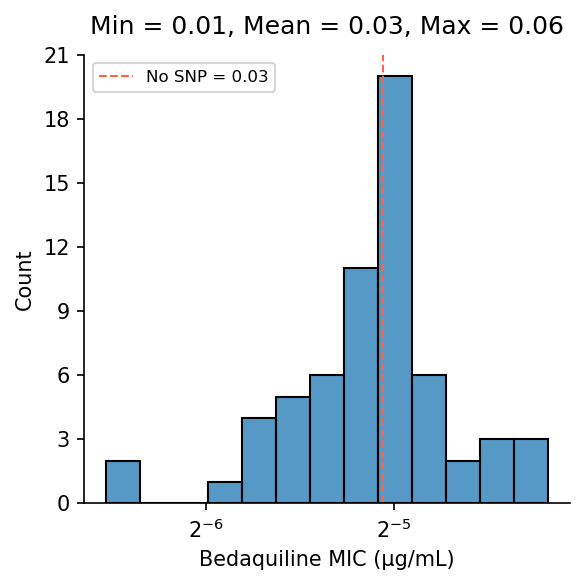

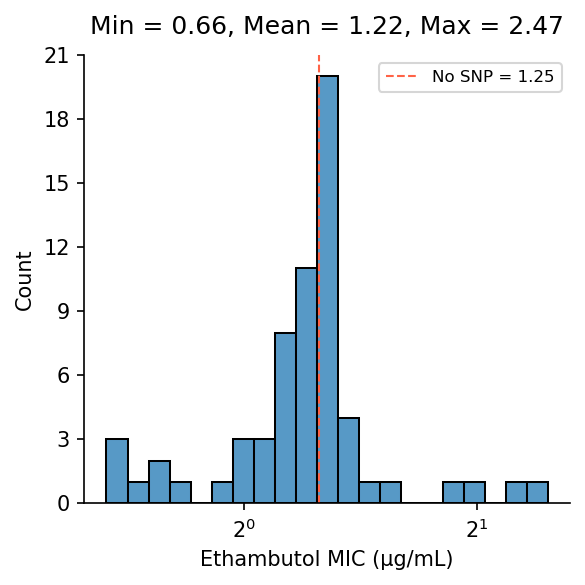

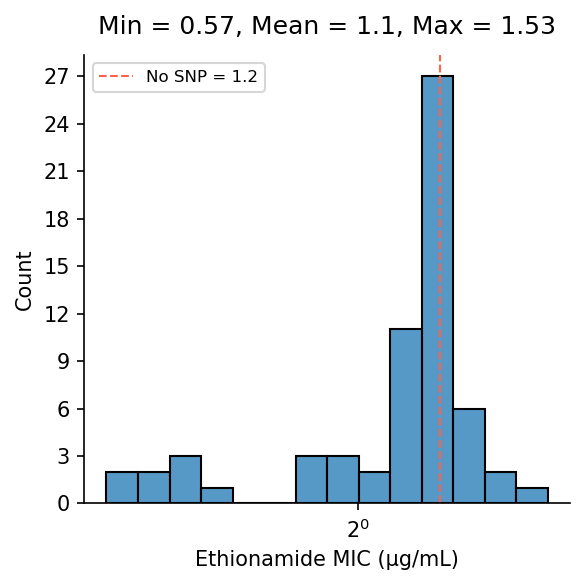

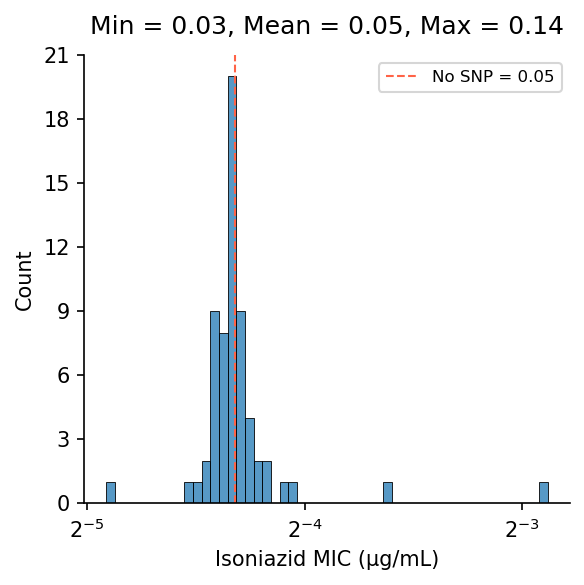

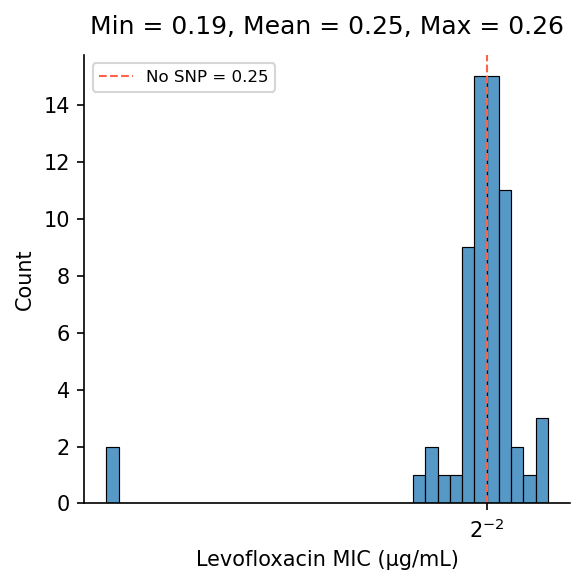

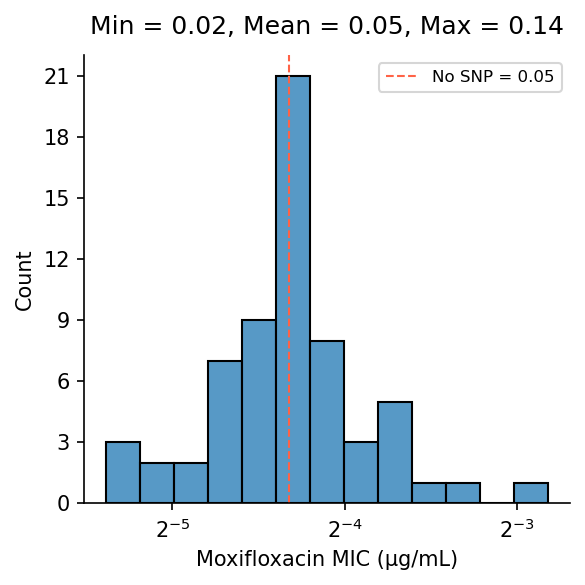

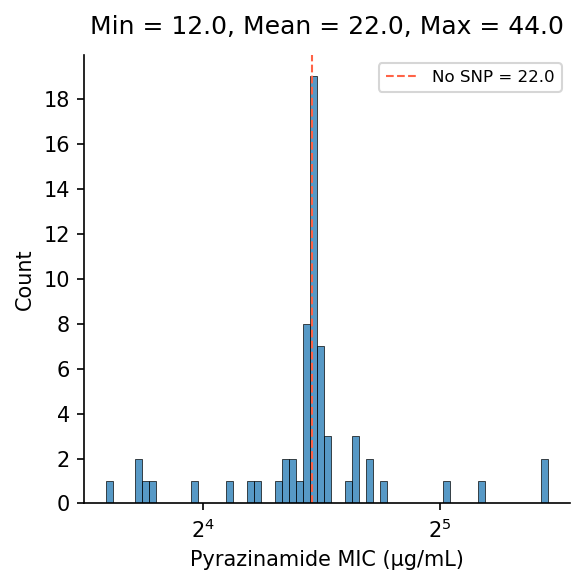

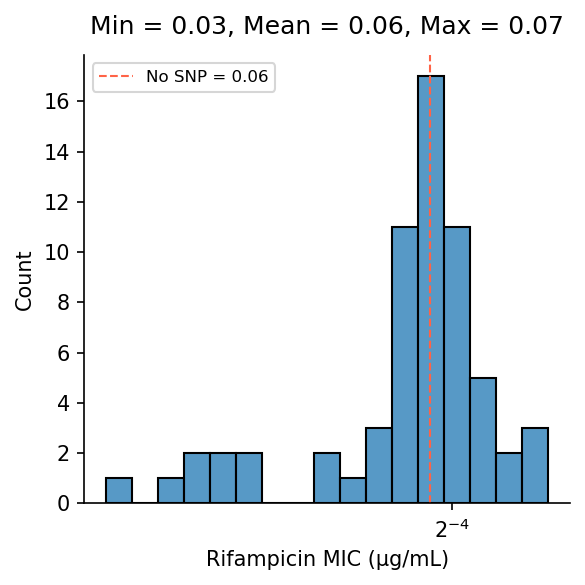

In [34]:
all_drugs_lineage_SNP_predictions = {}

for drug in os.listdir(data_dir):
    
    log_base = 2
    all_drugs_lineage_SNP_predictions[drug] = plot_insilico_lineage_pred(drug, log_base=log_base, save_fName=f"results/{abbr_drug_dict[drug]}/lineage_SNP_predictions.svg")

In [58]:
all_drugs_lineage_SNP_predictions['INH'].sort_values("pred_MIC", ascending=False)

,Lineage,Position,log2_pred_MIC,pred_MIC
50,4.3.4,3977226,-2.882208,0.135634
16,3.1.1,1084911,-3.602568,0.082323
39,1.1.1,3021283,-4.074529,0.059353
45,1.2.1,3479545,-4.104288,0.058141
31,BOV_AFRI,1882180,-4.181330,0.055118
...,...,...,...,...
58,4.4,4307886,-4.464530,0.045294
53,4.1.1.3,4229087,-4.473179,0.045023
52,4.4.1,4151558,-4.506425,0.043998
44,1.2.2,3470377,-4.548410,0.042736


In [60]:
all_drugs_lineage_SNP_predictions['INH'].query("Lineage=='2.2.1'")

,Lineage,Position,log2_pred_MIC,pred_MIC
12,2.2.1,797736,-4.308042,0.050484


In [35]:
all_drugs_lineage_SNP_predictions['BDQ'].query("Lineage in ['2.2.1', '2.2.1.1', '2.2.1.2']")

,Lineage,Position,log2_pred_MIC,pred_MIC
12,2.2.1,797736,-4.273495,0.051707
48,2.2.1.2,3836274,-6.355973,0.012208
55,2.2.1.1,4248115,-4.996188,0.031333
